train shape: (29376, 7)
origin shape: (118628, 21)
wholesale shape: (176014, 22)
weather shape: (10955, 10)

[train columns]
['시점', '품목명', '품종명', '거래단위', '등급', '평년 평균가격(원)', '평균가격(원)']

[origin columns 일부]
['시점', '공판장코드', '공판장명', '품목코드', '품목명', '품종코드', '품종명', '등급코드', '등급명', '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수', '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR', '평년 평균가격(원) Common Year SOON']

[wholesale columns 일부]
['시점', '시장코드', '시장명', '품목코드', '품목명', '품종코드', '품종명', '총반입량(kg)', '총거래금액(원)', '평균가(원/kg)', '고가(20%) 평균가', '중가(60%) 평균가', '저가(20%) 평균가', '중간가(원/kg)', '최저가(원/kg)', '최고가(원/kg)', '경매 건수', '전순 평균가격(원) PreVious SOON', '전달 평균가격(원) PreVious MMonth', '전년 평균가격(원) PreVious YeaR']

[weather columns]
['지점', '지점명', '일시', '평균기온(°C)', '최저기온(°C)', '최고기온(°C)', '일강수량(mm)', '평균 풍속(m/s)', '평균 상대습도(%)', '합계 일조시간(hr)']

[산지공판장] 자동 탐색 결과
총반입량: 총반입량(kg)
총거래금액: 총거래금액(원)
경매건수: 경매 건수
평균가: 평균가(원/kg)
최고가: 최고가(원/kg)
최저가: 최저가(원

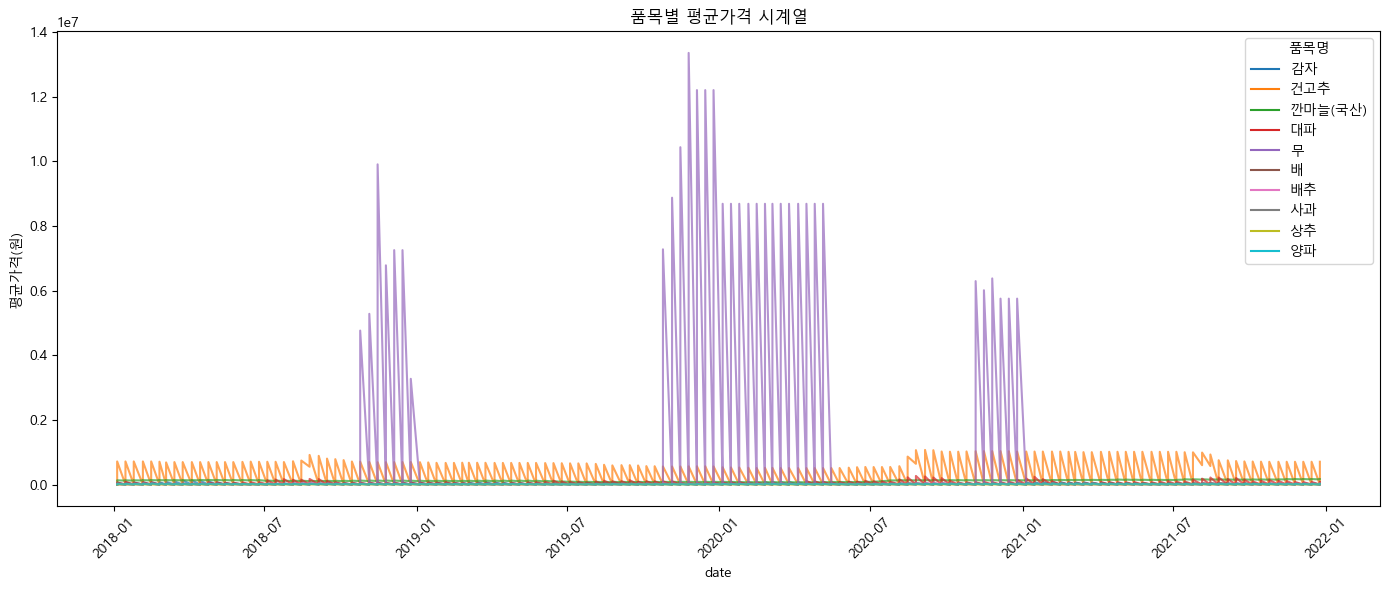

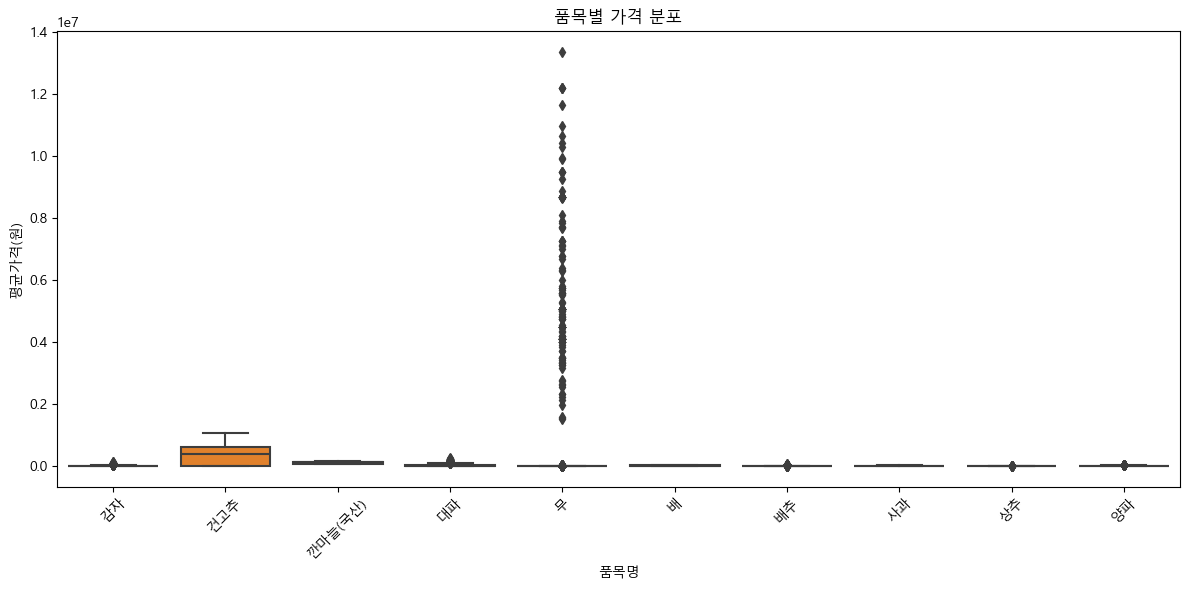

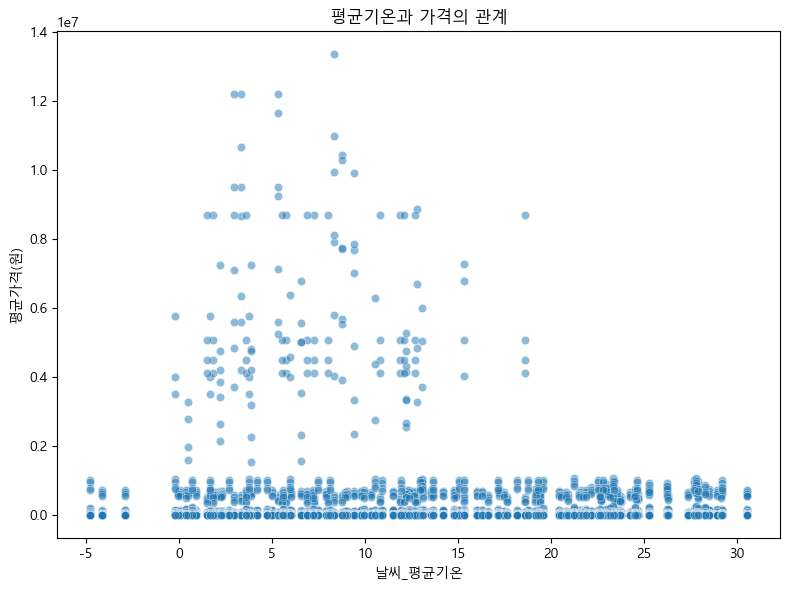

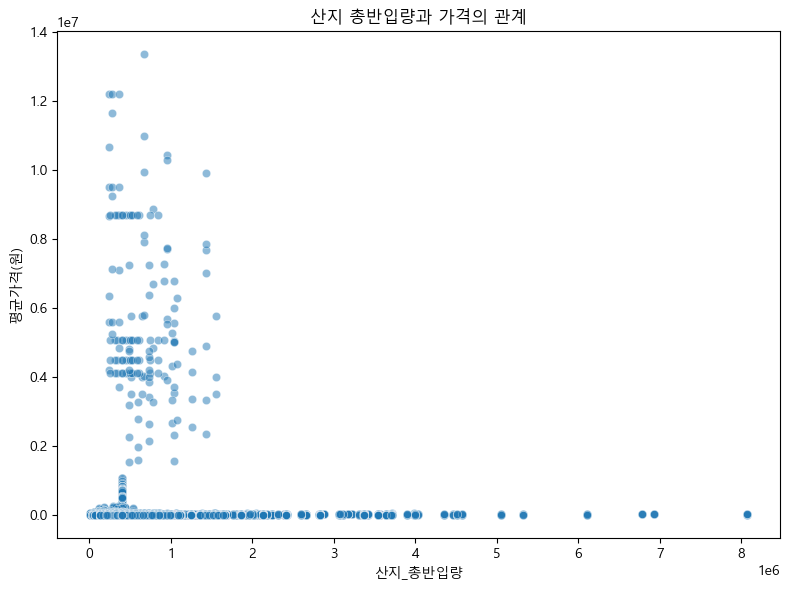


저장 완료: train_preprocessed_full.csv


In [4]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


############################################################
# 1. 파일 불러오기
# 현재 폴더 구조 기준
# ./train/train.csv
# ./train/meta/TRAIN_산지공판장_2018-2021.csv
# ./train/meta/TRAIN_전국도매_2018-2021.csv
# ./날씨.csv
############################################################
train = pd.read_csv("./train/train.csv")
origin = pd.read_csv("./train/meta/TRAIN_산지공판장_2018-2021.csv")
wholesale = pd.read_csv("./train/meta/TRAIN_전국도매_2018-2021.csv")

# 날씨 파일은 보통 cp949 또는 utf-8-sig 인코딩일 수 있으므로 예외 처리
try:
    weather = pd.read_csv("./날씨.csv", encoding="cp949")
except:
    try:
        weather = pd.read_csv("./날씨.csv", encoding="utf-8-sig")
    except:
        weather = pd.read_csv("./날씨.csv")

print("train shape:", train.shape)
print("origin shape:", origin.shape)
print("wholesale shape:", wholesale.shape)
print("weather shape:", weather.shape)


############################################################
# 2. 컬럼명 정리 함수
# - 앞뒤 공백 제거
# - 중복 공백 제거
############################################################
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

train = clean_columns(train)
origin = clean_columns(origin)
wholesale = clean_columns(wholesale)
weather = clean_columns(weather)

print("\n[train columns]")
print(train.columns.tolist())

print("\n[origin columns 일부]")
print(origin.columns.tolist()[:20])

print("\n[wholesale columns 일부]")
print(wholesale.columns.tolist()[:20])

print("\n[weather columns]")
print(weather.columns.tolist())


############################################################
# 3. 상순/중순/하순 처리 함수
# 발표에서는 01,11,21로 볼 수도 있지만
# 분석용 대표일자는 5,15,25를 많이 사용함
# 여기서는 대표일자 5/15/25를 사용
############################################################
def soon_to_date(soon_str):
    """
    예: 201801상순 -> 2018-01-05
    """
    soon_str = str(soon_str)
    year = int(soon_str[:4])
    month = int(soon_str[4:6])
    soon = soon_str[6:]

    if soon == "상순":
        day = 5
    elif soon == "중순":
        day = 15
    else:
        day = 25

    return pd.Timestamp(year=year, month=month, day=day)

def day_to_soon(day):
    """
    일(day)을 받아 상순/중순/하순 반환
    """
    if day <= 10:
        return "상순"
    elif day <= 20:
        return "중순"
    else:
        return "하순"


############################################################
# 4. train 전처리
############################################################
train = train.copy()

# 시점 -> 날짜
train["date"] = train["시점"].apply(soon_to_date)

# year, month, day 파생
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["soon"] = train["시점"].str[-2:]

# 정렬
train = train.sort_values(["품목명", "품종명", "거래단위", "등급", "date"]).reset_index(drop=True)

# 평년 평균가격 0 -> NaN
if "평년 평균가격(원)" in train.columns:
    train["평년 평균가격(원)"] = train["평년 평균가격(원)"].replace(0, np.nan)

    # 같은 그룹 내 앞/뒤 값으로 채우기
    train["평년 평균가격(원)"] = train.groupby(
        ["품목명", "품종명", "거래단위", "등급"]
    )["평년 평균가격(원)"].transform(lambda x: x.ffill().bfill())

    # 그래도 비면 그룹 평균으로 채우기
    train["평년 평균가격(원)"] = train.groupby(
        ["품목명", "품종명", "거래단위", "등급"]
    )["평년 평균가격(원)"].transform(lambda x: x.fillna(x.mean()))

    # 마지막까지 남는 결측은 전체 중앙값
    train["평년 평균가격(원)"] = train["평년 평균가격(원)"].fillna(
        train["평년 평균가격(원)"].median()
    )

# 평년 대비 파생변수
if "평년 평균가격(원)" in train.columns:
    train["평년대비_차이"] = train["평균가격(원)"] - train["평년 평균가격(원)"]
    train["평년대비_비율"] = train["평균가격(원)"] / train["평년 평균가격(원)"]

# 로그 가격
train["log_price"] = np.log1p(train["평균가격(원)"])


############################################################
# 5. 시계열 feature 생성
# - lag
# - rolling mean
# - rolling std
# - 계절성 sin/cos
############################################################
group_cols = ["품목명", "품종명", "거래단위", "등급"]

# lag 1~8
for lag in range(1, 9):
    train[f"price_lag_{lag}"] = train.groupby(group_cols)["평균가격(원)"].shift(lag)

# 요청한 느낌 반영: lag_3, lag_5, lag_7도 따로 강조용으로 남김
train["lag_3"] = train.groupby(group_cols)["평균가격(원)"].shift(3)
train["lag_5"] = train.groupby(group_cols)["평균가격(원)"].shift(5)
train["lag_7"] = train.groupby(group_cols)["평균가격(원)"].shift(7)

# 가격 변화량
train["price_diff_1"] = train.groupby(group_cols)["평균가격(원)"].diff(1)
train["price_diff_3"] = train.groupby(group_cols)["평균가격(원)"].diff(3)

# rolling mean / std
train["rolling_mean_3"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
train["rolling_mean_5"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(5).mean()
)
train["rolling_std_3"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(3).std()
)
train["rolling_std_5"] = train.groupby(group_cols)["평균가격(원)"].transform(
    lambda x: x.shift(1).rolling(5).std()
)

# 모멘텀 / 평균 대비 수준
train["price_vs_ma3"] = train["평균가격(원)"] / train["rolling_mean_3"]
train["price_vs_ma5"] = train["평균가격(원)"] / train["rolling_mean_5"]

# 계절성
train["month_sin"] = np.sin(2 * np.pi * train["month"] / 12)
train["month_cos"] = np.cos(2 * np.pi * train["month"] / 12)


############################################################
# 6. 산지/도매 데이터용 공통 전처리 함수
# - 컬럼명 자동 탐색
# - 가격 정합성 보정
# - 거래 부재 판단
############################################################
def find_col(df, keywords):
    """
    df 컬럼 중 keywords를 모두 포함하는 첫 번째 컬럼 반환
    예: find_col(df, ["총반입량"]) -> "총반입량(kg)"
    """
    for col in df.columns:
        if all(k in col for k in keywords):
            return col
    return None

def preprocess_market_meta(df, data_name="meta"):
    df = df.copy()

    # 시점 -> 날짜
    if "시점" in df.columns:
        df["date"] = df["시점"].apply(soon_to_date)
        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month
        df["day"] = df["date"].dt.day
        df["soon"] = df["시점"].str[-2:]

    # 자주 쓰는 컬럼 자동 탐색
    qty_col = find_col(df, ["총반입량"])
    amt_col = find_col(df, ["총거래금액"])
    auction_col = find_col(df, ["경매", "건수"]) or find_col(df, ["건수"])
    
    avg_col = find_col(df, ["평균가"])
    high_col = find_col(df, ["최고가"])
    low_col = find_col(df, ["최저가"])
    mid_col = find_col(df, ["중간가"])

    # 도매 데이터에서 고가(20%) 평균가 / 중가(60%) 평균가 / 저가(20%) 평균가 같은 구조 탐색
    top20_col = find_col(df, ["고가", "20"])
    mid60_col = find_col(df, ["중가", "60"])
    low20_col = find_col(df, ["저가", "20"])

    print(f"\n[{data_name}] 자동 탐색 결과")
    print("총반입량:", qty_col)
    print("총거래금액:", amt_col)
    print("경매건수:", auction_col)
    print("평균가:", avg_col)
    print("최고가:", high_col)
    print("최저가:", low_col)
    print("중간가:", mid_col)
    print("고가20:", top20_col)
    print("중가60:", mid60_col)
    print("저가20:", low20_col)

    # 숫자형 변환
    candidate_num_cols = [
        qty_col, amt_col, auction_col, avg_col, high_col, low_col, mid_col,
        top20_col, mid60_col, low20_col
    ]
    candidate_num_cols = [c for c in candidate_num_cols if c is not None]

    for c in candidate_num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 실제 거래 부재 여부
    # 반입량, 거래금액, 경매건수가 모두 0이면 거래 부재로 판단
    df["거래부재"] = 0
    if qty_col and amt_col and auction_col:
        df["거래부재"] = (
            (df[qty_col].fillna(0) == 0) &
            (df[amt_col].fillna(0) == 0) &
            (df[auction_col].fillna(0) == 0)
        ).astype(int)

    # -----------------------------
    # 1) 최고가 >= 최저가 정합성 보정
    # -----------------------------
    # 규칙:
    # - 거래부재면 굳이 가격을 강제로 보정하지 않음
    # - 최저가가 0이고 거래부재가 아니면 그대로 둘 수 있음 (사용자 요구 반영)
    # - 최저가>0인데 최고가==0이면 이전 유효 최고가로 대체
    # - 최고가<최저가이면 둘 중 큰 값으로 최고가 보정
    # -----------------------------
    if high_col and low_col:
        # 그룹 기준: 품목명 / 품종명 / 등급 있으면 사용
        key_cols = [c for c in ["품목명", "품종명", "등급"] if c in df.columns]
        sort_cols = key_cols + ["date"] if "date" in df.columns else key_cols
        if sort_cols:
            df = df.sort_values(sort_cols).reset_index(drop=True)

        # 이전 유효 최고가
        if key_cols:
            prev_valid_high = df.groupby(key_cols)[high_col].transform(
                lambda x: x.replace(0, np.nan).ffill()
            )
        else:
            prev_valid_high = df[high_col].replace(0, np.nan).ffill()

        # 조건: 최저가 > 0인데 최고가 == 0, 그리고 거래부재 아님
        cond_replace_high = (
            (df[low_col].fillna(0) > 0) &
            (df[high_col].fillna(0) == 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_replace_high, high_col] = prev_valid_high[cond_replace_high]

        # 그래도 최고가 < 최저가면 최고가를 최저가로 보정
        cond_swap_high = (
            (df[high_col].notna()) &
            (df[low_col].notna()) &
            (df[high_col] < df[low_col]) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_swap_high, high_col] = df.loc[cond_swap_high, low_col]

    # -----------------------------
    # 2) 고가(20) >= 중가(60) >= 저가(20) 정합성 보정
    # 규칙:
    # - 거래부재면 보정하지 않음
    # - 고가=0, 중가>0, 저가>0 이면 이전 유효 고가로 대체
    # - 고가=0, 중가=0, 저가>0 이면 세 값을 저가 기준으로 맞춤
    # - 마지막으로 고/중/저 순서를 강제
    # -----------------------------
    if top20_col and mid60_col and low20_col:
        key_cols = [c for c in ["품목명", "품종명", "등급"] if c in df.columns]
        sort_cols = key_cols + ["date"] if "date" in df.columns else key_cols
        if sort_cols:
            df = df.sort_values(sort_cols).reset_index(drop=True)

        # 이전 유효 고가
        if key_cols:
            prev_valid_top = df.groupby(key_cols)[top20_col].transform(
                lambda x: x.replace(0, np.nan).ffill()
            )
        else:
            prev_valid_top = df[top20_col].replace(0, np.nan).ffill()

        # case 1: 고가 0, 중가 0, 저가>0 -> 세 값을 저가로 맞춤
        cond_all_from_low = (
            (df[top20_col].fillna(0) == 0) &
            (df[mid60_col].fillna(0) == 0) &
            (df[low20_col].fillna(0) > 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_all_from_low, top20_col] = df.loc[cond_all_from_low, low20_col]
        df.loc[cond_all_from_low, mid60_col] = df.loc[cond_all_from_low, low20_col]

        # case 2: 고가 0, 중가>0, 저가>0 -> 이전 유효 고가로 대체
        cond_top_from_prev = (
            (df[top20_col].fillna(0) == 0) &
            (df[mid60_col].fillna(0) > 0) &
            (df[low20_col].fillna(0) > 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_top_from_prev, top20_col] = prev_valid_top[cond_top_from_prev]

        # 그래도 결측/0이면 중가로 보정
        cond_top_still_bad = (
            (df[top20_col].fillna(0) == 0) &
            (df[mid60_col].fillna(0) > 0) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_top_still_bad, top20_col] = df.loc[cond_top_still_bad, mid60_col]

        # 순서 강제: 고가 >= 중가 >= 저가
        # 중가 < 저가이면 중가를 저가로
        cond_mid_low = (
            (df[mid60_col].notna()) &
            (df[low20_col].notna()) &
            (df[mid60_col] < df[low20_col]) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_mid_low, mid60_col] = df.loc[cond_mid_low, low20_col]

        # 고가 < 중가이면 고가를 중가로
        cond_top_mid = (
            (df[top20_col].notna()) &
            (df[mid60_col].notna()) &
            (df[top20_col] < df[mid60_col]) &
            (df["거래부재"] == 0)
        )
        df.loc[cond_top_mid, top20_col] = df.loc[cond_top_mid, mid60_col]

    return df


############################################################
# 7. 산지공판장 / 전국도매 전처리 실행
############################################################
origin = preprocess_market_meta(origin, data_name="산지공판장")
wholesale = preprocess_market_meta(wholesale, data_name="전국도매")


############################################################
# 8. 산지공판장 / 전국도매 집계
# train과 붙이기 쉽게 시점 + 품목명 기준 집계
#
# 주의:
# 메타 데이터는 품종/등급이 train과 완전히 맞지 않을 수 있으므로
# 우선 품목명 단위 집계로 단순화
############################################################
def make_market_agg(df, prefix="산지"):
    df = df.copy()

    qty_col = find_col(df, ["총반입량"])
    amt_col = find_col(df, ["총거래금액"])
    auction_col = find_col(df, ["경매", "건수"]) or find_col(df, ["건수"])
    avg_col = find_col(df, ["평균가"])
    high_col = find_col(df, ["최고가"])
    low_col = find_col(df, ["최저가"])
    mid_col = find_col(df, ["중간가"])
    top20_col = find_col(df, ["고가", "20"])
    mid60_col = find_col(df, ["중가", "60"])
    low20_col = find_col(df, ["저가", "20"])

    agg_dict = {}

    if qty_col: agg_dict[qty_col] = "sum"
    if amt_col: agg_dict[amt_col] = "sum"
    if auction_col: agg_dict[auction_col] = "sum"
    if avg_col: agg_dict[avg_col] = "mean"
    if high_col: agg_dict[high_col] = "mean"
    if low_col: agg_dict[low_col] = "mean"
    if mid_col: agg_dict[mid_col] = "mean"
    if top20_col: agg_dict[top20_col] = "mean"
    if mid60_col: agg_dict[mid60_col] = "mean"
    if low20_col: agg_dict[low20_col] = "mean"
    if "거래부재" in df.columns: agg_dict["거래부재"] = "sum"

    out = df.groupby(["시점", "품목명"], as_index=False).agg(agg_dict)

    rename_dict = {}
    if qty_col: rename_dict[qty_col] = f"{prefix}_총반입량"
    if amt_col: rename_dict[amt_col] = f"{prefix}_총거래금액"
    if auction_col: rename_dict[auction_col] = f"{prefix}_경매건수"
    if avg_col: rename_dict[avg_col] = f"{prefix}_평균가"
    if high_col: rename_dict[high_col] = f"{prefix}_최고가"
    if low_col: rename_dict[low_col] = f"{prefix}_최저가"
    if mid_col: rename_dict[mid_col] = f"{prefix}_중간가"
    if top20_col: rename_dict[top20_col] = f"{prefix}_고가20"
    if mid60_col: rename_dict[mid60_col] = f"{prefix}_중가60"
    if low20_col: rename_dict[low20_col] = f"{prefix}_저가20"
    if "거래부재" in df.columns: rename_dict["거래부재"] = f"{prefix}_거래부재횟수"

    out = out.rename(columns=rename_dict)
    return out

origin_agg = make_market_agg(origin, prefix="산지")
wholesale_agg = make_market_agg(wholesale, prefix="도매")

print("\norigin_agg shape:", origin_agg.shape)
print("wholesale_agg shape:", wholesale_agg.shape)


############################################################
# 9. 날씨 데이터 전처리
# - 일시 -> 날짜형
# - 일 -> 순 변환
# - 순 단위 집계
############################################################
weather = weather.copy()

# 날짜 컬럼 탐색
date_col = None
for c in weather.columns:
    if "일시" in c or "date" in c.lower():
        date_col = c
        break

if date_col is None:
    raise ValueError("날씨 데이터에서 날짜 컬럼(예: 일시)을 찾지 못했습니다.")

weather[date_col] = pd.to_datetime(weather[date_col])
weather["year"] = weather[date_col].dt.year
weather["month"] = weather[date_col].dt.month
weather["day"] = weather[date_col].dt.day
weather["soon"] = weather["day"].apply(day_to_soon)
weather["시점"] = (
    weather["year"].astype(str)
    + weather["month"].astype(str).str.zfill(2)
    + weather["soon"]
)

# 자주 쓰는 날씨 컬럼 탐색
temp_avg_col = find_col(weather, ["평균기온"])
temp_min_col = find_col(weather, ["최저기온"])
temp_max_col = find_col(weather, ["최고기온"])
rain_col = find_col(weather, ["강수량"])
humid_col = find_col(weather, ["상대습도"]) or find_col(weather, ["습도"])
sun_col = find_col(weather, ["일조"])
wind_col = find_col(weather, ["풍속"])

print("\n[날씨 컬럼 자동 탐색]")
print("평균기온:", temp_avg_col)
print("최저기온:", temp_min_col)
print("최고기온:", temp_max_col)
print("강수량:", rain_col)
print("습도:", humid_col)
print("일조:", sun_col)
print("풍속:", wind_col)

weather_agg_dict = {}

if temp_avg_col: weather_agg_dict[temp_avg_col] = "mean"
if temp_min_col: weather_agg_dict[temp_min_col] = "mean"
if temp_max_col: weather_agg_dict[temp_max_col] = "mean"
if humid_col: weather_agg_dict[humid_col] = "mean"
if sun_col: weather_agg_dict[sun_col] = "mean"
if wind_col: weather_agg_dict[wind_col] = "mean"

# 강수량은 합계가 더 자연스러움
if rain_col:
    weather[rain_col] = pd.to_numeric(weather[rain_col], errors="coerce").fillna(0)
    weather_agg_dict[rain_col] = "sum"

weather_agg = weather.groupby("시점", as_index=False).agg(weather_agg_dict)

rename_weather = {}
if temp_avg_col: rename_weather[temp_avg_col] = "날씨_평균기온"
if temp_min_col: rename_weather[temp_min_col] = "날씨_최저기온"
if temp_max_col: rename_weather[temp_max_col] = "날씨_최고기온"
if rain_col: rename_weather[rain_col] = "날씨_강수량"
if humid_col: rename_weather[humid_col] = "날씨_평균습도"
if sun_col: rename_weather[sun_col] = "날씨_일조시간"
if wind_col: rename_weather[wind_col] = "날씨_평균풍속"

weather_agg = weather_agg.rename(columns=rename_weather)

print("\nweather_agg shape:", weather_agg.shape)


############################################################
# 10. train + 산지 + 도매 + 날씨 병합
############################################################
train_merged = train.merge(origin_agg, on=["시점", "품목명"], how="left")
train_merged = train_merged.merge(wholesale_agg, on=["시점", "품목명"], how="left")
train_merged = train_merged.merge(weather_agg, on="시점", how="left")


############################################################
# 11. 추가 파생변수
# - 산지/도매 가격 차이
# - 현재가격 vs 산지/도매
# - 반입량 비율
############################################################
if "도매_평균가" in train_merged.columns and "산지_평균가" in train_merged.columns:
    train_merged["도매_산지_가격차"] = train_merged["도매_평균가"] - train_merged["산지_평균가"]

if "도매_평균가" in train_merged.columns:
    train_merged["현재가격_vs_도매"] = train_merged["평균가격(원)"] - train_merged["도매_평균가"]

if "산지_평균가" in train_merged.columns:
    train_merged["현재가격_vs_산지"] = train_merged["평균가격(원)"] - train_merged["산지_평균가"]

if "도매_총반입량" in train_merged.columns and "산지_총반입량" in train_merged.columns:
    train_merged["도매_산지_반입량비"] = train_merged["도매_총반입량"] / train_merged["산지_총반입량"]

# 무한대 제거
train_merged = train_merged.replace([np.inf, -np.inf], np.nan)


############################################################
# 12. 결측치 처리(간단 버전)
# - 시계열 feature나 병합 feature 결측은 그룹별 ffill/bfill
############################################################
fill_group_cols = ["품목명", "품종명", "거래단위", "등급"]

numeric_cols = train_merged.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    if col == "평균가격(원)":
        continue
    train_merged[col] = train_merged.groupby(fill_group_cols)[col].transform(lambda x: x.ffill().bfill())

# 그래도 남는 숫자형 결측은 중앙값
for col in numeric_cols:
    if col == "평균가격(원)":
        continue
    train_merged[col] = train_merged[col].fillna(train_merged[col].median())


############################################################
# 13. 간단한 검증 출력
############################################################
print("\n[최종 데이터 shape]")
print(train_merged.shape)

print("\n[품목 분포]")
print(train_merged["품목명"].value_counts())

print("\n[품종 예시]")
print(train_merged["품종명"].unique()[:20])

print("\n[등급 예시]")
print(train_merged["등급"].unique())

print("\n[거래단위 예시]")
print(train_merged["거래단위"].unique())

print("\n[결측치 상위 30개]")
print(train_merged.isnull().sum().sort_values(ascending=False).head(30))


############################################################
# 14. 기본 EDA 그래프
# 발표용 초안으로 바로 쓸 수 있는 수준
############################################################

# 한글 폰트 문제를 피하려면 환경에 맞게 설정
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False

# 1) 품목별 가격 시계열
plt.figure(figsize=(14, 6))
sns.lineplot(data=train_merged, x="date", y="평균가격(원)", hue="품목명", estimator=None, alpha=0.7)
plt.title("품목별 평균가격 시계열")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2) 품목별 가격 분포
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_merged, x="품목명", y="평균가격(원)")
plt.title("품목별 가격 분포")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3) 날씨 평균기온 vs 가격
if "날씨_평균기온" in train_merged.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=train_merged, x="날씨_평균기온", y="평균가격(원)", alpha=0.5)
    plt.title("평균기온과 가격의 관계")
    plt.tight_layout()
    plt.show()

# 4) 산지 반입량 vs 가격
if "산지_총반입량" in train_merged.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=train_merged, x="산지_총반입량", y="평균가격(원)", alpha=0.5)
    plt.title("산지 총반입량과 가격의 관계")
    plt.tight_layout()
    plt.show()


############################################################
# 15. 저장
############################################################
train_merged.to_csv("train_preprocessed_full.csv", index=False, encoding="utf-8-sig")
print("\n저장 완료: train_preprocessed_full.csv")

In [3]:
# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 평균가격이 큰 행 상위 20개 확인
train_merged.sort_values("평균가격(원)", ascending=False)[
    ["시점", "품목명", "품종명", "거래단위", "등급", "평균가격(원)"]
].head(20)

,시점,품목명,품종명,거래단위,등급,평균가격(원)
11588,201911하순,무,다발무,8톤트럭,상,1.335000e+07
11589,201912상순,무,다발무,8톤트럭,상,1.220000e+07
11591,201912하순,무,다발무,8톤트럭,상,1.220000e+07
11590,201912중순,무,다발무,8톤트럭,상,1.220000e+07
11302,201912중순,무,다발무,5톤트럭,특,1.164635e+07
11732,201911하순,무,다발무,8톤트럭,중,1.098111e+07
11301,201912상순,무,다발무,5톤트럭,특,1.065938e+07
11299,201911중순,무,다발무,5톤트럭,특,1.043343e+07
11587,201911중순,무,다발무,8톤트럭,상,1.029733e+07
11300,201911하순,무,다발무,5톤트럭,특,9.937870e+06


In [6]:
#품목별 가격 범위
train_merged.groupby("품목명")["평균가격(원)"].describe()

,count,mean,std,min,25%,50%,75%,max
품목명,,,,,,,,
감자,4752.0,11389.555808,1.763718e+04,0.0,0.0000,0.000000,19897.416667,1.289320e+05
건고추,1152.0,333839.464844,3.435171e+05,0.0,0.0000,383419.500000,628852.000000,1.070075e+06
깐마늘(국산),288.0,116155.859375,2.811972e+04,64500.0,86151.0000,122518.750000,136621.375000,1.691000e+05
대파,3024.0,26621.067438,3.682747e+04,0.0,0.0000,4023.118056,43533.151786,2.660423e+05
무,4752.0,185279.244854,1.096089e+06,0.0,0.0000,0.000000,3216.083333,1.335000e+07
배,576.0,16742.697917,1.653239e+04,0.0,0.0000,19570.500000,31583.000000,5.346300e+04
배추,3744.0,8393.955679,7.517688e+03,0.0,3343.2625,6527.819444,11527.791667,6.510838e+04
사과,720.0,9271.171528,1.098156e+04,0.0,0.0000,0.000000,19077.000000,3.533900e+04
상추,576.0,867.921875,3.840668e+02,402.0,591.0000,759.000000,1009.250000,2.403000e+03


In [7]:
#거래 단위별 가격 범위 확인
train_merged.groupby("거래단위")["평균가격(원)"].describe().sort_values("max", ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
거래단위,,,,,,,,
8톤트럭,432.0,4.903250e+05,2.019848e+06,0.000,0.000000,0.000000,0.000000,1.335000e+07
5톤트럭,576.0,1.142388e+06,2.379971e+06,0.000,0.000000,0.000000,0.000000,1.164635e+07
30 kg,1152.0,3.338395e+05,3.435171e+05,0.000,0.000000,383419.500000,628852.000000,1.070075e+06
20키로,2880.0,1.665867e+04,2.845140e+04,0.000,0.000000,9662.833333,18623.888889,2.660423e+05
10키로상자,1872.0,2.875817e+04,3.251602e+04,0.000,0.000000,22857.946429,45426.471429,2.376029e+05
20 kg,288.0,1.161559e+05,2.811972e+04,64500.000,86151.000000,122518.750000,136621.375000,1.691000e+05
20키로상자,4752.0,1.273727e+04,1.726352e+04,0.000,0.000000,5750.562500,20699.666667,1.289320e+05
8키로상자,1584.0,1.048436e+04,7.830839e+03,0.000,5540.944444,9450.027778,13947.114583,6.510838e+04
10 개,1296.0,1.259185e+04,1.421647e+04,0.000,0.000000,0.000000,24045.250000,5.346300e+04


In [8]:
train_merged.groupby("품목명")["거래단위"].nunique()

품목명
감자         3
건고추        1
깐마늘(국산)    1
대파         4
무          9
배          1
배추         6
사과         1
상추         1
양파         5
Name: 거래단위, dtype: int64

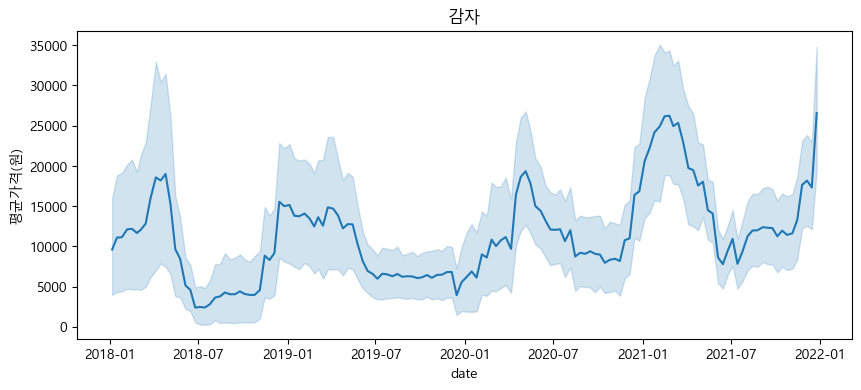

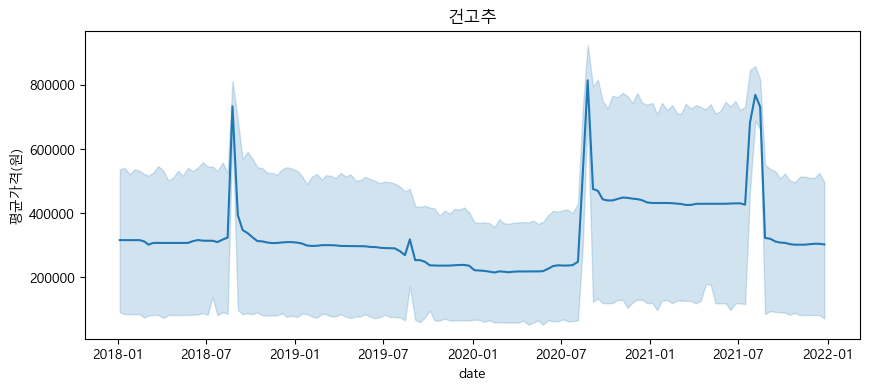

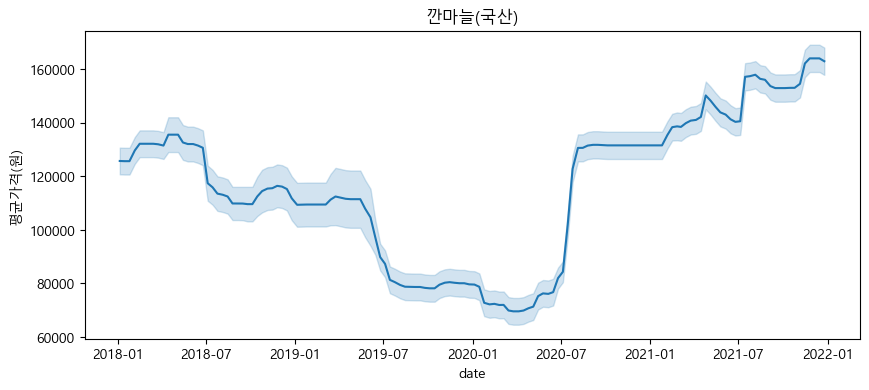

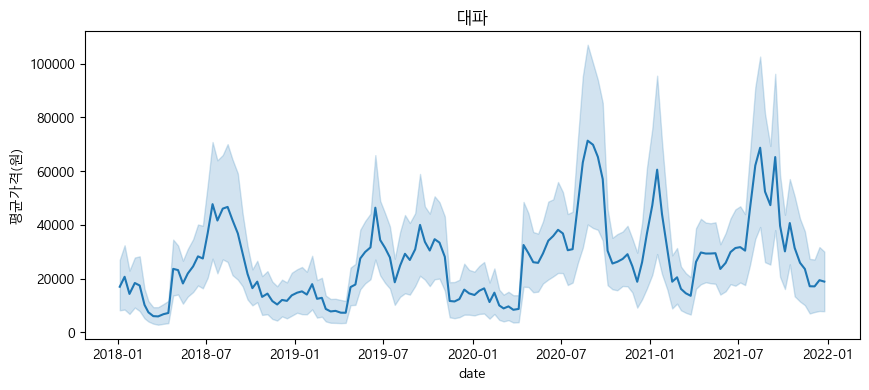

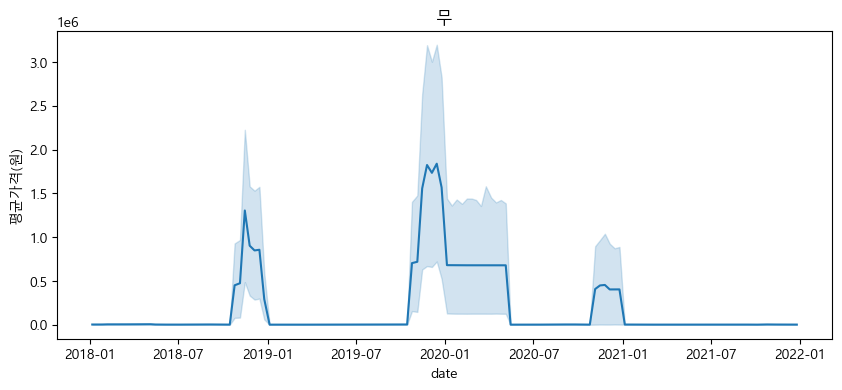

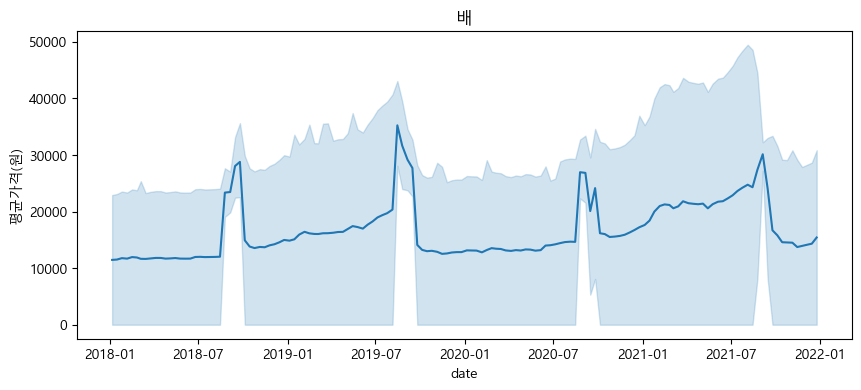

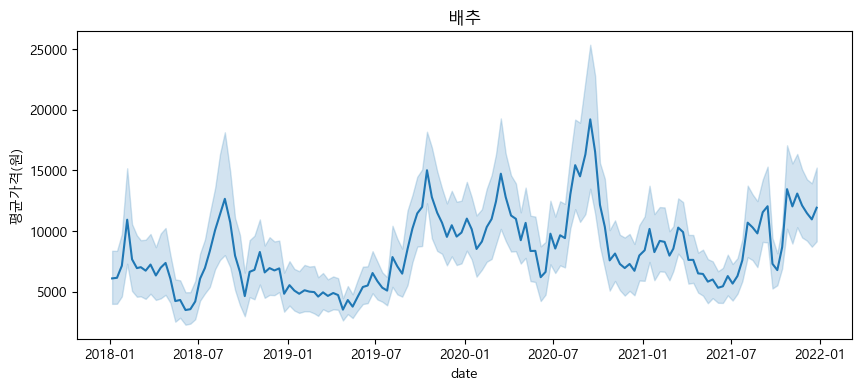

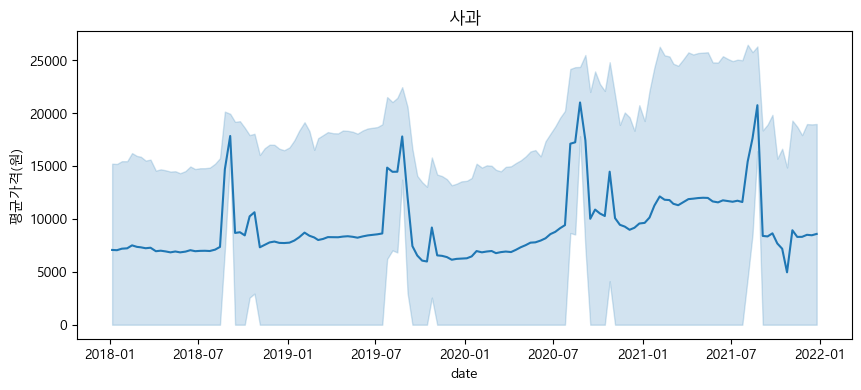

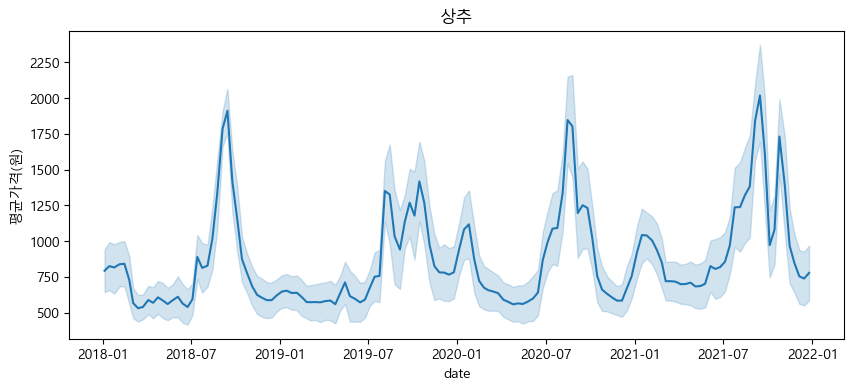

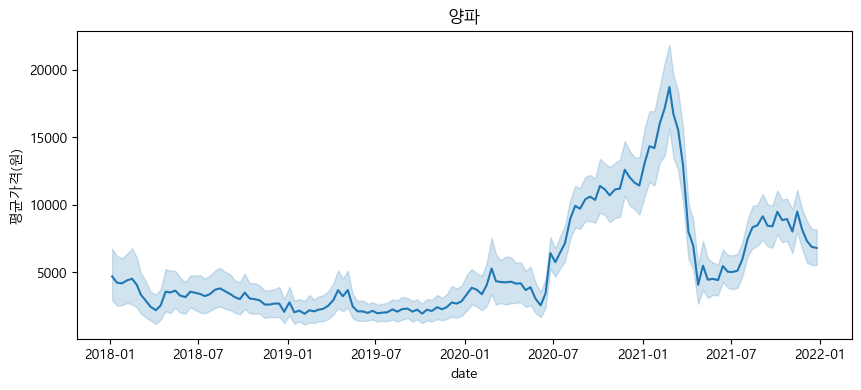

In [9]:
for item in train_merged["품목명"].unique():

    subset = train_merged[train_merged["품목명"] == item]

    plt.figure(figsize=(10,4))
    sns.lineplot(data=subset, x="date", y="평균가격(원)")
    plt.title(item)
    plt.show()

<Axes: xlabel='date', ylabel='평균가격(원)'>

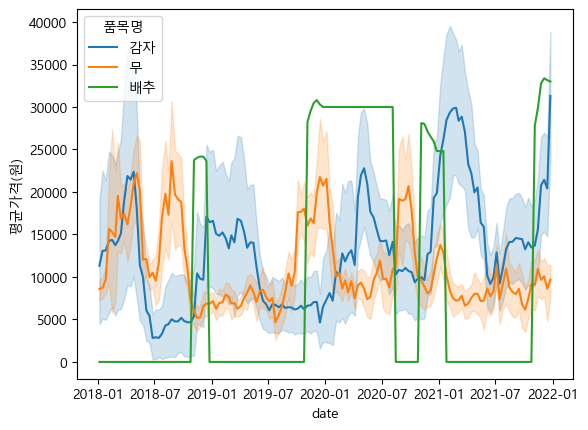

In [10]:
subset = train_merged[train_merged["거래단위"] == "20키로상자"]

sns.lineplot(data=subset, x="date", y="평균가격(원)", hue="품목명")

<Axes: xlabel='품목명', ylabel='log_price'>

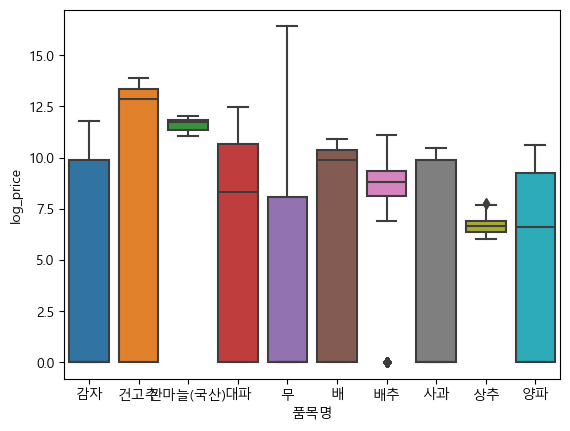

In [11]:
train_merged["log_price"] = np.log1p(train_merged["평균가격(원)"])

sns.boxplot(data=train_merged, x="품목명", y="log_price")

In [17]:
#베이스라인 코드 돌려보기
############################################################
# 0. 라이브러리
############################################################
import os
import glob
import warnings
import re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

# lightgbm이 설치 안 되어 있으면 아래 주석 해제 후 1회 실행
# !pip install lightgbm
from lightgbm import LGBMRegressor


############################################################
# 1. 설정
############################################################
TRAIN_PATH = "./train/train.csv"
TEST_GLOB = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH = "baseline_xgb_lgb_submission.csv"

# 대회 설명의 정확한 target map
TARGET_MAP = {
    "건고추": {"품종명": "화건", "거래단위": "30 kg", "등급": "상품"},
    "사과": {"품종명": ["홍로", "후지"], "거래단위": "10 개", "등급": "상품"},  # 사과는 두 품종 평균
    "감자": {"품종명": "감자 수미", "거래단위": "20키로상자", "등급": "상"},
    "배": {"품종명": "신고", "거래단위": "10 개", "등급": "상품"},
    "깐마늘(국산)": {"품종명": "깐마늘(국산)", "거래단위": "20 kg", "등급": "상품"},
    "무": {"품종명": "무", "거래단위": "20키로상자", "등급": "상"},
    "상추": {"품종명": "청", "거래단위": "100 g", "등급": "상품"},
    "배추": {"품종명": "배추", "거래단위": "10키로망대", "등급": "상"},
    "양파": {"품종명": "양파", "거래단위": "1키로", "등급": "상"},
    "대파": {"품종명": "대파(일반)", "거래단위": "1키로단", "등급": "상"},
}


############################################################
# 2. 유틸 함수
############################################################
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df

import re
import pandas as pd
import numpy as np

def soon_to_date(x):
    """
    train:
      201801상순, 201801중순, 201801하순
    test:
      T-8, T-7, ..., T-1, T
      또는 T-8순, T순 같은 형태도 같이 허용
    """
    x = str(x).strip()

    # 1. train absolute 형식
    if re.match(r"^\d{6}(상순|중순|하순)$", x):
        year = int(x[:4])
        month = int(x[4:6])
        soon = x[6:]

        if soon == "상순":
            day = 1
        elif soon == "중순":
            day = 11
        else:
            day = 21

        return pd.Timestamp(year=year, month=month, day=day)

    # 2. test relative 형식: T, T-8, T+1, T-8순, T순 ...
    if re.match(r"^T([+-]\d+)?(순)?$", x):
        base = pd.Timestamp(2000, 1, 21)  # T의 기준 가상 날짜

        if x in ["T", "T순"]:
            offset = 0
        else:
            offset = int(re.findall(r"([+-]\d+)", x)[0])

        return base + pd.Timedelta(days=10 * offset)

    raise ValueError(f"알 수 없는 시점 형식: {x}")

def date_to_soon(dt):
    year = dt.year
    month = dt.month
    day = dt.day

    if day <= 10:
        soon = "상순"
    elif day <= 20:
        soon = "중순"
    else:
        soon = "하순"

    return f"{year}{str(month).zfill(2)}{soon}"

def next_soon_str(soon_str, step=1):
    """
    train absolute 형식 / test relative 형식 둘 다 처리
    예:
      202112하순 -> 202201상순
      T-1 -> T
      T -> T+1
    """
    x = str(soon_str).strip()

    # 1. test relative 형식
    if re.match(r"^T([+-]\d+)?(순)?$", x):
        if x in ["T", "T순"]:
            cur = 0
        else:
            cur = int(re.findall(r"([+-]\d+)", x)[0])

        new_val = cur + step

        if new_val == 0:
            return "T"
        elif new_val > 0:
            return f"T+{new_val}"
        else:
            return f"T{new_val}"

    # 2. train absolute 형식
    dt = soon_to_date(x)

    for _ in range(step):
        if dt.day == 1:
            dt = pd.Timestamp(dt.year, dt.month, 11)
        elif dt.day == 11:
            dt = pd.Timestamp(dt.year, dt.month, 21)
        else:
            if dt.month == 12:
                dt = pd.Timestamp(dt.year + 1, 1, 1)
            else:
                dt = pd.Timestamp(dt.year, dt.month + 1, 1)

    return date_to_soon(dt)

def make_time_features(df):
    df = df.copy()

    df["date"] = df["시점"].apply(soon_to_date)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day

    def extract_soon_label(x):
        x = str(x).strip()

        if "상순" in x:
            return "상순"
        elif "중순" in x:
            return "중순"
        elif "하순" in x:
            return "하순"
        elif re.match(r"^T([+-]\d+)?(순)?$", x):
            # test 상대시점은 순 대신 relative로 표시
            return "relative"
        else:
            return "unknown"

    df["soon"] = df["시점"].apply(extract_soon_label)

    def extract_t_index(x):
        x = str(x).strip()

        if x in ["T", "T순"]:
            return 0

        if re.match(r"^T([+-]\d+)?(순)?$", x):
            vals = re.findall(r"([+-]\d+)", x)
            if len(vals) > 0:
                return int(vals[0])
            return 0

        return np.nan

    df["t_index"] = df["시점"].apply(extract_t_index)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df

def select_target_rows(df, target_map):
    """
    대회 예측 대상 10개 조합만 필터링
    사과는 홍로/후지 둘 다 선택
    """
    out = []

    for item, cond in target_map.items():
        if item == "사과":
            temp = df[
                (df["품목명"] == item) &
                (df["품종명"].isin(cond["품종명"])) &
                (df["거래단위"] == cond["거래단위"]) &
                (df["등급"] == cond["등급"])
            ].copy()
        else:
            temp = df[
                (df["품목명"] == item) &
                (df["품종명"] == cond["품종명"]) &
                (df["거래단위"] == cond["거래단위"]) &
                (df["등급"] == cond["등급"])
            ].copy()

        out.append(temp)

    out = pd.concat(out, axis=0).reset_index(drop=True)
    return out

def fill_normal_price(df, group_cols):
    """
    평년 평균가격 0 처리
    """
    df = df.copy()

    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df.groupby(group_cols)["평년 평균가격(원)"].transform(
            lambda x: x.ffill().bfill()
        )
        df["평년 평균가격(원)"] = df.groupby(group_cols)["평년 평균가격(원)"].transform(
            lambda x: x.fillna(x.mean())
        )
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
            df["평년 평균가격(원)"].median()
        )

    return df

def make_series_features(df, group_cols):
    """
    lag, rolling, diff 생성
    주의: rolling은 현재값 누수 방지를 위해 shift(1) 후 계산
    """
    df = df.copy()
    df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

    # lag 1~8
    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df.groupby(group_cols)["평균가격(원)"].shift(lag)

    # 발표용 강조 lag
    df["lag_3"] = df.groupby(group_cols)["평균가격(원)"].shift(3)
    df["lag_5"] = df.groupby(group_cols)["평균가격(원)"].shift(5)
    df["lag_7"] = df.groupby(group_cols)["평균가격(원)"].shift(7)

    # rolling
    df["rolling_mean_3"] = df.groupby(group_cols)["평균가격(원)"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    df["rolling_mean_5"] = df.groupby(group_cols)["평균가격(원)"].transform(
        lambda x: x.shift(1).rolling(5).mean()
    )
    df["rolling_std_5"] = df.groupby(group_cols)["평균가격(원)"].transform(
        lambda x: x.shift(1).rolling(5).std()
    )

    # 변화량
    df["diff_1"] = df.groupby(group_cols)["평균가격(원)"].diff(1)
    df["diff_3"] = df.groupby(group_cols)["평균가격(원)"].diff(3)

    return df

def add_target_next(df, group_cols):
    """
    1-step ahead target 생성
    """
    df = df.copy()
    df["target_next"] = df.groupby(group_cols)["평균가격(원)"].shift(-1)
    return df

def make_basic_features(df, group_cols):
    """
    시간/평년대비/log 등 기본 feature 생성
    """
    df = df.copy()
    df = make_time_features(df)
    df = fill_normal_price(df, group_cols)

    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]
    df["log_price"] = np.log1p(df["평균가격(원)"])

    return df

def build_train_dataset(train_raw, target_map):
    """
    학습용 데이터셋 생성
    """
    group_cols = ["품목명", "품종명", "거래단위", "등급"]

    df = select_target_rows(train_raw, target_map)
    df = make_basic_features(df, group_cols)
    df = make_series_features(df, group_cols)
    df = add_target_next(df, group_cols)

    # target 없는 마지막 행 제거
    df = df.dropna(subset=["target_next"]).reset_index(drop=True)
    return df

def get_feature_cols(df):
    feature_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day", "t_index",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3"
    ]

    for lag in range(1, 9):
        feature_cols.append(f"price_lag_{lag}")

    feature_cols = [c for c in feature_cols if c in df.columns]
    return feature_cols

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def split_train_valid_by_last_steps(df, group_cols, valid_steps=3):
    """
    각 시계열별 마지막 valid_steps개를 validation으로 사용
    """
    train_parts = []
    valid_parts = []

    df = df.sort_values(group_cols + ["date"]).reset_index(drop=True)

    for _, g in df.groupby(group_cols):
        if len(g) <= valid_steps:
            continue
        train_parts.append(g.iloc[:-valid_steps])
        valid_parts.append(g.iloc[-valid_steps:])

    tr_df = pd.concat(train_parts).reset_index(drop=True)
    va_df = pd.concat(valid_parts).reset_index(drop=True)

    return tr_df, va_df

def fit_models(X_train, y_train):
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    lgb_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)
    lgb_model.fit(X_train, y_train)

    return xgb_model, lgb_model


############################################################
# 3. train / sample submission 로드
############################################################
train_raw = pd.read_csv(TRAIN_PATH)
sample_sub = pd.read_csv(SUBMISSION_PATH)

train_raw = clean_columns(train_raw)
sample_sub = clean_columns(sample_sub)

print("train_raw shape:", train_raw.shape)
print("sample_sub shape:", sample_sub.shape)


############################################################
# 4. train 데이터셋 생성
############################################################
group_cols = ["품목명", "품종명", "거래단위", "등급"]

train_model = build_train_dataset(train_raw, TARGET_MAP)
feature_cols = get_feature_cols(train_model)

print("\n[학습용 데이터 shape]")
print(train_model.shape)

print("\n[feature cols]")
print(feature_cols)

print("\n[대상 조합별 개수]")
print(
    train_model.groupby(["품목명", "품종명", "거래단위", "등급"]).size()
)


############################################################
# 5. validation 분리 및 성능 확인
############################################################
tr_df, va_df = split_train_valid_by_last_steps(train_model, group_cols, valid_steps=3)

X_train = tr_df[feature_cols].fillna(0)
y_train = tr_df["target_next"]

X_valid = va_df[feature_cols].fillna(0)
y_valid = va_df["target_next"]

print("\ntrain split:", X_train.shape, y_train.shape)
print("valid split:", X_valid.shape, y_valid.shape)

xgb_model, lgb_model = fit_models(X_train, y_train)

pred_xgb = xgb_model.predict(X_valid)
pred_lgb = lgb_model.predict(X_valid)
pred_blend = 0.5 * pred_xgb + 0.5 * pred_lgb

print("\n[Validation Score]")
print("[XGB]   MAE :", mean_absolute_error(y_valid, pred_xgb))
print("[XGB]   RMSE:", rmse(y_valid, pred_xgb))

print("[LGBM]  MAE :", mean_absolute_error(y_valid, pred_lgb))
print("[LGBM]  RMSE:", rmse(y_valid, pred_lgb))

print("[BLEND] MAE :", mean_absolute_error(y_valid, pred_blend))
print("[BLEND] RMSE:", rmse(y_valid, pred_blend))


############################################################
# 6. 전체 train으로 재학습
############################################################
X_full = train_model[feature_cols].fillna(0)
y_full = train_model["target_next"]

xgb_model, lgb_model = fit_models(X_full, y_full)

print("\n전체 데이터 재학습 완료")


############################################################
# 7. test 관련 함수
############################################################
def prepare_single_test(test_path, target_map):
    """
    test 파일 1개를 읽어 target 조합만 남기고 기본 feature 준비
    """
    df = pd.read_csv(test_path)
    df = clean_columns(df)

    # target 행만 필터링
    df = select_target_rows(df, target_map)

    # 기본 feature
    group_cols = ["품목명", "품종명", "거래단위", "등급"]
    df = make_basic_features(df, group_cols)

    return df

def rebuild_features_for_history(df_hist):
    """
    재귀예측 과정에서 누적된 history로부터 feature 재생성
    """
    group_cols = ["품목명", "품종명", "거래단위", "등급"]

    temp = df_hist.copy()
    temp = make_basic_features(temp, group_cols)
    temp = make_series_features(temp, group_cols)

    return temp

def predict_one_step_for_hist(hist_df, feature_cols, xgb_model, lgb_model):
    """
    hist_df 마지막 행들(각 그룹별 새로 추가된 행)에 대해 1-step 예측
    사과는 홍로, 후지 각각 예측 후 평균해서 하나의 '사과' 값으로 제출할 것임
    """
    hist_feat = rebuild_features_for_history(hist_df)

    pred_records = []

    # 각 그룹별 마지막 행 추출
    for _, g in hist_feat.groupby(["품목명", "품종명", "거래단위", "등급"]):
        g = g.sort_values("date")
        row = g.iloc[-1:].copy()

        X_pred = row[feature_cols].fillna(0)
        pred_xgb = xgb_model.predict(X_pred)[0]
        pred_lgb = lgb_model.predict(X_pred)[0]
        pred = 0.5 * pred_xgb + 0.5 * pred_lgb

        pred_records.append({
            "품목명": row["품목명"].values[0],
            "품종명": row["품종명"].values[0],
            "거래단위": row["거래단위"].values[0],
            "등급": row["등급"].values[0],
            "시점": row["시점"].values[0],
            "pred": pred
        })

    pred_df = pd.DataFrame(pred_records)
    return pred_df

def recursive_predict_for_file(test_path, target_map, feature_cols, xgb_model, lgb_model):
    """
    TEST_xx 한 파일에 대해 T+1, T+2, T+3 재귀 예측
    """
    base_name = os.path.basename(test_path).replace(".csv", "")  # TEST_00
    hist = prepare_single_test(test_path, target_map).copy()

    # 정렬
    hist = hist.sort_values(["품목명", "품종명", "거래단위", "등급", "date"]).reset_index(drop=True)

    all_submit_rows = []

    for step in [1, 2, 3]:
        # 각 target group에 대해 다음 시점 행 1개 추가
        new_rows = []

        for item, cond in target_map.items():
            if item == "사과":
                # 사과는 홍로, 후지 각각 추가
                apple_varieties = cond["품종명"]

                for v in apple_varieties:
                    g = hist[
                        (hist["품목명"] == "사과") &
                        (hist["품종명"] == v) &
                        (hist["거래단위"] == cond["거래단위"]) &
                        (hist["등급"] == cond["등급"])
                    ].copy().sort_values("date")
                    
                    if len(g) == 0:
                        continue

                    last_row = g.iloc[-1].copy()
                    next_soon = next_soon_str(last_row["시점"], step=1)

                    new_row = last_row.copy()
                    new_row["시점"] = next_soon
                    new_row["평균가격(원)"] = np.nan
                    new_rows.append(new_row)

            else:
                g = hist[
                    (hist["품목명"] == item) &
                    (hist["품종명"] == cond["품종명"]) &
                    (hist["거래단위"] == cond["거래단위"]) &
                    (hist["등급"] == cond["등급"])
                ].copy().sort_values("date")

                last_row = g.iloc[-1].copy()
                next_soon = next_soon_str(last_row["시점"], step=1)

                new_row = last_row.copy()
                new_row["시점"] = next_soon
                new_row["평균가격(원)"] = np.nan
                new_rows.append(new_row)

        new_rows = pd.DataFrame(new_rows)
        hist = pd.concat([hist, new_rows], axis=0).reset_index(drop=True)

        # 현재 step 예측
        pred_df = predict_one_step_for_hist(hist, feature_cols, xgb_model, lgb_model)

        # hist에 예측값 반영
        for _, row in pred_df.iterrows():
            mask = (
                (hist["품목명"] == row["품목명"]) &
                (hist["품종명"] == row["품종명"]) &
                (hist["거래단위"] == row["거래단위"]) &
                (hist["등급"] == row["등급"]) &
                (hist["시점"] == row["시점"])
            )
            hist.loc[mask, "평균가격(원)"] = row["pred"]

        # 제출 형식 정리
        # 사과는 홍로/후지 평균
        submit_row_name = f"{base_name}+{step}순"

        for item, cond in target_map.items():
            if item == "사과":
                apple_rows = pred_df[
                    (pred_df["품목명"] == "사과") &
                    (pred_df["품종명"].isin(cond["품종명"])) &
                    (pred_df["거래단위"] == cond["거래단위"]) &
                    (pred_df["등급"] == cond["등급"])
                ]
                
                if len(apple_rows) == 0:
                    apple_pred = np.nan
                else:
                    apple_pred = apple_rows["pred"].mean()

                all_submit_rows.append({
                    "시점": submit_row_name,
                    "품목명": "사과",
                    "pred": apple_pred
                })

            else:
                value = pred_df[
                    (pred_df["품목명"] == item) &
                    (pred_df["품종명"] == cond["품종명"]) &
                    (pred_df["거래단위"] == cond["거래단위"]) &
                    (pred_df["등급"] == cond["등급"])
                ]["pred"].values[0]

                all_submit_rows.append({
                    "시점": submit_row_name,
                    "품목명": item,
                    "pred": value
                })

    return pd.DataFrame(all_submit_rows)


############################################################
# 8. 모든 test 파일 예측
############################################################
test_files = sorted(glob.glob(TEST_GLOB))

print("\n[test 파일 개수]")
print(len(test_files))
print(test_files[:5])

all_preds = []

for path in test_files:
    print("predicting:", path)
    pred_df = recursive_predict_for_file(
        test_path=path,
        target_map=TARGET_MAP,
        feature_cols=feature_cols,
        xgb_model=xgb_model,
        lgb_model=lgb_model
    )
    all_preds.append(pred_df)

all_preds = pd.concat(all_preds).reset_index(drop=True)

print("\n[예측 결과 일부]")
print(all_preds.head(20))


############################################################
# 9. sample_submission 형식으로 변환
############################################################
submission = sample_sub.copy()

for _, row in all_preds.iterrows():
    submission.loc[
        submission["시점"] == row["시점"],
        row["품목명"]
    ] = row["pred"]

print("\n[submission 미리보기]")
print(submission.head(10))


############################################################
# 10. 저장
############################################################
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
sample_sub shape: (75, 11)

[학습용 데이터 shape]
(1429, 35)

[feature cols]
['평균가격(원)', '평년 평균가격(원)', '평년대비_차이', '평년대비_비율', 'year', 'month', 'day', 't_index', 'month_sin', 'month_cos', 'lag_3', 'lag_5', 'lag_7', 'rolling_mean_3', 'rolling_mean_5', 'rolling_std_5', 'diff_1', 'diff_3', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_4', 'price_lag_5', 'price_lag_6', 'price_lag_7', 'price_lag_8']

[대상 조합별 개수]
품목명      품종명      거래단위    등급
감자       감자 수미    20키로상자  상     143
건고추      화건       30 kg   상품    143
깐마늘(국산)  깐마늘(국산)  20 kg   상품    143
대파       대파(일반)   1키로단    상     143
무        무        20키로상자  상     143
배        신고       10 개    상품    143
배추       배추       10키로망대  상     143
사과       홍로       10 개    상품     18
         후지       10 개    상품    124
상추       청        100 g   상품    143
양파       양파       1키로     상     143
dtype: int64

train split: (1396, 26) (1396,)
valid split: (33, 26) (33,)
[LightGBM] [Warning] Found whitespace in feature_names, repl

In [23]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH = "./train/train.csv"
TEST_GLOB = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH = "baseline_direct_xgb_submission.csv"


############################################################
# 2. 대회에서 요구하는 정확한 예측 대상 조합
# - 사과는 홍로, 후지 2개 품종이 모두 포함됨
# - 제출 시 사과 컬럼 하나이므로 두 품종 예측값 평균 사용
############################################################
TARGET_MAP = {
    "건고추": {"품종명": ["화건"], "거래단위": "30 kg", "등급": "상품"},
    "사과": {"품종명": ["홍로", "후지"], "거래단위": "10 개", "등급": "상품"},
    "감자": {"품종명": ["감자 수미"], "거래단위": "20키로상자", "등급": "상"},
    "배": {"품종명": ["신고"], "거래단위": "10 개", "등급": "상품"},
    "깐마늘(국산)": {"품종명": ["깐마늘(국산)"], "거래단위": "20 kg", "등급": "상품"},
    "무": {"품종명": ["무"], "거래단위": "20키로상자", "등급": "상"},
    "상추": {"품종명": ["청"], "거래단위": "100 g", "등급": "상품"},
    "배추": {"품종명": ["배추"], "거래단위": "10키로망대", "등급": "상"},
    "양파": {"품종명": ["양파"], "거래단위": "1키로", "등급": "상"},
    "대파": {"품종명": ["대파(일반)"], "거래단위": "1키로단", "등급": "상"},
}


############################################################
# 3. 유틸 함수
############################################################
def clean_columns(df):
    """
    컬럼명 앞뒤 공백 제거, 중복 공백 제거
    """
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def soon_to_date(x):
    """
    train 데이터의 시점 형식:
    예) 201801상순, 201801중순, 201801하순
    이를 날짜형으로 변환
    """
    x = str(x).strip()

    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]

    if soon == "상순":
        day = 1
    elif soon == "중순":
        day = 11
    else:
        day = 21

    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    """
    시점으로부터 date/year/month/day 생성
    계절성 반영을 위해 month_sin, month_cos 생성
    """
    df = df.copy()

    df["date"] = df["시점"].apply(soon_to_date)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["soon"] = df["시점"].str[-2:]

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df


def fill_normal_price(df):
    """
    평년 평균가격 0은 결측으로 보고 보정
    """
    df = df.copy()

    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()

        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )

    return df


def make_series_features(df):
    """
    하나의 시계열에 대해 lag / rolling / diff feature 생성
    """
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    # lag feature
    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df["평균가격(원)"].shift(lag)

    # 대표 lag
    df["lag_3"] = df["평균가격(원)"].shift(3)
    df["lag_5"] = df["평균가격(원)"].shift(5)
    df["lag_7"] = df["평균가격(원)"].shift(7)

    # rolling feature
    df["rolling_mean_3"] = df["평균가격(원)"].shift(1).rolling(3).mean()
    df["rolling_mean_5"] = df["평균가격(원)"].shift(1).rolling(5).mean()
    df["rolling_std_5"] = df["평균가격(원)"].shift(1).rolling(5).std()

    # 차분
    df["diff_1"] = df["평균가격(원)"].diff(1)
    df["diff_3"] = df["평균가격(원)"].diff(3)

    # 평년 대비
    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]

    return df


def get_feature_cols():
    """
    모델 입력 feature 목록
    """
    feature_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3",
    ]

    for lag in range(1, 9):
        feature_cols.append(f"price_lag_{lag}")

    return feature_cols


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def select_target_subset(train_raw, item, varieties, unit, grade):
    """
    train에서 해당 품목/품종/거래단위/등급 조합만 추출
    """
    temp = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    return temp


def build_item_train_df(train_raw, item, config):
    """
    한 품목에 대해 direct multi-horizon 학습용 데이터 생성
    """
    varieties = config["품종명"]
    unit = config["거래단위"]
    grade = config["등급"]

    df = select_target_subset(train_raw, item, varieties, unit, grade)

    out_list = []

    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()

        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # direct target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if len(out_list) == 0:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)
    return out


def train_validate_direct_models(item_df, feature_cols):
    """
    한 품목 데이터에 대해 horizon 1/2/3별 XGBoost 학습 + validation
    """
    item_df = item_df.copy()
    item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

    results = {}
    models = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"

        # 타깃 결측 제거
        df_h = item_df.dropna(subset=[target_col]).copy()

        tr_parts = []
        va_parts = []

        # 품종별 마지막 3개를 validation으로 사용
        for _, g in df_h.groupby("품종명"):
            g = g.sort_values("date")
            if len(g) <= 3:
                continue
            tr_parts.append(g.iloc[:-3])
            va_parts.append(g.iloc[-3:])

        tr_df = pd.concat(tr_parts).reset_index(drop=True)
        va_df = pd.concat(va_parts).reset_index(drop=True)

        X_train = tr_df[feature_cols].fillna(0)
        y_train = tr_df[target_col]

        X_valid = va_df[feature_cols].fillna(0)
        y_valid = va_df[target_col]

        model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        )

        model.fit(X_train, y_train)

        pred_valid = model.predict(X_valid)

        results[horizon] = {
            "MAE": mean_absolute_error(y_valid, pred_valid),
            "RMSE": rmse(y_valid, pred_valid),
            "n_train": len(tr_df),
            "n_valid": len(va_df),
        }

        # 전체 데이터로 재학습
        X_full = df_h[feature_cols].fillna(0)
        y_full = df_h[target_col]

        model.fit(X_full, y_full)
        models[horizon] = model

    return models, results


def build_test_last_rows(test_path, item, config):
    """
    test 파일에서 해당 품목의 마지막 관측 row(T)를 추출
    direct 방식이므로 마지막 관측 row만 사용
    """
    df = pd.read_csv(test_path)
    df = clean_columns(df)

    varieties = config["품종명"]
    unit = config["거래단위"]
    grade = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []

    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()

        if len(g) == 0:
            continue

        ################################################
        # test 시점 parsing
        # 예: T-8순, T-7순, ..., T순
        # 또는 T-8, T-7, ..., T
        ################################################
        def parse_t_idx(x):
            x = str(x).strip()
            x = x.replace("순", "")

            if x == "T":
                return 0
            if x.startswith("T-"):
                return int(x.replace("T", ""))
            if x.startswith("T+"):
                return int(x.replace("T", ""))

            raise ValueError(f"Unknown format: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        ################################################
        # 가상 날짜 생성
        ################################################
        base_date = pd.Timestamp(2000, 1, 21)
        g["date"] = g["t_idx"].apply(lambda v: base_date + pd.Timedelta(days=10 * v))

        ################################################
        # 시간 feature 생성
        ################################################
        g["year"] = g["date"].dt.year
        g["month"] = g["date"].dt.month
        g["day"] = g["date"].dt.day
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        ################################################
        # 가격 관련 feature 생성
        ################################################
        g = fill_normal_price(g)
        g = make_series_features(g)

        ################################################
        # 마지막 관측 row(T)만 사용
        ################################################
        last_row = g.iloc[-1:].copy()
        out_list.append(last_row)

    if len(out_list) == 0:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)
    return out


############################################################
# 4. 데이터 불러오기
############################################################
train_raw = pd.read_csv(TRAIN_PATH)
sample_sub = pd.read_csv(SUBMISSION_PATH)

train_raw = clean_columns(train_raw)
sample_sub = clean_columns(sample_sub)

print("train_raw shape:", train_raw.shape)
print("sample_sub shape:", sample_sub.shape)


############################################################
# 5. 품목별 direct multi-horizon 모델 학습
############################################################
feature_cols = get_feature_cols()

all_models = {}
all_results = {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 70)
    print(f"[{item}] 학습 시작")

    item_df = build_item_train_df(train_raw, item, config)

    print("데이터 개수:", item_df.shape)

    use_cols = [c for c in feature_cols if c in item_df.columns]

    models, results = train_validate_direct_models(item_df, use_cols)

    all_models[item] = {
        "models": models,
        "feature_cols": use_cols
    }
    all_results[item] = results

    for h in [1, 2, 3]:
        print(
            f"h={h} | "
            f"train={results[h]['n_train']} | "
            f"valid={results[h]['n_valid']} | "
            f"MAE={results[h]['MAE']:.4f} | "
            f"RMSE={results[h]['RMSE']:.4f}"
        )


############################################################
# 6. 품목별 validation 성능 요약 출력
############################################################
print("\n" + "=" * 70)
print("[품목별 Validation Score 요약]")

summary_rows = []
for item, res in all_results.items():
    for h in [1, 2, 3]:
        summary_rows.append({
            "품목명": item,
            "horizon": h,
            "MAE": res[h]["MAE"],
            "RMSE": res[h]["RMSE"]
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)


############################################################
# 7. test 예측
# - 각 TEST 파일마다
# - 각 품목의 마지막 관측 row(T) 추출
# - h1/h2/h3 모델로 직접 예측
# - 사과는 홍로/후지 평균
############################################################
test_files = sorted(glob.glob(TEST_GLOB))

print("\n[test 파일 개수]")
print(len(test_files))
print(test_files[:5])

submission_rows = []

for test_path in test_files:
    base_name = os.path.basename(test_path).replace(".csv", "")  # TEST_00

    print("predicting:", base_name)

    horizon_preds = {
        1: {},
        2: {},
        3: {}
    }

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config)

        # 품목 데이터가 없으면 NaN
        if len(last_rows) == 0:
            for h in [1, 2, 3]:
                horizon_preds[h][item] = np.nan
            continue

        use_cols = all_models[item]["feature_cols"]
        models = all_models[item]["models"]

        for h in [1, 2, 3]:
            model = models[h]
            X_test = last_rows[use_cols].fillna(0)
            pred_values = model.predict(X_test)

            # 품종 1개면 그대로, 여러 개(사과)는 평균
            final_pred = max(float(np.mean(pred_values)), 0)
            horizon_preds[h][item] = final_pred

    # sample_submission 형식 맞추기
    for h in [1, 2, 3]:
        row = {"시점": f"{base_name}+{h}순"}
        for item in TARGET_MAP.keys():
            row[item] = horizon_preds[h][item]
        submission_rows.append(row)


############################################################
# 8. 제출 파일 생성
############################################################
submission = pd.DataFrame(submission_rows)

# sample_submission 컬럼 순서 맞추기
submission = submission[sample_sub.columns]

print("\n[submission 미리보기]")
print(submission.head(10))


############################################################
# 9. 저장
############################################################
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
sample_sub shape: (75, 11)

[건고추] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=1572.4375 | RMSE=1893.1739
h=2 | train=139 | valid=3 | MAE=10438.8750 | RMSE=13939.2174
h=3 | train=138 | valid=3 | MAE=23728.4792 | RMSE=23962.7273

[사과] 학습 시작
데이터 개수: (144, 35)
h=1 | train=136 | valid=6 | MAE=1361.4460 | RMSE=1750.3428
h=2 | train=134 | valid=6 | MAE=1564.0254 | RMSE=1786.1496
h=3 | train=132 | valid=6 | MAE=1129.3978 | RMSE=1533.9758

[감자] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=3460.9791 | RMSE=3559.3111
h=2 | train=139 | valid=3 | MAE=2705.3806 | RMSE=3768.4117
h=3 | train=138 | valid=3 | MAE=6142.5668 | RMSE=7595.8897

[배] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=1304.8262 | RMSE=1628.8628
h=2 | train=139 | valid=3 | MAE=1403.8743 | RMSE=1622.0846
h=3 | train=138 | valid=3 | MAE=1354.0990 | RMSE=1584.5356

[깐마늘(국산)] 학습 시작
데이터 개수: (144, 35)
h=1 | train=140 | valid=3 | MAE=3693.6771 | RMSE=3892.0822
h=2 | train=139 | v

In [1]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH      = "./train/train.csv"
ORIGIN_PATH     = "./train/meta/TRAIN_산지공판장_2018-2021.csv"
WHOLESALE_PATH  = "./train/meta/TRAIN_전국도매_2018-2021.csv"   # 건고추/깐마늘용
TEST_GLOB       = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH     = "submission_supply.csv"


############################################################
# 2. 예측 대상 TARGET_MAP
############################################################
TARGET_MAP = {
    "건고추":      {"품종명": ["화건"],          "거래단위": "30 kg",      "등급": "상품"},
    "사과":        {"품종명": ["홍로", "후지"],   "거래단위": "10 개",      "등급": "상품"},
    "감자":        {"품종명": ["감자 수미"],      "거래단위": "20키로상자",  "등급": "상"},
    "배":          {"품종명": ["신고"],           "거래단위": "10 개",      "등급": "상품"},
    "깐마늘(국산)":{"품종명": ["깐마늘(국산)"],  "거래단위": "20 kg",      "등급": "상품"},
    "무":          {"품종명": ["무"],             "거래단위": "20키로상자",  "등급": "상"},
    "상추":        {"품종명": ["청"],             "거래단위": "100 g",      "등급": "상품"},
    "배추":        {"품종명": ["배추"],           "거래단위": "10키로망대",  "등급": "상"},
    "양파":        {"품종명": ["양파"],           "거래단위": "1키로",       "등급": "상"},
    "대파":        {"품종명": ["대파(일반)"],     "거래단위": "1키로단",     "등급": "상"},
}

# 산지공판장 품목명 매핑
# 건고추, 깐마늘(국산)은 산지공판장에 없음 → 전국도매에서 보완
ORIGIN_ITEM_MAP = {
    "건고추":      None,
    "사과":        "사과",
    "감자":        "감자",
    "배":          "배",
    "깐마늘(국산)":None,
    "무":          "무",
    "상추":        "상추",
    "배추":        "배추",
    "양파":        "양파",
    "대파":        "대파",
}

# 전국도매 품목명 매핑
# ★ 실제 파일 로드 후 셀 [공급량 매핑 확인]에서 출력값 보고 수정
WHOLESALE_ITEM_MAP = {
    "건고추":      "건고추",
    "깐마늘(국산)":"깐마늘(국산)",
}


############################################################
# 3. 공급량 메타 데이터 전처리
############################################################

def _rename_meta_cols(df):
    """전순/전달/전년/평년 컬럼명 정리"""
    col_map = {}
    for c in df.columns:
        if "전순 평균가격" in c:  col_map[c] = "전순평균가"
        elif "전달 평균가격" in c: col_map[c] = "전달평균가"
        elif "전년 평균가격" in c: col_map[c] = "전년평균가"
        elif "평년 평균가격" in c: col_map[c] = "평년평균가"
    return df.rename(columns=col_map)


def _aggregate_supply(df, group_col="품목명"):
    """
    (시점 × 품목명) 단위로 공급량 집계 후 lag/rolling 피처 생성
    반환 컬럼: 시점, group_col, supply_반입량, supply_경매건수,
               supply_반입량_lag1~3, supply_반입량_rolling3, supply_반입량_diff1
    """
    grp = df.groupby(["시점", group_col]).agg(
        supply_반입량   = ("총반입량(kg)", "sum"),
        supply_경매건수 = ("경매 건수",    "sum"),
    ).reset_index()

    grp["_date"] = grp["시점"].apply(
        lambda x: pd.Timestamp(int(x[:4]), int(x[4:6]),
                               1 if x[6:]=="상순" else (11 if x[6:]=="중순" else 21))
    )
    grp = grp.sort_values([group_col, "_date"]).reset_index(drop=True)

    # lag (누수 없도록 shift: 예측 시점의 반입량은 이미 알 수 있는 값이므로 lag0 사용 가능)
    # 단, lag1~3도 추가해 공급 추세 반영
    for lag in [1, 2, 3]:
        grp[f"supply_반입량_lag{lag}"] = grp.groupby(group_col)["supply_반입량"].shift(lag)

    grp["supply_반입량_rolling3"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    grp["supply_반입량_diff1"] = grp.groupby(group_col)["supply_반입량"].diff(1)

    return grp.drop(columns=["_date"])


def load_supply_meta(origin_path, wholesale_path=None):
    """
    산지공판장 + 전국도매 공급량을 합쳐 품목별 공급량 테이블 반환

    반환값: dict  {train_품목명 → DataFrame(시점, supply_* 컬럼들)}
    """
    # ── 산지공판장 ──────────────────────────────────────────
    origin = pd.read_csv(origin_path, encoding="utf-8")
    origin.columns = origin.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    origin = _rename_meta_cols(origin)
    origin["총반입량(kg)"] = pd.to_numeric(origin["총반입량(kg)"], errors="coerce").fillna(0)
    origin_agg = _aggregate_supply(origin, "품목명")

    # ── 전국도매 (건고추·깐마늘 보완) ───────────────────────
    wholesale_agg = None
    if wholesale_path and os.path.exists(wholesale_path):
        ws = None
        for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr"]:
            try:
                ws = pd.read_csv(wholesale_path, encoding=enc)
                break
            except Exception:
                continue

        if ws is not None:
            ws.columns = ws.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            ws = _rename_meta_cols(ws)
            ws["총반입량(kg)"] = pd.to_numeric(ws["총반입량(kg)"], errors="coerce").fillna(0)
            wholesale_agg = _aggregate_supply(ws, "품목명")

            actual_items = sorted(ws["품목명"].unique())
            print(f"[전국도매] 실제 품목명: {actual_items}")
            print(f"           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요")
        else:
            print("[전국도매] 파일 로드 실패")
    else:
        print("[전국도매] 파일 없음 → 건고추/깐마늘 공급량은 0으로 처리")

    # ── 품목별 공급량 테이블 구성 ───────────────────────────
    supply_dict = {}
    supply_cols = ["시점", "supply_반입량", "supply_경매건수",
                   "supply_반입량_lag1", "supply_반입량_lag2", "supply_반입량_lag3",
                   "supply_반입량_rolling3", "supply_반입량_diff1"]

    for train_item, origin_item in ORIGIN_ITEM_MAP.items():
        if origin_item is not None and origin_item in origin_agg["품목명"].values:
            sub = origin_agg[origin_agg["품목명"] == origin_item].copy()
            supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
        else:
            # 산지공판장에 없는 품목 → 전국도매에서 시도
            ws_item = WHOLESALE_ITEM_MAP.get(train_item)
            if wholesale_agg is not None and ws_item is not None:
                # 자동 매칭 시도 (정확히 없으면 유사 품목명 탐색)
                if ws_item not in wholesale_agg["품목명"].values:
                    candidates = [a for a in wholesale_agg["품목명"].unique()
                                  if train_item in a or a in train_item]
                    if candidates:
                        ws_item = candidates[0]
                        print(f"  [자동매칭] {train_item} → {ws_item}")

                if ws_item in wholesale_agg["품목명"].values:
                    sub = wholesale_agg[wholesale_agg["품목명"] == ws_item].copy()
                    supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
                    print(f"  [전국도매 사용] {train_item} 공급량 추가 완료")
                    continue

            # 둘 다 없으면 None (→ 나중에 0으로 처리)
            supply_dict[train_item] = None

    # 커버 현황 출력
    print("\n[공급량 피처 커버 현황]")
    for item, tbl in supply_dict.items():
        status = f"✓ ({len(tbl)}행)" if tbl is not None else "✗ (0으로 처리)"
        print(f"  {item:<15} {status}")

    return supply_dict


############################################################
# 4. 기존 유틸 함수 (원본 그대로 유지)
############################################################

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def soon_to_date(x):
    x = str(x).strip()
    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]
    day = 1 if soon == "상순" else (11 if soon == "중순" else 21)
    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    df = df.copy()
    df["date"]      = df["시점"].apply(soon_to_date)
    df["year"]      = df["date"].dt.year
    df["month"]     = df["date"].dt.month
    df["day"]       = df["date"].dt.day
    df["soon"]      = df["시점"].str[-2:]
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def fill_normal_price(df):
    df = df.copy()
    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()
        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )
    return df


def make_series_features(df):
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df["평균가격(원)"].shift(lag)

    df["lag_3"] = df["평균가격(원)"].shift(3)
    df["lag_5"] = df["평균가격(원)"].shift(5)
    df["lag_7"] = df["평균가격(원)"].shift(7)

    df["rolling_mean_3"] = df["평균가격(원)"].shift(1).rolling(3).mean()
    df["rolling_mean_5"] = df["평균가격(원)"].shift(1).rolling(5).mean()
    df["rolling_std_5"]  = df["평균가격(원)"].shift(1).rolling(5).std()

    df["diff_1"] = df["평균가격(원)"].diff(1)
    df["diff_3"] = df["평균가격(원)"].diff(3)

    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]

    return df


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


############################################################
# 5. 공급량 병합 함수
############################################################

# 공급량 피처 컬럼 목록 (전역 상수로 관리)
SUPPLY_COLS = [
    "supply_반입량",
    "supply_경매건수",
    "supply_반입량_lag1",
    "supply_반입량_lag2",
    "supply_반입량_lag3",
    "supply_반입량_rolling3",
    "supply_반입량_diff1",
]


def merge_supply(item_df, supply_dict, item_name):
    """
    품목 데이터에 공급량 피처를 시점 기준으로 병합
    - 공급량 없는 품목(건고추/깐마늘 등)은 0으로 채움
    - 병합 후 결측은 앞뒤 보간
    """
    supply_tbl = supply_dict.get(item_name)

    if supply_tbl is None:
        # 공급량 데이터 없음 → 0 피처 추가
        for col in SUPPLY_COLS:
            item_df[col] = 0.0
        return item_df

    merged = item_df.merge(supply_tbl, on="시점", how="left")

    # 결측 보간: ffill → bfill → 0
    for col in SUPPLY_COLS:
        if col in merged.columns:
            merged[col] = merged[col].ffill().bfill().fillna(0)
        else:
            merged[col] = 0.0

    return merged


############################################################
# 6. 학습 데이터 생성 (공급량 포함)
############################################################

def build_item_train_df(train_raw, item, config, supply_dict):
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    df = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()
        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # direct target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if not out_list:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)

    # 공급량 피처 병합
    out = merge_supply(out, supply_dict, item)

    return out


def get_feature_cols(df):
    """
    기존 피처 + 존재하는 공급량 피처만 동적으로 반환
    """
    base_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3",
    ]
    for lag in range(1, 9):
        base_cols.append(f"price_lag_{lag}")

    # 공급량 피처 추가 (데이터에 존재하는 것만)
    supply_in_df = [c for c in SUPPLY_COLS if c in df.columns]
    all_cols = base_cols + supply_in_df

    return [c for c in all_cols if c in df.columns]


############################################################
# 7. 모델 학습 (원본과 동일 구조)
############################################################

def train_validate_direct_models(item_df, feature_cols):
    item_df = item_df.copy()
    item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

    results = {}
    models  = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"
        df_h = item_df.dropna(subset=[target_col]).copy()

        tr_parts, va_parts = [], []
        for _, g in df_h.groupby("품종명"):
            g = g.sort_values("date")
            if len(g) <= 3:
                continue
            tr_parts.append(g.iloc[:-3])
            va_parts.append(g.iloc[-3:])

        if not tr_parts:
            continue

        tr_df = pd.concat(tr_parts).reset_index(drop=True)
        va_df = pd.concat(va_parts).reset_index(drop=True)

        use_cols = [c for c in feature_cols if c in df_h.columns]

        X_train = tr_df[use_cols].fillna(0)
        y_train = tr_df[target_col]
        X_valid = va_df[use_cols].fillna(0)
        y_valid = va_df[target_col]

        model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        )
        model.fit(X_train, y_train)
        pred_valid = model.predict(X_valid)

        results[horizon] = {
            "MAE":     mean_absolute_error(y_valid, pred_valid),
            "RMSE":    rmse(y_valid, pred_valid),
            "n_train": len(tr_df),
            "n_valid": len(va_df),
        }

        # 전체 데이터로 재학습
        model.fit(df_h[use_cols].fillna(0), df_h[target_col])
        models[horizon] = model

    return models, results


############################################################
# 8. 데이터 로딩 및 공급량 전처리
############################################################

train_raw  = clean_columns(pd.read_csv(TRAIN_PATH))
sample_sub = clean_columns(pd.read_csv(SUBMISSION_PATH))
print("train_raw shape:", train_raw.shape)

# 공급량 메타 데이터 로드
supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)

# ──────────────────────────────────────────────────────────
# ★ [공급량 매핑 확인] 전국도매 실제 품목명 출력 확인 후
#    건고추/깐마늘이 다른 이름이면 아래 주석 해제 후 수정
# ──────────────────────────────────────────────────────────
# WHOLESALE_ITEM_MAP["건고추"]      = "고추"        # 예시
# WHOLESALE_ITEM_MAP["깐마늘(국산)"] = "마늘"       # 예시
# supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)  # 재실행


############################################################
# 9. 품목별 Direct Multi-Horizon 모델 학습
############################################################

all_models  = {}
all_results = {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 70)
    print(f"[{item}] 학습 시작")

    item_df = build_item_train_df(train_raw, item, config, supply_dict)
    print(f"데이터 개수: {item_df.shape}")

    feature_cols = get_feature_cols(item_df)

    supply_used = [c for c in feature_cols if c.startswith("supply_")]
    print(f"피처: 전체 {len(feature_cols)}개 (공급량 {len(supply_used)}개)")

    models, results = train_validate_direct_models(item_df, feature_cols)

    all_models[item]  = {"models": models, "feature_cols": feature_cols}
    all_results[item] = results

    for h in [1, 2, 3]:
        if h not in results:
            continue
        print(
            f"h={h} | "
            f"train={results[h]['n_train']} | "
            f"valid={results[h]['n_valid']} | "
            f"MAE={results[h]['MAE']:.4f} | "
            f"RMSE={results[h]['RMSE']:.4f}"
        )


############################################################
# 10. Validation 성능 요약
############################################################

print("\n" + "=" * 70)
print("[품목별 Validation Score 요약]")

summary_rows = []
for item, res in all_results.items():
    for h in [1, 2, 3]:
        if h not in res:
            continue
        summary_rows.append({
            "품목명":    item,
            "horizon": h,
            "MAE":     res[h]["MAE"],
            "RMSE":    res[h]["RMSE"],
        })

print(pd.DataFrame(summary_rows).to_string(index=False))


############################################################
# 11. Test 예측
############################################################

def build_test_last_rows(test_path, item, config, supply_dict):
    df = clean_columns(pd.read_csv(test_path))

    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()
        if len(g) == 0:
            continue

        def parse_t_idx(x):
            x = str(x).strip().replace("순", "")
            if x == "T":        return 0
            if x.startswith("T-"): return int(x.replace("T", ""))
            if x.startswith("T+"): return int(x.replace("T", ""))
            raise ValueError(f"Unknown format: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        base_date  = pd.Timestamp(2000, 1, 21)
        g["date"]  = g["t_idx"].apply(lambda v: base_date + pd.Timedelta(days=10 * v))
        g["year"]  = g["date"].dt.year
        g["month"] = g["date"].dt.month
        g["day"]   = g["date"].dt.day
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        g = fill_normal_price(g)
        g = make_series_features(g)

        # ── 공급량: test 시점 비식별화 → train 최신 순의 값으로 근사 ──────
        supply_tbl = supply_dict.get(item)
        if supply_tbl is not None and len(supply_tbl) > 0:
            last_supply = supply_tbl.sort_values("시점").iloc[-1]
            for col in SUPPLY_COLS:
                g[col] = last_supply.get(col, 0.0)
        else:
            for col in SUPPLY_COLS:
                g[col] = 0.0

        out_list.append(g.iloc[-1:].copy())

    if not out_list:
        return pd.DataFrame()

    return pd.concat(out_list, axis=0).reset_index(drop=True)


############################################################
# 12. 모든 test 파일 예측 및 제출 파일 생성
############################################################

test_files = sorted(glob.glob(TEST_GLOB))
print(f"\n[test 파일 개수] {len(test_files)}")

submission_rows = []

for test_path in test_files:
    base_name = os.path.basename(test_path).replace(".csv", "")
    print(f"predicting: {base_name}")

    horizon_preds = {1: {}, 2: {}, 3: {}}

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config, supply_dict)

        if len(last_rows) == 0:
            for h in [1, 2, 3]:
                horizon_preds[h][item] = np.nan
            continue

        use_cols = all_models[item]["feature_cols"]
        models   = all_models[item]["models"]

        for h in [1, 2, 3]:
            model   = models[h]
            X_test  = last_rows[[c for c in use_cols if c in last_rows.columns]].fillna(0)
            pred    = model.predict(X_test)
            horizon_preds[h][item] = float(max(np.mean(pred), 0))

    for h in [1, 2, 3]:
        row = {"시점": f"{base_name}+{h}순"}
        for item in TARGET_MAP:
            row[item] = horizon_preds[h][item]
        submission_rows.append(row)


submission = pd.DataFrame(submission_rows)[sample_sub.columns]

print("\n[submission 미리보기]")
print(submission.head(10))

submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
[전국도매] 실제 품목명: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']
           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요
  [자동매칭] 깐마늘(국산) → 마늘
  [전국도매 사용] 깐마늘(국산) 공급량 추가 완료

[공급량 피처 커버 현황]
  건고추             ✗ (0으로 처리)
  사과              ✓ (144행)
  감자              ✓ (144행)
  배               ✓ (144행)
  깐마늘(국산)         ✓ (144행)
  무               ✓ (144행)
  상추              ✓ (144행)
  배추              ✓ (144행)
  양파              ✓ (144행)
  대파              ✓ (144행)

[건고추] 학습 시작
데이터 개수: (144, 42)
피처: 전체 32개 (공급량 7개)
h=1 | train=140 | valid=3 | MAE=7293.3542 | RMSE=7730.8052
h=2 | train=139 | valid=3 | MAE=12918.3750 | RMSE=15633.2184
h=3 | train=138 | valid=3 | MAE=17952.3542 | RMSE=20872.7965

[사과] 학습 시작
데이터 개수: (144, 42)
피처: 전체 32개 (공급량 7개)
h=1 | train=136 | valid=6 | MAE=1312.3242 | RMSE=1578.1495
h=2 | train=134 | valid=6 | MAE=1768.5280 | RMSE=1994.5126
h=3 | train=132 | valid=6 | MAE=1351.3861 | RMSE=1556.6907

[감자] 학습 시작
데이터 개수: (144, 42)
피처: 전체 32개 (공급량 7개)
h=1 

In [2]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH      = "./train/train.csv"
ORIGIN_PATH     = "./train/meta/TRAIN_산지공판장_2018-2021.csv"
WHOLESALE_PATH  = "./train/meta/TRAIN_전국도매_2018-2021.csv"   # 건고추/깐마늘용
WEATHER_PATH    = "./날씨.csv"
TEST_GLOB       = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH     = "submission_supply_weather.csv"


############################################################
# 2. 예측 대상 TARGET_MAP
############################################################
TARGET_MAP = {
    "건고추":      {"품종명": ["화건"],          "거래단위": "30 kg",      "등급": "상품"},
    "사과":        {"품종명": ["홍로", "후지"],   "거래단위": "10 개",      "등급": "상품"},
    "감자":        {"품종명": ["감자 수미"],      "거래단위": "20키로상자",  "등급": "상"},
    "배":          {"품종명": ["신고"],           "거래단위": "10 개",      "등급": "상품"},
    "깐마늘(국산)":{"품종명": ["깐마늘(국산)"],  "거래단위": "20 kg",      "등급": "상품"},
    "무":          {"품종명": ["무"],             "거래단위": "20키로상자",  "등급": "상"},
    "상추":        {"품종명": ["청"],             "거래단위": "100 g",      "등급": "상품"},
    "배추":        {"품종명": ["배추"],           "거래단위": "10키로망대",  "등급": "상"},
    "양파":        {"품종명": ["양파"],           "거래단위": "1키로",       "등급": "상"},
    "대파":        {"품종명": ["대파(일반)"],     "거래단위": "1키로단",     "등급": "상"},
}

# 산지공판장 품목명 매핑
# 건고추, 깐마늘(국산)은 산지공판장에 없음 → 전국도매에서 보완
ORIGIN_ITEM_MAP = {
    "건고추":      None,
    "사과":        "사과",
    "감자":        "감자",
    "배":          "배",
    "깐마늘(국산)":None,
    "무":          "무",
    "상추":        "상추",
    "배추":        "배추",
    "양파":        "양파",
    "대파":        "대파",
}

# 전국도매 품목명 매핑
# ★ 실제 파일 로드 후 셀 [공급량 매핑 확인]에서 출력값 보고 수정
WHOLESALE_ITEM_MAP = {
    "건고추":      "건고추",
    "깐마늘(국산)":"깐마늘(국산)",
}


############################################################
# 3. 공급량 메타 데이터 전처리
############################################################

def _rename_meta_cols(df):
    """전순/전달/전년/평년 컬럼명 정리"""
    col_map = {}
    for c in df.columns:
        if "전순 평균가격" in c:  col_map[c] = "전순평균가"
        elif "전달 평균가격" in c: col_map[c] = "전달평균가"
        elif "전년 평균가격" in c: col_map[c] = "전년평균가"
        elif "평년 평균가격" in c: col_map[c] = "평년평균가"
    return df.rename(columns=col_map)


def _aggregate_supply(df, group_col="품목명"):
    """
    (시점 × 품목명) 단위로 공급량 집계 후 lag/rolling 피처 생성
    반환 컬럼: 시점, group_col, supply_반입량, supply_경매건수,
               supply_반입량_lag1~3, supply_반입량_rolling3, supply_반입량_diff1
    """
    grp = df.groupby(["시점", group_col]).agg(
        supply_반입량   = ("총반입량(kg)", "sum"),
        supply_경매건수 = ("경매 건수",    "sum"),
    ).reset_index()

    grp["_date"] = grp["시점"].apply(
        lambda x: pd.Timestamp(int(x[:4]), int(x[4:6]),
                               1 if x[6:]=="상순" else (11 if x[6:]=="중순" else 21))
    )
    grp = grp.sort_values([group_col, "_date"]).reset_index(drop=True)

    # lag (누수 없도록 shift: 예측 시점의 반입량은 이미 알 수 있는 값이므로 lag0 사용 가능)
    # 단, lag1~3도 추가해 공급 추세 반영
    for lag in [1, 2, 3]:
        grp[f"supply_반입량_lag{lag}"] = grp.groupby(group_col)["supply_반입량"].shift(lag)

    grp["supply_반입량_rolling3"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    grp["supply_반입량_diff1"] = grp.groupby(group_col)["supply_반입량"].diff(1)

    return grp.drop(columns=["_date"])


def load_supply_meta(origin_path, wholesale_path=None):
    """
    산지공판장 + 전국도매 공급량을 합쳐 품목별 공급량 테이블 반환

    반환값: dict  {train_품목명 → DataFrame(시점, supply_* 컬럼들)}
    """
    # ── 산지공판장 ──────────────────────────────────────────
    origin = pd.read_csv(origin_path, encoding="utf-8")
    origin.columns = origin.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    origin = _rename_meta_cols(origin)
    origin["총반입량(kg)"] = pd.to_numeric(origin["총반입량(kg)"], errors="coerce").fillna(0)
    origin_agg = _aggregate_supply(origin, "품목명")

    # ── 전국도매 (건고추·깐마늘 보완) ───────────────────────
    wholesale_agg = None
    if wholesale_path and os.path.exists(wholesale_path):
        ws = None
        for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr"]:
            try:
                ws = pd.read_csv(wholesale_path, encoding=enc)
                break
            except Exception:
                continue

        if ws is not None:
            ws.columns = ws.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            ws = _rename_meta_cols(ws)
            ws["총반입량(kg)"] = pd.to_numeric(ws["총반입량(kg)"], errors="coerce").fillna(0)
            wholesale_agg = _aggregate_supply(ws, "품목명")

            actual_items = sorted(ws["품목명"].unique())
            print(f"[전국도매] 실제 품목명: {actual_items}")
            print(f"           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요")
        else:
            print("[전국도매] 파일 로드 실패")
    else:
        print("[전국도매] 파일 없음 → 건고추/깐마늘 공급량은 0으로 처리")

    # ── 품목별 공급량 테이블 구성 ───────────────────────────
    supply_dict = {}
    supply_cols = ["시점", "supply_반입량", "supply_경매건수",
                   "supply_반입량_lag1", "supply_반입량_lag2", "supply_반입량_lag3",
                   "supply_반입량_rolling3", "supply_반입량_diff1"]

    for train_item, origin_item in ORIGIN_ITEM_MAP.items():
        if origin_item is not None and origin_item in origin_agg["품목명"].values:
            sub = origin_agg[origin_agg["품목명"] == origin_item].copy()
            supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
        else:
            # 산지공판장에 없는 품목 → 전국도매에서 시도
            ws_item = WHOLESALE_ITEM_MAP.get(train_item)
            if wholesale_agg is not None and ws_item is not None:
                # 자동 매칭 시도 (정확히 없으면 유사 품목명 탐색)
                if ws_item not in wholesale_agg["품목명"].values:
                    candidates = [a for a in wholesale_agg["품목명"].unique()
                                  if train_item in a or a in train_item]
                    if candidates:
                        ws_item = candidates[0]
                        print(f"  [자동매칭] {train_item} → {ws_item}")

                if ws_item in wholesale_agg["품목명"].values:
                    sub = wholesale_agg[wholesale_agg["품목명"] == ws_item].copy()
                    supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
                    print(f"  [전국도매 사용] {train_item} 공급량 추가 완료")
                    continue

            # 둘 다 없으면 None (→ 나중에 0으로 처리)
            supply_dict[train_item] = None

    # 커버 현황 출력
    print("\n[공급량 피처 커버 현황]")
    for item, tbl in supply_dict.items():
        status = f"✓ ({len(tbl)}행)" if tbl is not None else "✗ (0으로 처리)"
        print(f"  {item:<15} {status}")

    return supply_dict


############################################################
# 4. 기존 유틸 함수 (원본 그대로 유지)
############################################################

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def soon_to_date(x):
    x = str(x).strip()
    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]
    day = 1 if soon == "상순" else (11 if soon == "중순" else 21)
    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    df = df.copy()
    df["date"]      = df["시점"].apply(soon_to_date)
    df["year"]      = df["date"].dt.year
    df["month"]     = df["date"].dt.month
    df["day"]       = df["date"].dt.day
    df["soon"]      = df["시점"].str[-2:]
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def fill_normal_price(df):
    df = df.copy()
    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()
        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )
    return df


def make_series_features(df):
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df["평균가격(원)"].shift(lag)

    df["lag_3"] = df["평균가격(원)"].shift(3)
    df["lag_5"] = df["평균가격(원)"].shift(5)
    df["lag_7"] = df["평균가격(원)"].shift(7)

    df["rolling_mean_3"] = df["평균가격(원)"].shift(1).rolling(3).mean()
    df["rolling_mean_5"] = df["평균가격(원)"].shift(1).rolling(5).mean()
    df["rolling_std_5"]  = df["평균가격(원)"].shift(1).rolling(5).std()

    df["diff_1"] = df["평균가격(원)"].diff(1)
    df["diff_3"] = df["평균가격(원)"].diff(3)

    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]

    return df


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


############################################################
# 5. 공급량 병합 함수
############################################################

############################################################
# 5-B. 품목별 날씨 피처 설계 (데이터 기반)
#
# 분석 결과 요약 (상관계수 절댓값):
#   상추  w_temp_diff_lag2  = -0.701  ★★★ 고온일교차 → 생육부진 → 가격↑
#   상추  w_humidity_lag2   = +0.672  ★★★
#   배추  w_humidity_lag2   = +0.502  ★★  생육기 습도
#   배추  w_temp_diff_lag2  = -0.445  ★★
#   감자  w_avg_temp_lag6   = -0.584  ★★★ 2개월 전 고온 → 수확량↓
#   양파  w_avg_temp_lag0   = -0.390  ★★  현재 기온 → 저장성 저하
#   사과  w_humidity_lag9   = -0.497  ★★★ 3개월 전 습도
#   무    w_rain_lag3       = +0.263  ★
#
#   건고추, 깐마늘(국산), 배, 대파 → 모든 lag < 0.20 → 날씨 피처 없음
############################################################
ITEM_WEATHER_FEATURES = {
    "상추": [("temp_diff", 2), ("humidity", 2), ("avg_temp", 2), ("rain", 2)],
    "배추": [("humidity",  2), ("temp_diff", 2), ("rain", 3),    ("avg_temp", 3)],
    "감자": [("avg_temp",  6), ("avg_temp", 3),  ("humidity", 0), ("temp_diff", 0)],
    "양파": [("avg_temp",  0), ("avg_temp", 1),  ("humidity", 0)],
    "사과": [("humidity",  9), ("avg_temp", 9),  ("sunshine", 2)],
    "무":   [("avg_temp",  6), ("rain", 3),       ("temp_diff", 3)],
    # 건고추, 깐마늘(국산), 배, 대파 → 없음
}


def load_weather(path):
    """
    날씨 CSV → 순 단위 집계 + lag 0~9 사전 생성
    반환: DataFrame (시점, 날씨 변수 × lag 컬럼)
    """
    df = None
    for enc in ["cp949", "utf-8", "utf-8-sig", "euc-kr"]:
        try:
            df = pd.read_csv(path, encoding=enc)
            break
        except Exception:
            continue

    df.columns = df.columns.str.strip()
    df["일시"]         = pd.to_datetime(df["일시"])
    df["day"]          = df["일시"].dt.day
    df["순"]           = df["day"].apply(lambda d: "상순" if d<=10 else ("중순" if d<=20 else "하순"))
    df["시점"]         = (df["일시"].dt.year.astype(str)
                         + df["일시"].dt.month.astype(str).str.zfill(2)
                         + df["순"])
    df["일강수량(mm)"] = df["일강수량(mm)"].fillna(0)
    df["일교차"]       = df["최고기온(°C)"] - df["최저기온(°C)"]

    wg = df.groupby("시점").agg(
        avg_temp  = ("평균기온(°C)",     "mean"),
        rain      = ("일강수량(mm)",     "sum"),
        humidity  = ("평균 상대습도(%)", "mean"),
        sunshine  = ("합계 일조시간(hr)", "sum"),
        temp_diff = ("일교차",           "mean"),
    ).reset_index().sort_values("시점").reset_index(drop=True)

    # lag 0~9 미리 생성
    for var in ["avg_temp", "rain", "humidity", "sunshine", "temp_diff"]:
        for lag in range(10):
            wg[f"w_{var}_lag{lag}"] = wg[var].shift(lag)

    print(f"[날씨] 집계 완료: {wg.shape}, 범위: {wg['시점'].min()} ~ {wg['시점'].max()}")
    return wg


def get_item_weather_cols(item):
    """품목별로 사용할 날씨 컬럼명 목록 반환"""
    specs = ITEM_WEATHER_FEATURES.get(item, [])
    return [f"w_{var}_lag{lag}" for var, lag in specs]


def merge_weather(item_df, weather_df, item):
    """
    품목 데이터에 해당 품목용 날씨 피처만 병합
    날씨 피처가 없는 품목은 그대로 반환
    """
    weather_cols = get_item_weather_cols(item)
    if not weather_cols:
        return item_df

    cols_to_merge = ["시점"] + [c for c in weather_cols if c in weather_df.columns]
    merged = item_df.merge(weather_df[cols_to_merge], on="시점", how="left")

    for col in weather_cols:
        if col in merged.columns:
            merged[col] = merged[col].ffill().bfill().fillna(0)
        else:
            merged[col] = 0.0

    return merged


# 공급량 피처 컬럼 목록 (전역 상수로 관리)
SUPPLY_COLS = [
    "supply_반입량",
    "supply_경매건수",
    "supply_반입량_lag1",
    "supply_반입량_lag2",
    "supply_반입량_lag3",
    "supply_반입량_rolling3",
    "supply_반입량_diff1",
]


def merge_supply(item_df, supply_dict, item_name):
    """
    품목 데이터에 공급량 피처를 시점 기준으로 병합
    - 공급량 없는 품목(건고추/깐마늘 등)은 0으로 채움
    - 병합 후 결측은 앞뒤 보간
    """
    supply_tbl = supply_dict.get(item_name)

    if supply_tbl is None:
        # 공급량 데이터 없음 → 0 피처 추가
        for col in SUPPLY_COLS:
            item_df[col] = 0.0
        return item_df

    merged = item_df.merge(supply_tbl, on="시점", how="left")

    # 결측 보간: ffill → bfill → 0
    for col in SUPPLY_COLS:
        if col in merged.columns:
            merged[col] = merged[col].ffill().bfill().fillna(0)
        else:
            merged[col] = 0.0

    return merged


############################################################
# 6. 학습 데이터 생성 (공급량 + 날씨 포함)
############################################################

def build_item_train_df(train_raw, item, config, supply_dict, weather_df):
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    df = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()
        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # direct target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if not out_list:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)

    # 공급량 피처 병합
    out = merge_supply(out, supply_dict, item)

    # 날씨 피처 병합 (품목별 설계된 변수만)
    out = merge_weather(out, weather_df, item)

    return out


def get_feature_cols(df, item):
    """
    기존 피처 + 공급량 피처 + 품목별 날씨 피처 동적 반환
    """
    base_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3",
    ]
    for lag in range(1, 9):
        base_cols.append(f"price_lag_{lag}")

    # 공급량 피처
    supply_in_df = [c for c in SUPPLY_COLS if c in df.columns]

    # 날씨 피처 (품목별로 다름)
    weather_in_df = [c for c in get_item_weather_cols(item) if c in df.columns]

    all_cols = base_cols + supply_in_df + weather_in_df
    return [c for c in all_cols if c in df.columns]


############################################################
# 7. 모델 학습 (원본과 동일 구조)
############################################################

def train_validate_direct_models(item_df, feature_cols):
    item_df = item_df.copy()
    item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

    results = {}
    models  = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"
        df_h = item_df.dropna(subset=[target_col]).copy()

        tr_parts, va_parts = [], []
        for _, g in df_h.groupby("품종명"):
            g = g.sort_values("date")
            if len(g) <= 3:
                continue
            tr_parts.append(g.iloc[:-3])
            va_parts.append(g.iloc[-3:])

        if not tr_parts:
            continue

        tr_df = pd.concat(tr_parts).reset_index(drop=True)
        va_df = pd.concat(va_parts).reset_index(drop=True)

        use_cols = [c for c in feature_cols if c in df_h.columns]

        X_train = tr_df[use_cols].fillna(0)
        y_train = tr_df[target_col]
        X_valid = va_df[use_cols].fillna(0)
        y_valid = va_df[target_col]

        model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        )
        model.fit(X_train, y_train)
        pred_valid = model.predict(X_valid)

        results[horizon] = {
            "MAE":     mean_absolute_error(y_valid, pred_valid),
            "RMSE":    rmse(y_valid, pred_valid),
            "n_train": len(tr_df),
            "n_valid": len(va_df),
        }

        # 전체 데이터로 재학습
        model.fit(df_h[use_cols].fillna(0), df_h[target_col])
        models[horizon] = model

    return models, results


############################################################
# 8. 데이터 로딩 및 공급량 전처리
############################################################

train_raw  = clean_columns(pd.read_csv(TRAIN_PATH))
sample_sub = clean_columns(pd.read_csv(SUBMISSION_PATH))
print("train_raw shape:", train_raw.shape)

# 공급량 메타 데이터 로드
supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)

# 날씨 데이터 로드
weather_df = load_weather(WEATHER_PATH)

# ──────────────────────────────────────────────────────────
# ★ [공급량 매핑 확인] 전국도매 실제 품목명 출력 확인 후
#    건고추/깐마늘이 다른 이름이면 아래 주석 해제 후 수정
# ──────────────────────────────────────────────────────────
# WHOLESALE_ITEM_MAP["건고추"]      = "고추"        # 예시
# WHOLESALE_ITEM_MAP["깐마늘(국산)"] = "마늘"       # 예시
# supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)  # 재실행


############################################################
# 9. 품목별 Direct Multi-Horizon 모델 학습
############################################################

all_models  = {}
all_results = {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 70)
    print(f"[{item}] 학습 시작")

    item_df = build_item_train_df(train_raw, item, config, supply_dict, weather_df)
    print(f"데이터 개수: {item_df.shape}")

    feature_cols = get_feature_cols(item_df, item)

    supply_used  = [c for c in feature_cols if c.startswith("supply_")]
    weather_used = [c for c in feature_cols if c.startswith("w_")]
    print(f"피처: 전체 {len(feature_cols)}개 (공급량 {len(supply_used)}개, 날씨 {len(weather_used)}개)")

    models, results = train_validate_direct_models(item_df, feature_cols)

    all_models[item]  = {"models": models, "feature_cols": feature_cols}
    all_results[item] = results

    for h in [1, 2, 3]:
        if h not in results:
            continue
        print(
            f"h={h} | "
            f"train={results[h]['n_train']} | "
            f"valid={results[h]['n_valid']} | "
            f"MAE={results[h]['MAE']:.4f} | "
            f"RMSE={results[h]['RMSE']:.4f}"
        )


############################################################
# 10. Validation 성능 요약
############################################################

print("\n" + "=" * 70)
print("[품목별 Validation Score 요약]")

summary_rows = []
for item, res in all_results.items():
    for h in [1, 2, 3]:
        if h not in res:
            continue
        summary_rows.append({
            "품목명":    item,
            "horizon": h,
            "MAE":     res[h]["MAE"],
            "RMSE":    res[h]["RMSE"],
        })

print(pd.DataFrame(summary_rows).to_string(index=False))


############################################################
# 11. Test 예측
############################################################

def build_test_last_rows(test_path, item, config, supply_dict, weather_df):
    df = clean_columns(pd.read_csv(test_path))

    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()
        if len(g) == 0:
            continue

        def parse_t_idx(x):
            x = str(x).strip().replace("순", "")
            if x == "T":        return 0
            if x.startswith("T-"): return int(x.replace("T", ""))
            if x.startswith("T+"): return int(x.replace("T", ""))
            raise ValueError(f"Unknown format: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        base_date  = pd.Timestamp(2000, 1, 21)
        g["date"]  = g["t_idx"].apply(lambda v: base_date + pd.Timedelta(days=10 * v))
        g["year"]  = g["date"].dt.year
        g["month"] = g["date"].dt.month
        g["day"]   = g["date"].dt.day
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        g = fill_normal_price(g)
        g = make_series_features(g)

        # ── 공급량: test 시점 비식별화 → train 최신 순의 값으로 근사 ──────
        supply_tbl = supply_dict.get(item)
        if supply_tbl is not None and len(supply_tbl) > 0:
            last_supply = supply_tbl.sort_values("시점").iloc[-1]
            for col in SUPPLY_COLS:
                g[col] = last_supply.get(col, 0.0)
        else:
            for col in SUPPLY_COLS:
                g[col] = 0.0

        # ── 날씨: test 시점이 T(비식별화)이므로 train 마지막 시점의 값 사용 ──
        # 더 나은 근사: 같은 월(계절) 평균값 활용
        weather_cols = get_item_weather_cols(item)
        if weather_cols:
            # T 시점의 월을 알 수 없으므로 train 마지막 시점 기준 날씨 사용
            # (test 파일에 실제 연월 정보가 있다면 해당 시점으로 병합 가능)
            last_weather_row = weather_df.sort_values("시점").iloc[-1]
            for col in weather_cols:
                g[col] = last_weather_row.get(col, 0.0)

        out_list.append(g.iloc[-1:].copy())

    if not out_list:
        return pd.DataFrame()

    return pd.concat(out_list, axis=0).reset_index(drop=True)


############################################################
# 12. 모든 test 파일 예측 및 제출 파일 생성
############################################################

test_files = sorted(glob.glob(TEST_GLOB))
print(f"\n[test 파일 개수] {len(test_files)}")

submission_rows = []

for test_path in test_files:
    base_name = os.path.basename(test_path).replace(".csv", "")
    print(f"predicting: {base_name}")

    horizon_preds = {1: {}, 2: {}, 3: {}}

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config, supply_dict, weather_df)

        if len(last_rows) == 0:
            for h in [1, 2, 3]:
                horizon_preds[h][item] = np.nan
            continue

        use_cols = all_models[item]["feature_cols"]
        models   = all_models[item]["models"]

        for h in [1, 2, 3]:
            model   = models[h]
            X_test  = last_rows[[c for c in use_cols if c in last_rows.columns]].fillna(0)
            pred    = model.predict(X_test)
            horizon_preds[h][item] = float(max(np.mean(pred), 0))

    for h in [1, 2, 3]:
        row = {"시점": f"{base_name}+{h}순"}
        for item in TARGET_MAP:
            row[item] = horizon_preds[h][item]
        submission_rows.append(row)


submission = pd.DataFrame(submission_rows)[sample_sub.columns]

print("\n[submission 미리보기]")
print(submission.head(10))

submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
[전국도매] 실제 품목명: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']
           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요
  [자동매칭] 깐마늘(국산) → 마늘
  [전국도매 사용] 깐마늘(국산) 공급량 추가 완료

[공급량 피처 커버 현황]
  건고추             ✗ (0으로 처리)
  사과              ✓ (144행)
  감자              ✓ (144행)
  배               ✓ (144행)
  깐마늘(국산)         ✓ (144행)
  무               ✓ (144행)
  상추              ✓ (144행)
  배추              ✓ (144행)
  양파              ✓ (144행)
  대파              ✓ (144행)
[날씨] 집계 완료: (216, 56), 범위: 201701상순 ~ 202212하순

[건고추] 학습 시작
데이터 개수: (144, 42)
피처: 전체 32개 (공급량 7개, 날씨 0개)
h=1 | train=140 | valid=3 | MAE=7293.3542 | RMSE=7730.8052
h=2 | train=139 | valid=3 | MAE=12918.3750 | RMSE=15633.2184
h=3 | train=138 | valid=3 | MAE=17952.3542 | RMSE=20872.7965

[사과] 학습 시작
데이터 개수: (144, 45)
피처: 전체 35개 (공급량 7개, 날씨 3개)
h=1 | train=136 | valid=6 | MAE=1233.4150 | RMSE=1450.5367
h=2 | train=134 | valid=6 | MAE=1724.0723 | RMSE=1864.5865
h=3 | train=132 | valid=6 | MAE=996.4333 | RMSE=1316

In [4]:
############################################################
# submission_supply 개선 버전
#
# 베이스: submission_supply (public 0.13298 ★ Best)
#
# 개선 사항:
#   1. lag 확장: 1~8 → 1~12 (3~4개월 전 계절성 캡처)
#   2. rolling 추가: rolling_mean_7, rolling_mean_9
#   3. Validation 개선: 3순 → 9순 (3개월, horizon3 오차 현실 반영)
#      - 사과(홍로 19개)는 6순으로 제한
#   4. 하이퍼파라미터 튜닝:
#      XGBoost: max_depth 3, min_child_weight 3, early stopping
#      LGBM: num_leaves 15, early stopping
#   5. 모델 조합 3종 제출 → 각각 저장
#      (A) XGBoost 단독 (튜닝)
#      (B) LGBM 단독
#      (C) XGB + LGBM 앙상블 (0.5 : 0.5)
############################################################

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    USE_LGBM = True
except ImportError:
    USE_LGBM = False
    print("LightGBM 미설치 → XGBoost만 실행됩니다")


############################################################
# 1. 경로 설정
############################################################
TRAIN_PATH      = "./train/train.csv"
ORIGIN_PATH     = "./train/meta/TRAIN_산지공판장_2018-2021.csv"
WHOLESALE_PATH  = "./train/meta/TRAIN_전국도매_2018-2021.csv"
TEST_GLOB       = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"

# 결과 파일 3종
OUTPUT_XGB      = "submission_xgb_tuned.csv"
OUTPUT_LGBM     = "submission_lgbm.csv"
OUTPUT_ENSEMBLE = "submission_ensemble.csv"


############################################################
# 2. TARGET_MAP / 공급량 매핑
############################################################
TARGET_MAP = {
    "건고추":      {"품종명": ["화건"],          "거래단위": "30 kg",      "등급": "상품"},
    "사과":        {"품종명": ["홍로", "후지"],   "거래단위": "10 개",      "등급": "상품"},
    "감자":        {"품종명": ["감자 수미"],      "거래단위": "20키로상자",  "등급": "상"},
    "배":          {"품종명": ["신고"],           "거래단위": "10 개",      "등급": "상품"},
    "깐마늘(국산)":{"품종명": ["깐마늘(국산)"],  "거래단위": "20 kg",      "등급": "상품"},
    "무":          {"품종명": ["무"],             "거래단위": "20키로상자",  "등급": "상"},
    "상추":        {"품종명": ["청"],             "거래단위": "100 g",      "등급": "상품"},
    "배추":        {"품종명": ["배추"],           "거래단위": "10키로망대",  "등급": "상"},
    "양파":        {"품종명": ["양파"],           "거래단위": "1키로",       "등급": "상"},
    "대파":        {"품종명": ["대파(일반)"],     "거래단위": "1키로단",     "등급": "상"},
}

ORIGIN_ITEM_MAP = {
    "건고추":      None,
    "사과":        "사과",
    "감자":        "감자",
    "배":          "배",
    "깐마늘(국산)":None,
    "무":          "무",
    "상추":        "상추",
    "배추":        "배추",
    "양파":        "양파",
    "대파":        "대파",
}

WHOLESALE_ITEM_MAP = {
    "건고추":      "건고추",
    "깐마늘(국산)":"깐마늘(국산)",
}

# 사과 홍로는 19개 → val을 6순으로 제한
SMALL_VARIETY_VAL = {"홍로": 6}
DEFAULT_VAL_STEPS = 9   # 3개월 = horizon 3까지 현실적 평가


############################################################
# 3. 하이퍼파라미터 설정
############################################################
XGB_PARAMS = dict(
    n_estimators    = 1000,      # early stopping으로 실제 수 결정됨
    learning_rate   = 0.03,      # 낮춰서 안정적 수렴
    max_depth       = 3,         # 데이터 적으므로 낮춤 (과적합 방지)
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,         # 리프 최소 샘플 수 (과적합 방지)
    reg_alpha       = 0.1,       # L1 정규화 추가
    reg_lambda      = 1.0,       # L2 정규화
    objective       = "reg:squarederror",
    random_state    = 42,
    verbosity       = 0,
)

LGBM_PARAMS = dict(
    n_estimators    = 1000,      # early stopping으로 실제 수 결정됨
    learning_rate   = 0.03,
    num_leaves      = 15,        # max_depth≈3 수준 (2^depth=8, 약간 여유)
    subsample       = 0.8,
    colsample_bytree= 0.7,
    min_child_samples= 5,        # 리프 최소 샘플 수
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    verbose         = -1,
)

EARLY_STOPPING_ROUNDS = 50      # 50번 개선 없으면 조기 종료


############################################################
# 4. 공급량 메타 데이터 전처리 (supply 버전 그대로)
############################################################
def _rename_meta_cols(df):
    col_map = {}
    for c in df.columns:
        if "전순 평균가격" in c:  col_map[c] = "전순평균가"
        elif "전달 평균가격" in c: col_map[c] = "전달평균가"
        elif "전년 평균가격" in c: col_map[c] = "전년평균가"
        elif "평년 평균가격" in c: col_map[c] = "평년평균가"
    return df.rename(columns=col_map)


def _aggregate_supply(df, group_col="품목명"):
    grp = df.groupby(["시점", group_col]).agg(
        supply_반입량   = ("총반입량(kg)", "sum"),
        supply_경매건수 = ("경매 건수",    "sum"),
    ).reset_index()

    grp["_date"] = grp["시점"].apply(
        lambda x: pd.Timestamp(int(x[:4]), int(x[4:6]),
                               1 if x[6:]=="상순" else (11 if x[6:]=="중순" else 21))
    )
    grp = grp.sort_values([group_col, "_date"]).reset_index(drop=True)

    for lag in [1, 2, 3]:
        grp[f"supply_반입량_lag{lag}"] = grp.groupby(group_col)["supply_반입량"].shift(lag)

    grp["supply_반입량_rolling3"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    grp["supply_반입량_diff1"] = grp.groupby(group_col)["supply_반입량"].diff(1)

    return grp.drop(columns=["_date"])


def load_supply_meta(origin_path, wholesale_path=None):
    origin = pd.read_csv(origin_path, encoding="utf-8")
    origin.columns = origin.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    origin = _rename_meta_cols(origin)
    origin["총반입량(kg)"] = pd.to_numeric(origin["총반입량(kg)"], errors="coerce").fillna(0)
    origin_agg = _aggregate_supply(origin, "품목명")

    wholesale_agg = None
    if wholesale_path and os.path.exists(wholesale_path):
        ws = None
        for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr"]:
            try:
                ws = pd.read_csv(wholesale_path, encoding=enc)
                break
            except Exception:
                continue
        if ws is not None:
            ws.columns = ws.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            ws = _rename_meta_cols(ws)
            ws["총반입량(kg)"] = pd.to_numeric(ws["총반입량(kg)"], errors="coerce").fillna(0)
            wholesale_agg = _aggregate_supply(ws, "품목명")
            print(f"[전국도매] 품목: {sorted(ws['품목명'].unique())}")
        else:
            print("[전국도매] 파일 로드 실패")
    else:
        print("[전국도매] 파일 없음 → 건고추/깐마늘 공급량 0 처리")

    supply_cols = ["시점", "supply_반입량", "supply_경매건수",
                   "supply_반입량_lag1", "supply_반입량_lag2", "supply_반입량_lag3",
                   "supply_반입량_rolling3", "supply_반입량_diff1"]

    supply_dict = {}
    for train_item, origin_item in ORIGIN_ITEM_MAP.items():
        if origin_item and origin_item in origin_agg["품목명"].values:
            sub = origin_agg[origin_agg["품목명"] == origin_item].copy()
            supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
        else:
            ws_item = WHOLESALE_ITEM_MAP.get(train_item)
            if wholesale_agg is not None and ws_item:
                if ws_item not in wholesale_agg["품목명"].values:
                    candidates = [a for a in wholesale_agg["품목명"].unique()
                                  if train_item in a or a in train_item]
                    if candidates:
                        ws_item = candidates[0]
                if ws_item in wholesale_agg["품목명"].values:
                    sub = wholesale_agg[wholesale_agg["품목명"] == ws_item].copy()
                    supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
                    continue
            supply_dict[train_item] = None

    print("\n[공급량 커버 현황]")
    for item, tbl in supply_dict.items():
        status = f"✓ ({len(tbl)}행)" if tbl is not None else "✗ (0 처리)"
        print(f"  {item:<15} {status}")
    return supply_dict


SUPPLY_COLS = [
    "supply_반입량", "supply_경매건수",
    "supply_반입량_lag1", "supply_반입량_lag2", "supply_반입량_lag3",
    "supply_반입량_rolling3", "supply_반입량_diff1",
]


def merge_supply(item_df, supply_dict, item_name):
    supply_tbl = supply_dict.get(item_name)
    if supply_tbl is None:
        for col in SUPPLY_COLS:
            item_df[col] = 0.0
        return item_df
    merged = item_df.merge(supply_tbl, on="시점", how="left")
    for col in SUPPLY_COLS:
        if col in merged.columns:
            merged[col] = merged[col].ffill().bfill().fillna(0)
        else:
            merged[col] = 0.0
    return merged


############################################################
# 5. 기본 유틸 함수
############################################################
def clean_columns(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    return df


def soon_to_date(x):
    x = str(x).strip()
    year, month = int(x[:4]), int(x[4:6])
    day = 1 if x[6:] == "상순" else (11 if x[6:] == "중순" else 21)
    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    df = df.copy()
    df["date"]      = df["시점"].apply(soon_to_date)
    df["year"]      = df["date"].dt.year
    df["month"]     = df["date"].dt.month
    df["day"]       = df["date"].dt.day
    df["soon"]      = df["시점"].str[-2:]
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def fill_normal_price(df):
    df = df.copy()
    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()
        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )
    return df


def make_series_features(df):
    df = df.copy().sort_values("date").reset_index(drop=True)
    p = df["평균가격(원)"]

    # ── lag 확장: 1~12 (3~4개월 전 계절성) ──────────────────
    for lag in range(1, 13):
        df[f"price_lag_{lag}"] = p.shift(lag)

    # 대표 lag (기존 3,5,7 + 신규 9,12)
    for lag in [3, 5, 7, 9, 12]:
        df[f"lag_{lag}"] = p.shift(lag)

    # ── rolling 확장: 3,5,7,9 ────────────────────────────────
    for w in [3, 5, 7, 9]:
        df[f"rolling_mean_{w}"] = p.shift(1).rolling(w).mean()
    df["rolling_std_5"] = p.shift(1).rolling(5).std()

    # 차분
    df["diff_1"] = p.diff(1)
    df["diff_3"] = p.diff(3)

    # 평년 대비
    if "평년 평균가격(원)" in df.columns:
        normal = df["평년 평균가격(원)"].replace(0, np.nan).fillna(1)
        df["평년대비_차이"] = p - normal
        df["평년대비_비율"] = p / normal

    return df


def get_feature_cols(df):
    base_cols = [
        "평균가격(원)", "평년 평균가격(원)",
        "평년대비_차이", "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7", "lag_9", "lag_12",
        "rolling_mean_3", "rolling_mean_5", "rolling_mean_7", "rolling_mean_9",
        "rolling_std_5",
        "diff_1", "diff_3",
    ]
    for lag in range(1, 13):
        base_cols.append(f"price_lag_{lag}")

    supply_in_df = [c for c in SUPPLY_COLS if c in df.columns]
    return [c for c in (base_cols + supply_in_df) if c in df.columns]


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


############################################################
# 6. 학습 데이터 생성
############################################################
def build_item_train_df(train_raw, item, config, supply_dict):
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    df = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()
        if len(temp) == 0:
            continue
        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)
        out_list.append(temp)

    if not out_list:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)
    out = merge_supply(out, supply_dict, item)
    return out


############################################################
# 7. 개선된 모델 학습
#    - Validation: 9순 (사과 홍로는 6순)
#    - Early Stopping 적용
#    - XGB / LGBM / Ensemble 세 가지 반환
############################################################
def train_validate_all_models(item_df, feature_cols):
    item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

    results_xgb  = {}
    results_lgbm = {}
    models_xgb   = {}
    models_lgbm  = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"
        df_h = item_df.dropna(subset=[target_col]).copy()

        tr_parts, va_parts = [], []
        for variety, g in df_h.groupby("품종명"):
            g = g.sort_values("date")
            # 사과 홍로처럼 데이터 작은 품종은 val 크기 축소
            val_n = SMALL_VARIETY_VAL.get(variety, DEFAULT_VAL_STEPS)
            if len(g) <= val_n:
                continue
            tr_parts.append(g.iloc[:-val_n])
            va_parts.append(g.iloc[-val_n:])

        if not tr_parts:
            continue

        tr_df = pd.concat(tr_parts).reset_index(drop=True)
        va_df = pd.concat(va_parts).reset_index(drop=True)
        use_cols = [c for c in feature_cols if c in df_h.columns]

        X_tr, y_tr = tr_df[use_cols].fillna(0), tr_df[target_col]
        X_va, y_va = va_df[use_cols].fillna(0), va_df[target_col]

        # ── XGBoost (early stopping - 버전 호환) ─────────────
        # 방법 1: 생성자에 early_stopping_rounds (XGB >= 1.3)
        # 방법 2: fit()에 early_stopping_rounds (XGB < 1.3 일부)
        # 방법 3: 둘 다 안 되면 fixed n_estimators 로 폴백
        best_iter = None

        for _attempt in range(2):
            try:
                if _attempt == 0:
                    # 방법 1: 생성자에 전달
                    xgb = XGBRegressor(
                        **XGB_PARAMS,
                        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                    )
                    xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
                else:
                    # 방법 2: fit()에 전달
                    xgb = XGBRegressor(**XGB_PARAMS)
                    xgb.fit(
                        X_tr, y_tr,
                        eval_set=[(X_va, y_va)],
                        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                        verbose=False,
                    )
                best_iter = (
                    getattr(xgb, "best_iteration", None)
                    or getattr(xgb, "best_ntree_limit", None)
                )
                break  # 성공하면 루프 종료
            except TypeError:
                if _attempt == 1:
                    # 방법 3: early stopping 없이 fixed 학습
                    xgb = XGBRegressor(**XGB_PARAMS)
                    xgb.fit(X_tr, y_tr, verbose=False)
                    best_iter = XGB_PARAMS["n_estimators"]

        if best_iter is None:
            best_iter = XGB_PARAMS["n_estimators"]

        pred_xgb = xgb.predict(X_va)
        results_xgb[horizon] = {
            "MAE":       mean_absolute_error(y_va, pred_xgb),
            "RMSE":      rmse(y_va, pred_xgb),
            "best_iter": best_iter,
            "n_train":   len(tr_df), "n_valid": len(va_df),
        }

        # 전체 데이터로 재학습 (best_iter 고정, early stopping 없음)
        xgb_full = XGBRegressor(**{
            **XGB_PARAMS,
            "n_estimators": max(int(best_iter) + 1, 50),
        })
        xgb_full.fit(df_h[use_cols].fillna(0), df_h[target_col], verbose=False)
        models_xgb[horizon] = xgb_full

        # ── LightGBM (early stopping) ─────────────────────────
        if USE_LGBM:
            from lightgbm import early_stopping, log_evaluation
            lgbm = LGBMRegressor(**LGBM_PARAMS)
            lgbm.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[
                    early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                    log_evaluation(period=-1),
                ],
            )
            pred_lgbm = lgbm.predict(X_va)
            results_lgbm[horizon] = {
                "MAE":  mean_absolute_error(y_va, pred_lgbm),
                "RMSE": rmse(y_va, pred_lgbm),
                "best_iter": lgbm.best_iteration_,
                "n_train": len(tr_df), "n_valid": len(va_df),
            }
            lgbm_full = LGBMRegressor(**{**LGBM_PARAMS,
                                         "n_estimators": lgbm.best_iteration_})
            lgbm_full.fit(df_h[use_cols].fillna(0), df_h[target_col])
            models_lgbm[horizon] = lgbm_full

    return models_xgb, models_lgbm, results_xgb, results_lgbm


############################################################
# 8. 데이터 로딩
############################################################
train_raw  = clean_columns(pd.read_csv(TRAIN_PATH))
sample_sub = clean_columns(pd.read_csv(SUBMISSION_PATH))
print("train_raw:", train_raw.shape)

supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)

# ── 전국도매 품목명 불일치 시 아래 주석 해제 후 수정 ──
# WHOLESALE_ITEM_MAP["건고추"]       = "고추"
# WHOLESALE_ITEM_MAP["깐마늘(국산)"] = "마늘"
# supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)


############################################################
# 9. 품목별 학습
############################################################
all_models_xgb  = {}
all_models_lgbm = {}
all_results_xgb = {}
all_results_lgbm= {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 65)
    print(f"[{item}] 학습")

    item_df = build_item_train_df(train_raw, item, config, supply_dict)
    feature_cols = get_feature_cols(item_df)
    print(f"  데이터: {item_df.shape} | 피처: {len(feature_cols)}개")

    m_xgb, m_lgbm, r_xgb, r_lgbm = train_validate_all_models(item_df, feature_cols)

    all_models_xgb[item]  = {"models": m_xgb,  "feature_cols": feature_cols}
    all_models_lgbm[item] = {"models": m_lgbm, "feature_cols": feature_cols}
    all_results_xgb[item] = r_xgb
    all_results_lgbm[item]= r_lgbm

    for h in [1, 2, 3]:
        xr = r_xgb.get(h, {})
        lr = r_lgbm.get(h, {})
        xgb_info = f"XGB MAE={xr.get('MAE',0):.2f} (iter={xr.get('best_iter','?')})" if xr else "-"
        lgb_info = f"LGB MAE={lr.get('MAE',0):.2f} (iter={lr.get('best_iter','?')})" if lr else "-"
        print(f"  h={h} | {xgb_info}  |  {lgb_info}")


############################################################
# 10. Validation 성능 요약
############################################################
print("\n" + "=" * 65)
print("[Validation Score 요약]")
rows = []
for item in TARGET_MAP:
    for h in [1, 2, 3]:
        xr = all_results_xgb[item].get(h, {})
        lr = all_results_lgbm[item].get(h, {})
        if not xr:
            continue
        rows.append({
            "품목명": item, "horizon": h,
            "XGB_MAE":  round(xr["MAE"], 1),
            "XGB_RMSE": round(xr["RMSE"], 1),
            "LGB_MAE":  round(lr["MAE"], 1) if lr else "-",
            "LGB_RMSE": round(lr["RMSE"], 1) if lr else "-",
        })
print(pd.DataFrame(rows).to_string(index=False))


############################################################
# 11. Test 예측 함수 (공통)
############################################################
def build_test_last_rows(test_path, item, config, supply_dict):
    df = clean_columns(pd.read_csv(test_path))
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()
        if len(g) == 0:
            continue

        def parse_t_idx(x):
            x = str(x).strip().replace("순", "")
            if x == "T":           return 0
            if x.startswith("T-"): return int(x.replace("T", ""))
            if x.startswith("T+"): return int(x.replace("T", ""))
            raise ValueError(f"Unknown: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        base = pd.Timestamp(2000, 1, 21)
        g["date"]      = g["t_idx"].apply(lambda v: base + pd.Timedelta(days=10*v))
        g["year"]      = g["date"].dt.year
        g["month"]     = g["date"].dt.month
        g["day"]       = g["date"].dt.day
        g["soon"]      = g["day"].apply(lambda d: "상순" if d<=10 else ("중순" if d<=20 else "하순"))
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        g = fill_normal_price(g)
        g = make_series_features(g)

        supply_tbl = supply_dict.get(item)
        if supply_tbl is not None and len(supply_tbl) > 0:
            last_s = supply_tbl.sort_values("시점").iloc[-1]
            for col in SUPPLY_COLS:
                g[col] = last_s.get(col, 0.0)
        else:
            for col in SUPPLY_COLS:
                g[col] = 0.0

        out_list.append(g.iloc[-1:].copy())

    if not out_list:
        return pd.DataFrame()
    return pd.concat(out_list, axis=0).reset_index(drop=True)


def predict_horizons(last_rows, item, models_dict):
    """models_dict: {horizon → model}"""
    preds = {}
    use_cols = models_dict[item]["feature_cols"]
    models   = models_dict[item]["models"]
    for h in [1, 2, 3]:
        if h not in models:
            preds[h] = np.nan
            continue
        X = last_rows[[c for c in use_cols if c in last_rows.columns]].fillna(0)
        preds[h] = float(max(np.mean(models[h].predict(X)), 0))
    return preds


############################################################
# 12. 전체 Test 예측 및 3종 파일 저장
############################################################
test_files = sorted(glob.glob(TEST_GLOB))
print(f"\n[test 파일 수] {len(test_files)}")

rows_xgb, rows_lgbm, rows_ens = [], [], []

for test_path in test_files:
    base = os.path.basename(test_path).replace(".csv", "")
    print(f"predicting: {base}")

    hp_xgb  = {1:{}, 2:{}, 3:{}}
    hp_lgbm = {1:{}, 2:{}, 3:{}}
    hp_ens  = {1:{}, 2:{}, 3:{}}

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config, supply_dict)

        if last_rows.empty:
            for h in [1,2,3]:
                hp_xgb[h][item] = hp_lgbm[h][item] = hp_ens[h][item] = np.nan
            continue

        px = predict_horizons(last_rows, item, all_models_xgb)
        pl = predict_horizons(last_rows, item, all_models_lgbm) if USE_LGBM else px

        for h in [1,2,3]:
            hp_xgb[h][item]  = px[h]
            hp_lgbm[h][item] = pl[h]
            # 앙상블: XGB 0.5 + LGBM 0.5 (nan 처리)
            if np.isnan(px[h]) or np.isnan(pl[h]):
                hp_ens[h][item] = px[h] if not np.isnan(px[h]) else pl[h]
            else:
                hp_ens[h][item] = 0.5 * px[h] + 0.5 * pl[h]

    for h in [1,2,3]:
        row_x = {"시점": f"{base}+{h}순"}
        row_l = {"시점": f"{base}+{h}순"}
        row_e = {"시점": f"{base}+{h}순"}
        for item in TARGET_MAP:
            row_x[item] = hp_xgb[h][item]
            row_l[item] = hp_lgbm[h][item]
            row_e[item] = hp_ens[h][item]
        rows_xgb.append(row_x)
        rows_lgbm.append(row_l)
        rows_ens.append(row_e)


############################################################
# 13. 저장
############################################################
def save_submission(rows, path, sample_sub):
    sub = pd.DataFrame(rows)[sample_sub.columns]
    sub.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"저장: {path}")

save_submission(rows_xgb,  OUTPUT_XGB,      sample_sub)
save_submission(rows_lgbm, OUTPUT_LGBM,     sample_sub)
save_submission(rows_ens,  OUTPUT_ENSEMBLE, sample_sub)

print("\n✓ 완료! 제출 파일 3종 생성됨")
print(f"  {OUTPUT_XGB}      → XGBoost 튜닝 단독")
print(f"  {OUTPUT_LGBM}     → LightGBM 단독")
print(f"  {OUTPUT_ENSEMBLE} → XGB + LGBM 앙상블 (0.5:0.5)")

train_raw: (29376, 7)
[전국도매] 품목: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']

[공급량 커버 현황]
  건고추             ✗ (0 처리)
  사과              ✓ (144행)
  감자              ✓ (144행)
  배               ✓ (144행)
  깐마늘(국산)         ✓ (144행)
  무               ✓ (144행)
  상추              ✓ (144행)
  배추              ✓ (144행)
  양파              ✓ (144행)
  대파              ✓ (144행)

[건고추] 학습
  데이터: (144, 50) | 피처: 40개
  h=1 | XGB MAE=8430.09 (iter=37)  |  LGB MAE=8195.99 (iter=33)
  h=2 | XGB MAE=7346.98 (iter=10)  |  LGB MAE=5198.16 (iter=9)
  h=3 | XGB MAE=5188.51 (iter=7)  |  LGB MAE=7167.87 (iter=7)

[사과] 학습
  데이터: (144, 50) | 피처: 40개
  h=1 | XGB MAE=1471.01 (iter=28)  |  LGB MAE=2004.47 (iter=24)
  h=2 | XGB MAE=1739.66 (iter=24)  |  LGB MAE=1661.12 (iter=19)
  h=3 | XGB MAE=1692.30 (iter=21)  |  LGB MAE=1797.24 (iter=17)

[감자] 학습
  데이터: (144, 50) | 피처: 40개
  h=1 | XGB MAE=2336.07 (iter=57)  |  LGB MAE=3347.28 (iter=38)
  h=2 | XGB MAE=3413.20 (iter=41)  |  LGB MAE=4215.12 (iter=28)
  h=3 |

In [5]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
    USE_LGBM = True
    print("LightGBM 사용 가능 → XGB / LGBM / Ensemble 3종 생성")
except ImportError:
    USE_LGBM = False
    print("LightGBM 미설치 → XGBoost만 실행")


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH      = "./train/train.csv"
ORIGIN_PATH     = "./train/meta/TRAIN_산지공판장_2018-2021.csv"
WHOLESALE_PATH  = "./train/meta/TRAIN_전국도매_2018-2021.csv"   # 건고추/깐마늘용
TEST_GLOB       = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_XGB      = "submission_v3_xgb.csv"
OUTPUT_LGBM     = "submission_v3_lgbm.csv"
OUTPUT_ENSEMBLE = "submission_v3_ensemble.csv"


############################################################
# 2. 예측 대상 TARGET_MAP
############################################################
TARGET_MAP = {
    "건고추":      {"품종명": ["화건"],          "거래단위": "30 kg",      "등급": "상품"},
    "사과":        {"품종명": ["홍로", "후지"],   "거래단위": "10 개",      "등급": "상품"},
    "감자":        {"품종명": ["감자 수미"],      "거래단위": "20키로상자",  "등급": "상"},
    "배":          {"품종명": ["신고"],           "거래단위": "10 개",      "등급": "상품"},
    "깐마늘(국산)":{"품종명": ["깐마늘(국산)"],  "거래단위": "20 kg",      "등급": "상품"},
    "무":          {"품종명": ["무"],             "거래단위": "20키로상자",  "등급": "상"},
    "상추":        {"품종명": ["청"],             "거래단위": "100 g",      "등급": "상품"},
    "배추":        {"품종명": ["배추"],           "거래단위": "10키로망대",  "등급": "상"},
    "양파":        {"품종명": ["양파"],           "거래단위": "1키로",       "등급": "상"},
    "대파":        {"품종명": ["대파(일반)"],     "거래단위": "1키로단",     "등급": "상"},
}

# 산지공판장 품목명 매핑
# 건고추, 깐마늘(국산)은 산지공판장에 없음 → 전국도매에서 보완
ORIGIN_ITEM_MAP = {
    "건고추":      None,
    "사과":        "사과",
    "감자":        "감자",
    "배":          "배",
    "깐마늘(국산)":None,
    "무":          "무",
    "상추":        "상추",
    "배추":        "배추",
    "양파":        "양파",
    "대파":        "대파",
}

# 전국도매 품목명 매핑
# ★ 실제 파일 로드 후 셀 [공급량 매핑 확인]에서 출력값 보고 수정
WHOLESALE_ITEM_MAP = {
    "건고추":      "건고추",
    "깐마늘(국산)":"깐마늘(국산)",
}


############################################################
# 3. 공급량 메타 데이터 전처리
############################################################

def _rename_meta_cols(df):
    """전순/전달/전년/평년 컬럼명 정리"""
    col_map = {}
    for c in df.columns:
        if "전순 평균가격" in c:  col_map[c] = "전순평균가"
        elif "전달 평균가격" in c: col_map[c] = "전달평균가"
        elif "전년 평균가격" in c: col_map[c] = "전년평균가"
        elif "평년 평균가격" in c: col_map[c] = "평년평균가"
    return df.rename(columns=col_map)


def _aggregate_supply(df, group_col="품목명"):
    """
    (시점 × 품목명) 단위로 공급량 집계 후 lag/rolling 피처 생성
    반환 컬럼: 시점, group_col, supply_반입량, supply_경매건수,
               supply_반입량_lag1~3, supply_반입량_rolling3, supply_반입량_diff1
    """
    grp = df.groupby(["시점", group_col]).agg(
        supply_반입량   = ("총반입량(kg)", "sum"),
        supply_경매건수 = ("경매 건수",    "sum"),
    ).reset_index()

    grp["_date"] = grp["시점"].apply(
        lambda x: pd.Timestamp(int(x[:4]), int(x[4:6]),
                               1 if x[6:]=="상순" else (11 if x[6:]=="중순" else 21))
    )
    grp = grp.sort_values([group_col, "_date"]).reset_index(drop=True)

    # lag (누수 없도록 shift: 예측 시점의 반입량은 이미 알 수 있는 값이므로 lag0 사용 가능)
    # 단, lag1~3도 추가해 공급 추세 반영
    for lag in [1, 2, 3]:
        grp[f"supply_반입량_lag{lag}"] = grp.groupby(group_col)["supply_반입량"].shift(lag)

    grp["supply_반입량_rolling3"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    grp["supply_반입량_diff1"] = grp.groupby(group_col)["supply_반입량"].diff(1)

    return grp.drop(columns=["_date"])


def load_supply_meta(origin_path, wholesale_path=None):
    """
    산지공판장 + 전국도매 공급량을 합쳐 품목별 공급량 테이블 반환

    반환값: dict  {train_품목명 → DataFrame(시점, supply_* 컬럼들)}
    """
    # ── 산지공판장 ──────────────────────────────────────────
    origin = pd.read_csv(origin_path, encoding="utf-8")
    origin.columns = origin.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    origin = _rename_meta_cols(origin)
    origin["총반입량(kg)"] = pd.to_numeric(origin["총반입량(kg)"], errors="coerce").fillna(0)
    origin_agg = _aggregate_supply(origin, "품목명")

    # ── 전국도매 (건고추·깐마늘 보완) ───────────────────────
    wholesale_agg = None
    if wholesale_path and os.path.exists(wholesale_path):
        ws = None
        for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr"]:
            try:
                ws = pd.read_csv(wholesale_path, encoding=enc)
                break
            except Exception:
                continue

        if ws is not None:
            ws.columns = ws.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            ws = _rename_meta_cols(ws)
            ws["총반입량(kg)"] = pd.to_numeric(ws["총반입량(kg)"], errors="coerce").fillna(0)
            wholesale_agg = _aggregate_supply(ws, "품목명")

            actual_items = sorted(ws["품목명"].unique())
            print(f"[전국도매] 실제 품목명: {actual_items}")
            print(f"           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요")
        else:
            print("[전국도매] 파일 로드 실패")
    else:
        print("[전국도매] 파일 없음 → 건고추/깐마늘 공급량은 0으로 처리")

    # ── 품목별 공급량 테이블 구성 ───────────────────────────
    supply_dict = {}
    supply_cols = ["시점", "supply_반입량", "supply_경매건수",
                   "supply_반입량_lag1", "supply_반입량_lag2", "supply_반입량_lag3",
                   "supply_반입량_rolling3", "supply_반입량_diff1"]

    for train_item, origin_item in ORIGIN_ITEM_MAP.items():
        if origin_item is not None and origin_item in origin_agg["품목명"].values:
            sub = origin_agg[origin_agg["품목명"] == origin_item].copy()
            supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
        else:
            # 산지공판장에 없는 품목 → 전국도매에서 시도
            ws_item = WHOLESALE_ITEM_MAP.get(train_item)
            if wholesale_agg is not None and ws_item is not None:
                # 자동 매칭 시도 (정확히 없으면 유사 품목명 탐색)
                if ws_item not in wholesale_agg["품목명"].values:
                    candidates = [a for a in wholesale_agg["품목명"].unique()
                                  if train_item in a or a in train_item]
                    if candidates:
                        ws_item = candidates[0]
                        print(f"  [자동매칭] {train_item} → {ws_item}")

                if ws_item in wholesale_agg["품목명"].values:
                    sub = wholesale_agg[wholesale_agg["품목명"] == ws_item].copy()
                    supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
                    print(f"  [전국도매 사용] {train_item} 공급량 추가 완료")
                    continue

            # 둘 다 없으면 None (→ 나중에 0으로 처리)
            supply_dict[train_item] = None

    # 커버 현황 출력
    print("\n[공급량 피처 커버 현황]")
    for item, tbl in supply_dict.items():
        status = f"✓ ({len(tbl)}행)" if tbl is not None else "✗ (0으로 처리)"
        print(f"  {item:<15} {status}")

    return supply_dict


############################################################
# 4. 기존 유틸 함수 (원본 그대로 유지)
############################################################

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def soon_to_date(x):
    x = str(x).strip()
    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]
    day = 1 if soon == "상순" else (11 if soon == "중순" else 21)
    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    df = df.copy()
    df["date"]      = df["시점"].apply(soon_to_date)
    df["year"]      = df["date"].dt.year
    df["month"]     = df["date"].dt.month
    df["day"]       = df["date"].dt.day
    df["soon"]      = df["시점"].str[-2:]
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def fill_normal_price(df):
    df = df.copy()
    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()
        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )
    return df


def make_series_features(df):
    """
    lag / rolling / diff feature 생성
    ★ 결측 처리: bfill → ffill → 0 (fillna(0) 단독 사용 시 가짜 0 주입 방지)
    """
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)
    p = df["평균가격(원)"]

    # lag 1~8 (기존 유지)
    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = p.shift(lag)

    # 대표 lag: 3, 5, 7 + 신규 9, 12 (3~4개월 전 계절성 캡처)
    for lag in [3, 5, 7, 9, 12]:
        df[f"lag_{lag}"] = p.shift(lag)

    # rolling: 3, 5 (기존) + 7 신규
    df["rolling_mean_3"] = p.shift(1).rolling(3).mean()
    df["rolling_mean_5"] = p.shift(1).rolling(5).mean()
    df["rolling_mean_7"] = p.shift(1).rolling(7).mean()
    df["rolling_std_5"]  = p.shift(1).rolling(5).std()

    # 차분
    df["diff_1"] = p.diff(1)
    df["diff_3"] = p.diff(3)

    # 평년 대비
    df["평년대비_차이"] = p - df["평년 평균가격(원)"]
    df["평년대비_비율"] = p / df["평년 평균가격(원)"]

    # ★ 결측 처리: 초기 lag 결측은 bfill로 채우고, 남은 것만 0
    lag_cols = [c for c in df.columns
                if c.startswith(("price_lag_", "lag_", "rolling_", "diff_"))]
    for col in lag_cols:
        df[col] = df[col].bfill().ffill().fillna(0)

    return df


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


############################################################
# 5. 공급량 병합 함수
############################################################

# 공급량 피처 컬럼 목록 (전역 상수로 관리)
SUPPLY_COLS = [
    "supply_반입량",
    "supply_경매건수",
    "supply_반입량_lag1",
    "supply_반입량_lag2",
    "supply_반입량_lag3",
    "supply_반입량_rolling3",
    "supply_반입량_diff1",
]


def merge_supply(item_df, supply_dict, item_name):
    """
    품목 데이터에 공급량 피처를 시점 기준으로 병합
    - 공급량 없는 품목(건고추/깐마늘 등)은 0으로 채움
    - 병합 후 결측은 앞뒤 보간
    """
    supply_tbl = supply_dict.get(item_name)

    if supply_tbl is None:
        # 공급량 데이터 없음 → 0 피처 추가
        for col in SUPPLY_COLS:
            item_df[col] = 0.0
        return item_df

    merged = item_df.merge(supply_tbl, on="시점", how="left")

    # 결측 보간: ffill → bfill → 0
    for col in SUPPLY_COLS:
        if col in merged.columns:
            merged[col] = merged[col].ffill().bfill().fillna(0)
        else:
            merged[col] = 0.0

    return merged


############################################################
# 6. 학습 데이터 생성 (공급량 포함)
############################################################

def build_item_train_df(train_raw, item, config, supply_dict):
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    df = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()
        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # direct target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if not out_list:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)

    # 공급량 피처 병합
    out = merge_supply(out, supply_dict, item)

    return out


def get_feature_cols(df):
    """기존 피처 + 신규 lag/rolling + 공급량 피처"""
    base_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        # lag: 기존 3,5,7 + 신규 9,12
        "lag_3", "lag_5", "lag_7", "lag_9", "lag_12",
        # rolling: 기존 3,5 + 신규 7
        "rolling_mean_3", "rolling_mean_5", "rolling_mean_7", "rolling_std_5",
        "diff_1", "diff_3",
    ]
    for lag in range(1, 9):
        base_cols.append(f"price_lag_{lag}")

    supply_in_df = [c for c in SUPPLY_COLS if c in df.columns]
    all_cols = base_cols + supply_in_df

    return [c for c in all_cols if c in df.columns]


############################################################
# 7. 모델 학습
#    - val: 6순 (기존 3순보다 현실적, 9순보다 train 많이 확보)
#    - XGBoost: 기존 파라미터 기반 + 소폭 조정
#    - LightGBM: 단독 모델
#    - 앙상블: 0.5 XGB + 0.5 LGBM
############################################################

# XGBoost: 기존 베스트(400트리, lr=0.05)에서 안정화
XGB_PARAMS = dict(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,      # 과적합 방지 (기존은 1)
    reg_alpha        = 0.05,   # 약한 L1 정규화
    objective        = "reg:squarederror",
    random_state     = 42,
    verbosity        = 0,
)

# LightGBM: max_depth=4 수준 (num_leaves=16)
LGBM_PARAMS = dict(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 16,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 5,
    reg_alpha         = 0.05,
    random_state      = 42,
    verbose           = -1,
)

VAL_STEPS = 6  # 6순 = 2개월 (기존 3순보다 현실적, train 충분히 확보)


def train_validate_direct_models(item_df, feature_cols):
    item_df = item_df.copy()
    item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

    results_xgb  = {}
    results_lgbm = {}
    models_xgb   = {}
    models_lgbm  = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"
        df_h = item_df.dropna(subset=[target_col]).copy()

        tr_parts, va_parts = [], []
        for variety, g in df_h.groupby("품종명"):
            g = g.sort_values("date")
            # 홍로처럼 데이터 적은 품종은 val 3순으로 줄여서 train 확보
            val_n = 3 if len(g) < 20 else VAL_STEPS
            if len(g) <= val_n:
                continue
            tr_parts.append(g.iloc[:-val_n])
            va_parts.append(g.iloc[-val_n:])

        if not tr_parts:
            continue

        tr_df = pd.concat(tr_parts).reset_index(drop=True)
        va_df = pd.concat(va_parts).reset_index(drop=True)
        use_cols = [c for c in feature_cols if c in df_h.columns]

        X_tr = tr_df[use_cols].fillna(0)
        y_tr = tr_df[target_col]
        X_va = va_df[use_cols].fillna(0)
        y_va = va_df[target_col]

        # ── XGBoost ────────────────────────────────────────────
        xgb_model = XGBRegressor(**XGB_PARAMS)
        xgb_model.fit(X_tr, y_tr, verbose=False)
        pred_xgb = xgb_model.predict(X_va)

        results_xgb[horizon] = {
            "MAE":     mean_absolute_error(y_va, pred_xgb),
            "RMSE":    rmse(y_va, pred_xgb),
            "n_train": len(tr_df), "n_valid": len(va_df),
        }
        # 전체 재학습
        xgb_full = XGBRegressor(**XGB_PARAMS)
        xgb_full.fit(df_h[use_cols].fillna(0), df_h[target_col], verbose=False)
        models_xgb[horizon] = xgb_full

        # ── LightGBM ───────────────────────────────────────────
        if USE_LGBM:
            lgbm_model = LGBMRegressor(**LGBM_PARAMS)
            lgbm_model.fit(X_tr, y_tr)
            pred_lgbm = lgbm_model.predict(X_va)

            results_lgbm[horizon] = {
                "MAE":     mean_absolute_error(y_va, pred_lgbm),
                "RMSE":    rmse(y_va, pred_lgbm),
                "n_train": len(tr_df), "n_valid": len(va_df),
            }
            lgbm_full = LGBMRegressor(**LGBM_PARAMS)
            lgbm_full.fit(df_h[use_cols].fillna(0), df_h[target_col])
            models_lgbm[horizon] = lgbm_full

    return models_xgb, models_lgbm, results_xgb, results_lgbm



############################################################
# 8. 데이터 로딩 및 공급량 전처리
############################################################

train_raw  = clean_columns(pd.read_csv(TRAIN_PATH))
sample_sub = clean_columns(pd.read_csv(SUBMISSION_PATH))
print("train_raw shape:", train_raw.shape)

# 공급량 메타 데이터 로드
supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)

# ──────────────────────────────────────────────────────────
# ★ [공급량 매핑 확인] 전국도매 실제 품목명 출력 확인 후
#    건고추/깐마늘이 다른 이름이면 아래 주석 해제 후 수정
# ──────────────────────────────────────────────────────────
# WHOLESALE_ITEM_MAP["건고추"]      = "고추"        # 예시
# WHOLESALE_ITEM_MAP["깐마늘(국산)"] = "마늘"       # 예시
# supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)  # 재실행


############################################################
# 9. 품목별 Direct Multi-Horizon 모델 학습
############################################################

all_models_xgb  = {}
all_models_lgbm = {}
all_results_xgb = {}
all_results_lgbm= {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 65)
    print(f"[{item}] 학습 시작")

    item_df = build_item_train_df(train_raw, item, config, supply_dict)
    feature_cols = get_feature_cols(item_df)

    supply_used = [c for c in feature_cols if c.startswith("supply_")]
    print(f"  데이터: {item_df.shape} | 피처: {len(feature_cols)}개 (공급량 {len(supply_used)}개)")

    m_xgb, m_lgbm, r_xgb, r_lgbm = train_validate_direct_models(item_df, feature_cols)

    all_models_xgb[item]  = {"models": m_xgb,  "feature_cols": feature_cols}
    all_models_lgbm[item] = {"models": m_lgbm, "feature_cols": feature_cols}
    all_results_xgb[item] = r_xgb
    all_results_lgbm[item]= r_lgbm

    for h in [1, 2, 3]:
        xr = r_xgb.get(h, {})
        lr = r_lgbm.get(h, {})
        xgb_s = f"XGB MAE={xr['MAE']:.1f}" if xr else "-"
        lgb_s = f"LGB MAE={lr['MAE']:.1f}" if lr else "-"
        print(f"  h={h} | {xgb_s}  |  {lgb_s}")


############################################################
# 10. Validation 성능 요약
############################################################

print("\n" + "=" * 65)
print("[Validation Score 요약]")
rows = []
for item in TARGET_MAP:
    for h in [1, 2, 3]:
        xr = all_results_xgb[item].get(h, {})
        lr = all_results_lgbm[item].get(h, {})
        if not xr:
            continue
        rows.append({
            "품목명":    item,
            "h":       h,
            "XGB_MAE": round(xr["MAE"], 1),
            "LGB_MAE": round(lr["MAE"], 1) if lr else "-",
        })
print(pd.DataFrame(rows).to_string(index=False))


############################################################
# 11. Test 예측
############################################################

def build_test_last_rows(test_path, item, config, supply_dict):
    df = clean_columns(pd.read_csv(test_path))
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()
        if len(g) == 0:
            continue

        def parse_t_idx(x):
            x = str(x).strip().replace("순", "")
            if x == "T":           return 0
            if x.startswith("T-"): return int(x.replace("T", ""))
            if x.startswith("T+"): return int(x.replace("T", ""))
            raise ValueError(f"Unknown format: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        base_date  = pd.Timestamp(2000, 1, 21)
        g["date"]  = g["t_idx"].apply(lambda v: base_date + pd.Timedelta(days=10 * v))
        g["year"]  = g["date"].dt.year
        g["month"] = g["date"].dt.month
        g["day"]   = g["date"].dt.day
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        g = fill_normal_price(g)
        g = make_series_features(g)

        supply_tbl = supply_dict.get(item)
        if supply_tbl is not None and len(supply_tbl) > 0:
            last_supply = supply_tbl.sort_values("시점").iloc[-1]
            for col in SUPPLY_COLS:
                g[col] = last_supply.get(col, 0.0)
        else:
            for col in SUPPLY_COLS:
                g[col] = 0.0

        out_list.append(g.iloc[-1:].copy())

    if not out_list:
        return pd.DataFrame()
    return pd.concat(out_list, axis=0).reset_index(drop=True)


def predict_item(last_rows, item, models_dict):
    use_cols = models_dict[item]["feature_cols"]
    models   = models_dict[item]["models"]
    preds = {}
    for h in [1, 2, 3]:
        if h not in models:
            preds[h] = np.nan
            continue
        X = last_rows[[c for c in use_cols if c in last_rows.columns]].fillna(0)
        preds[h] = float(max(np.mean(models[h].predict(X)), 0))
    return preds


############################################################
# 12. 전체 예측 및 3종 파일 저장
############################################################

test_files = sorted(glob.glob(TEST_GLOB))
print(f"\n[test 파일 수] {len(test_files)}")

rows_xgb, rows_lgbm, rows_ens = [], [], []

for test_path in test_files:
    base = os.path.basename(test_path).replace(".csv", "")
    print(f"predicting: {base}")

    hp_xgb  = {1:{}, 2:{}, 3:{}}
    hp_lgbm = {1:{}, 2:{}, 3:{}}
    hp_ens  = {1:{}, 2:{}, 3:{}}

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config, supply_dict)

        if last_rows.empty:
            for h in [1, 2, 3]:
                hp_xgb[h][item] = hp_lgbm[h][item] = hp_ens[h][item] = np.nan
            continue

        px = predict_item(last_rows, item, all_models_xgb)
        pl = predict_item(last_rows, item, all_models_lgbm) if USE_LGBM else px

        for h in [1, 2, 3]:
            hp_xgb[h][item]  = px[h]
            hp_lgbm[h][item] = pl[h]
            if np.isnan(px[h]) or np.isnan(pl[h]):
                hp_ens[h][item] = px[h] if not np.isnan(px[h]) else pl[h]
            else:
                hp_ens[h][item] = 0.5 * px[h] + 0.5 * pl[h]

    for h in [1, 2, 3]:
        rx = {"시점": f"{base}+{h}순"}
        rl = {"시점": f"{base}+{h}순"}
        re = {"시점": f"{base}+{h}순"}
        for item in TARGET_MAP:
            rx[item] = hp_xgb[h][item]
            rl[item] = hp_lgbm[h][item]
            re[item] = hp_ens[h][item]
        rows_xgb.append(rx)
        rows_lgbm.append(rl)
        rows_ens.append(re)


def save_sub(rows, path):
    sub = pd.DataFrame(rows)[sample_sub.columns]
    sub.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"저장: {path}")

save_sub(rows_xgb,  OUTPUT_XGB)
save_sub(rows_lgbm, OUTPUT_LGBM)
save_sub(rows_ens,  OUTPUT_ENSEMBLE)

print("\n✓ 완료! 3종 생성됨")
print(f"  {OUTPUT_XGB}      → XGBoost (min_child_weight=3, reg_alpha=0.05)")
print(f"  {OUTPUT_LGBM}     → LightGBM (num_leaves=16)")
print(f"  {OUTPUT_ENSEMBLE} → XGB + LGBM 앙상블 (0.5:0.5)")

LightGBM 사용 가능 → XGB / LGBM / Ensemble 3종 생성
train_raw shape: (29376, 7)
[전국도매] 실제 품목명: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']
           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요
  [자동매칭] 깐마늘(국산) → 마늘
  [전국도매 사용] 깐마늘(국산) 공급량 추가 완료

[공급량 피처 커버 현황]
  건고추             ✗ (0으로 처리)
  사과              ✓ (144행)
  감자              ✓ (144행)
  배               ✓ (144행)
  깐마늘(국산)         ✓ (144행)
  무               ✓ (144행)
  상추              ✓ (144행)
  배추              ✓ (144행)
  양파              ✓ (144행)
  대파              ✓ (144행)

[건고추] 학습 시작
  데이터: (144, 45) | 피처: 35개 (공급량 7개)
  h=1 | XGB MAE=14631.3  |  LGB MAE=13019.2
  h=2 | XGB MAE=26404.9  |  LGB MAE=37784.0
  h=3 | XGB MAE=36981.7  |  LGB MAE=58587.0

[사과] 학습 시작
  데이터: (144, 45) | 피처: 35개 (공급량 7개)
  h=1 | XGB MAE=1830.1  |  LGB MAE=2372.0
  h=2 | XGB MAE=2087.5  |  LGB MAE=2355.7
  h=3 | XGB MAE=2745.7  |  LGB MAE=2576.1

[감자] 학습 시작
  데이터: (144, 45) | 피처: 35개 (공급량 7개)
  h=1 | XGB MAE=3006.2  |  LGB MAE=3456.6
  h=2 | XGB MAE=4154.6 

In [6]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH      = "./train/train.csv"
ORIGIN_PATH     = "./train/meta/TRAIN_산지공판장_2018-2021.csv"
WHOLESALE_PATH  = "./train/meta/TRAIN_전국도매_2018-2021.csv"
TEST_GLOB       = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH     = "submission_supply_improved.csv"


############################################################
# 2. 예측 대상 TARGET_MAP
############################################################
TARGET_MAP = {
    "건고추":      {"품종명": ["화건"],           "거래단위": "30 kg",      "등급": "상품"},
    "사과":        {"품종명": ["홍로", "후지"],    "거래단위": "10 개",      "등급": "상품"},
    "감자":        {"품종명": ["감자 수미"],       "거래단위": "20키로상자",  "등급": "상"},
    "배":          {"품종명": ["신고"],            "거래단위": "10 개",      "등급": "상품"},
    "깐마늘(국산)": {"품종명": ["깐마늘(국산)"],   "거래단위": "20 kg",      "등급": "상품"},
    "무":          {"품종명": ["무"],              "거래단위": "20키로상자",  "등급": "상"},
    "상추":        {"품종명": ["청"],              "거래단위": "100 g",      "등급": "상품"},
    "배추":        {"품종명": ["배추"],            "거래단위": "10키로망대",  "등급": "상"},
    "양파":        {"품종명": ["양파"],            "거래단위": "1키로",       "등급": "상"},
    "대파":        {"품종명": ["대파(일반)"],      "거래단위": "1키로단",     "등급": "상"},
}

ORIGIN_ITEM_MAP = {
    "건고추":      None,
    "사과":        "사과",
    "감자":        "감자",
    "배":          "배",
    "깐마늘(국산)": None,
    "무":          "무",
    "상추":        "상추",
    "배추":        "배추",
    "양파":        "양파",
    "대파":        "대파",
}

WHOLESALE_ITEM_MAP = {
    "건고추":       "건고추",
    "깐마늘(국산)": "깐마늘(국산)",
}


############################################################
# 3. 공급량 메타 데이터 전처리
############################################################

def _rename_meta_cols(df):
    col_map = {}
    for c in df.columns:
        if "전순 평균가격" in c:
            col_map[c] = "전순평균가"
        elif "전달 평균가격" in c:
            col_map[c] = "전달평균가"
        elif "전년 평균가격" in c:
            col_map[c] = "전년평균가"
        elif "평년 평균가격" in c:
            col_map[c] = "평년평균가"
    return df.rename(columns=col_map)


def soon_to_date(x):
    x = str(x).strip()
    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]
    day = 1 if soon == "상순" else (11 if soon == "중순" else 21)
    return pd.Timestamp(year=year, month=month, day=day)


def _aggregate_supply(df, group_col="품목명"):
    grp = df.groupby(["시점", group_col]).agg(
        supply_반입량=("총반입량(kg)", "sum"),
        supply_경매건수=("경매 건수", "sum"),
    ).reset_index()

    grp["_date"] = grp["시점"].apply(soon_to_date)
    grp = grp.sort_values([group_col, "_date"]).reset_index(drop=True)

    for lag in [1, 2, 3]:
        grp[f"supply_반입량_lag{lag}"] = grp.groupby(group_col)["supply_반입량"].shift(lag)

    grp["supply_반입량_rolling3_mean"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    grp["supply_반입량_rolling3_std"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).std()
    )
    grp["supply_반입량_diff1"] = grp.groupby(group_col)["supply_반입량"].diff(1)
    grp["supply_반입량_pct1"] = grp.groupby(group_col)["supply_반입량"].pct_change(1)

    return grp.drop(columns=["_date"])


def load_supply_meta(origin_path, wholesale_path=None):
    origin = pd.read_csv(origin_path, encoding="utf-8")
    origin.columns = origin.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    origin = _rename_meta_cols(origin)
    origin["총반입량(kg)"] = pd.to_numeric(origin["총반입량(kg)"], errors="coerce").fillna(0)
    origin_agg = _aggregate_supply(origin, "품목명")

    wholesale_agg = None
    if wholesale_path and os.path.exists(wholesale_path):
        ws = None
        for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr"]:
            try:
                ws = pd.read_csv(wholesale_path, encoding=enc)
                break
            except Exception:
                continue

        if ws is not None:
            ws.columns = ws.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            ws = _rename_meta_cols(ws)
            ws["총반입량(kg)"] = pd.to_numeric(ws["총반입량(kg)"], errors="coerce").fillna(0)
            wholesale_agg = _aggregate_supply(ws, "품목명")

            actual_items = sorted(ws["품목명"].astype(str).unique())
            print(f"[전국도매] 실제 품목명: {actual_items}")
        else:
            print("[전국도매] 파일 로드 실패")
    else:
        print("[전국도매] 파일 없음 → 건고추/깐마늘 공급량은 0으로 처리")

    supply_dict = {}
    supply_cols = [
        "시점",
        "supply_반입량",
        "supply_경매건수",
        "supply_반입량_lag1",
        "supply_반입량_lag2",
        "supply_반입량_lag3",
        "supply_반입량_rolling3_mean",
        "supply_반입량_rolling3_std",
        "supply_반입량_diff1",
        "supply_반입량_pct1",
    ]

    for train_item, origin_item in ORIGIN_ITEM_MAP.items():
        if origin_item is not None and origin_item in origin_agg["품목명"].values:
            sub = origin_agg[origin_agg["품목명"] == origin_item].copy()
            supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
        else:
            ws_item = WHOLESALE_ITEM_MAP.get(train_item)
            if wholesale_agg is not None and ws_item is not None:
                if ws_item not in wholesale_agg["품목명"].values:
                    candidates = [a for a in wholesale_agg["품목명"].unique()
                                  if train_item in str(a) or str(a) in train_item]
                    if candidates:
                        ws_item = candidates[0]
                        print(f"[자동매칭] {train_item} → {ws_item}")

                if ws_item in wholesale_agg["품목명"].values:
                    sub = wholesale_agg[wholesale_agg["품목명"] == ws_item].copy()
                    supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
                    print(f"[전국도매 사용] {train_item} 공급량 추가 완료")
                    continue

            supply_dict[train_item] = None

    print("\n[공급량 피처 커버 현황]")
    for item, tbl in supply_dict.items():
        status = f"✓ ({len(tbl)}행)" if tbl is not None else "✗ (0으로 처리)"
        print(f"{item:<15} {status}")

    return supply_dict


############################################################
# 4. 기존 유틸 함수
############################################################

def clean_columns(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    return df


def make_time_features(df):
    df = df.copy()
    df["date"] = df["시점"].apply(soon_to_date)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["soon"] = df["시점"].str[-2:]

    # 순차 인덱스
    df["time_idx"] = np.arange(len(df))

    # 계절성
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # 상중하순도 주기 처리
    soon_map = {"상순": 1, "중순": 2, "하순": 3}
    df["soon_num"] = df["soon"].map(soon_map).fillna(0)
    df["soon_sin"] = np.sin(2 * np.pi * df["soon_num"] / 3)
    df["soon_cos"] = np.cos(2 * np.pi * df["soon_num"] / 3)

    return df


def fill_normal_price(df):
    df = df.copy()
    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill()

        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            med = df["평년 평균가격(원)"].median()
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(med)

    return df


def make_series_features(df):
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    # lag
    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df["평균가격(원)"].shift(lag)

    # rolling mean/std/median/min/max
    for w in [3, 5]:
        df[f"rolling_mean_{w}"] = df["평균가격(원)"].shift(1).rolling(w).mean()
        df[f"rolling_std_{w}"] = df["평균가격(원)"].shift(1).rolling(w).std()
        df[f"rolling_median_{w}"] = df["평균가격(원)"].shift(1).rolling(w).median()

    df["rolling_min_3"] = df["평균가격(원)"].shift(1).rolling(3).min()
    df["rolling_max_3"] = df["평균가격(원)"].shift(1).rolling(3).max()
    df["rolling_min_5"] = df["평균가격(원)"].shift(1).rolling(5).min()
    df["rolling_max_5"] = df["평균가격(원)"].shift(1).rolling(5).max()

    # diff
    df["diff_1"] = df["평균가격(원)"].diff(1)
    df["diff_2"] = df["평균가격(원)"].diff(2)
    df["diff_3"] = df["평균가격(원)"].diff(3)

    # pct change
    df["pct_change_1"] = df["평균가격(원)"].pct_change(1)
    df["pct_change_3"] = df["평균가격(원)"].pct_change(3)

    # 평년 대비
    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / (df["평년 평균가격(원)"] + 1e-8)
    df["평년대비_차이_lag1"] = df["평년대비_차이"].shift(1)
    df["평년대비_비율_lag1"] = df["평년대비_비율"].shift(1)
    df["평년대비_비율_lag3"] = df["평년대비_비율"].shift(3)

    return df


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


############################################################
# 5. 공급량 병합 함수
############################################################

SUPPLY_COLS = [
    "supply_반입량",
    "supply_경매건수",
    "supply_반입량_lag1",
    "supply_반입량_lag2",
    "supply_반입량_lag3",
    "supply_반입량_rolling3_mean",
    "supply_반입량_rolling3_std",
    "supply_반입량_diff1",
    "supply_반입량_pct1",
]


def merge_supply(item_df, supply_dict, item_name):
    supply_tbl = supply_dict.get(item_name)

    if supply_tbl is None:
        for col in SUPPLY_COLS:
            item_df[col] = 0.0
        return item_df

    merged = item_df.merge(supply_tbl, on="시점", how="left")

    for col in SUPPLY_COLS:
        if col in merged.columns:
            merged[col] = merged[col].ffill().fillna(0)
        else:
            merged[col] = 0.0

    return merged


############################################################
# 6. 학습 데이터 생성
############################################################

def build_item_train_df(train_raw, item, config, supply_dict):
    varieties = config["품종명"]
    unit = config["거래단위"]
    grade = config["등급"]

    df = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()
        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # horizon target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if not out_list:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)

    # 공급량 merge
    out = merge_supply(out, supply_dict, item)

    # 공급량-가격 상호작용
    out["supply_price_ratio"] = out["supply_반입량"] / (out["평년 평균가격(원)"] + 1)
    out["supply_x_diff1"] = out["supply_반입량"] * out["diff_1"].fillna(0)

    # 품종 one-hot
    out = pd.get_dummies(out, columns=["품종명"], prefix="var", dummy_na=False)

    return out


def get_feature_cols(df):
    base_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "평년대비_차이_lag1",
        "평년대비_비율_lag1",
        "평년대비_비율_lag3",

        "year", "month", "day", "time_idx",
        "month_sin", "month_cos",
        "soon_sin", "soon_cos",

        "rolling_mean_3", "rolling_mean_5",
        "rolling_std_3", "rolling_std_5",
        "rolling_median_3", "rolling_median_5",
        "rolling_min_3", "rolling_max_3",
        "rolling_min_5", "rolling_max_5",

        "diff_1", "diff_2", "diff_3",
        "pct_change_1", "pct_change_3",

        "supply_price_ratio",
        "supply_x_diff1",
    ]

    for lag in range(1, 9):
        base_cols.append(f"price_lag_{lag}")

    supply_in_df = [c for c in SUPPLY_COLS if c in df.columns]
    variety_cols = [c for c in df.columns if c.startswith("var_")]

    all_cols = base_cols + supply_in_df + variety_cols
    return [c for c in all_cols if c in df.columns]


############################################################
# 7. 모델 학습
############################################################

def train_validate_direct_models(item_df, feature_cols):
    item_df = item_df.copy()
    item_df = item_df.sort_values("date").reset_index(drop=True)

    results = {}
    models = {}

    for horizon in [1, 2, 3]:
        target_col = f"target_h{horizon}"
        df_h = item_df.dropna(subset=[target_col]).copy()

        # 학습 가능한 데이터가 너무 적으면 skip
        if len(df_h) < 20:
            print(f"[h={horizon}] 데이터 부족으로 skip")
            continue

        use_cols = [c for c in feature_cols if c in df_h.columns]

        # 마지막 3개를 valid로 사용
        tr_parts, va_parts = [], []

        if "품종명" in df_h.columns:
            group_keys = ["품종명"]
        else:
            group_keys = [c for c in df_h.columns if c.startswith("var_")]
            if len(group_keys) == 0:
                group_keys = None

        if group_keys is None:
            if len(df_h) > 6:
                tr_df = df_h.iloc[:-3].copy()
                va_df = df_h.iloc[-3:].copy()
            else:
                continue
        else:
            grouped = df_h.groupby(group_keys)
            for _, g in grouped:
                g = g.sort_values("date")
                if len(g) <= 6:
                    continue
                tr_parts.append(g.iloc[:-3])
                va_parts.append(g.iloc[-3:])

            if not tr_parts:
                continue

            tr_df = pd.concat(tr_parts).reset_index(drop=True)
            va_df = pd.concat(va_parts).reset_index(drop=True)

        X_train = tr_df[use_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        y_train = tr_df[target_col].copy()
        X_valid = va_df[use_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        y_valid = va_df[target_col].copy()

        # 로그 타깃 적용
        y_train_log = np.log1p(y_train)
        y_valid_log = np.log1p(y_valid)

        model = XGBRegressor(
            n_estimators=2000,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=3.0,
            objective="reg:squarederror",
            random_state=42,
            eval_metric="rmse"
        )

        model.fit(
            X_train,
            y_train_log,
            eval_set=[(X_valid, y_valid_log)],
            verbose=False
        )

        pred_valid = np.expm1(model.predict(X_valid))
        pred_valid = np.maximum(pred_valid, 0)

        results[horizon] = {
            "MAE": mean_absolute_error(y_valid, pred_valid),
            "RMSE": rmse(y_valid, pred_valid),
            "n_train": len(tr_df),
            "n_valid": len(va_df),
        }

        # 전체 데이터 재학습
        X_full = df_h[use_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        y_full_log = np.log1p(df_h[target_col])

        final_model = XGBRegressor(
            n_estimators=max(300, getattr(model, "best_iteration", 500) + 50) if hasattr(model, "best_iteration") else 500,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=3.0,
            objective="reg:squarederror",
            random_state=42,
            eval_metric="rmse"
        )

        final_model.fit(X_full, y_full_log, verbose=False)
        models[horizon] = final_model

    return models, results


############################################################
# 8. 데이터 로딩 및 공급량 전처리
############################################################

train_raw = clean_columns(pd.read_csv(TRAIN_PATH))
sample_sub = clean_columns(pd.read_csv(SUBMISSION_PATH))
print("train_raw shape:", train_raw.shape)

supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)


############################################################
# 9. 품목별 Direct Multi-Horizon 모델 학습
############################################################

all_models = {}
all_results = {}

for item, config in TARGET_MAP.items():
    print("\n" + "=" * 70)
    print(f"[{item}] 학습 시작")

    item_df = build_item_train_df(train_raw, item, config, supply_dict)
    print(f"데이터 개수: {item_df.shape}")

    if len(item_df) == 0:
        print("데이터 없음")
        continue

    feature_cols = get_feature_cols(item_df)

    supply_used = [c for c in feature_cols if c.startswith("supply_")]
    variety_used = [c for c in feature_cols if c.startswith("var_")]

    print(f"피처: 전체 {len(feature_cols)}개 / 공급량 {len(supply_used)}개 / 품종더미 {len(variety_used)}개")

    models, results = train_validate_direct_models(item_df, feature_cols)

    all_models[item] = {"models": models, "feature_cols": feature_cols}
    all_results[item] = results

    for h in [1, 2, 3]:
        if h not in results:
            continue
        print(
            f"h={h} | "
            f"train={results[h]['n_train']} | "
            f"valid={results[h]['n_valid']} | "
            f"MAE={results[h]['MAE']:.4f} | "
            f"RMSE={results[h]['RMSE']:.4f}"
        )


############################################################
# 10. Validation 성능 요약
############################################################

print("\n" + "=" * 70)
print("[품목별 Validation Score 요약]")

summary_rows = []
for item, res in all_results.items():
    for h in [1, 2, 3]:
        if h not in res:
            continue
        summary_rows.append({
            "품목명": item,
            "horizon": h,
            "MAE": res[h]["MAE"],
            "RMSE": res[h]["RMSE"],
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


############################################################
# 11. Test 예측용 데이터 생성
############################################################

def build_test_last_rows(test_path, item, config, supply_dict, feature_cols):
    df = clean_columns(pd.read_csv(test_path))

    varieties = config["품종명"]
    unit = config["거래단위"]
    grade = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []

    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()
        if len(g) == 0:
            continue

        def parse_t_idx(x):
            x = str(x).strip().replace("순", "")
            if x == "T":
                return 0
            if x.startswith("T-"):
                return int(x.replace("T", ""))
            if x.startswith("T+"):
                return int(x.replace("T", ""))
            raise ValueError(f"Unknown format: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        base_date = pd.Timestamp(2000, 1, 21)
        g["date"] = g["t_idx"].apply(lambda v: base_date + pd.Timedelta(days=10 * v))
        g["year"] = g["date"].dt.year
        g["month"] = g["date"].dt.month
        g["day"] = g["date"].dt.day
        g["time_idx"] = np.arange(len(g))

        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        # T-값 기준으로 상중하순 매핑 근사
        g["soon_num"] = ((g["day"] - 1) // 10 + 1).clip(1, 3)
        g["soon_sin"] = np.sin(2 * np.pi * g["soon_num"] / 3)
        g["soon_cos"] = np.cos(2 * np.pi * g["soon_num"] / 3)

        g = fill_normal_price(g)
        g = make_series_features(g)

        # 공급량은 최근 3개 평균으로 근사
        supply_tbl = supply_dict.get(item)
        if supply_tbl is not None and len(supply_tbl) > 0:
            recent = supply_tbl.sort_values("시점").tail(3)
            for col in SUPPLY_COLS:
                if col in recent.columns:
                    g[col] = recent[col].mean()
                else:
                    g[col] = 0.0
        else:
            for col in SUPPLY_COLS:
                g[col] = 0.0

        g["supply_price_ratio"] = g["supply_반입량"] / (g["평년 평균가격(원)"] + 1)
        g["supply_x_diff1"] = g["supply_반입량"] * g["diff_1"].fillna(0)

        g = pd.get_dummies(g, columns=["품종명"], prefix="var", dummy_na=False)

        # 학습 때 있던 더미 컬럼이 test에 없을 수 있으니 보정
        for col in feature_cols:
            if col not in g.columns:
                g[col] = 0

        out_list.append(g.iloc[-1:].copy())

    if not out_list:
        return pd.DataFrame()

    return pd.concat(out_list, axis=0).reset_index(drop=True)


############################################################
# 12. 모든 test 파일 예측 및 제출 파일 생성
############################################################

test_files = sorted(glob.glob(TEST_GLOB))
print(f"\n[test 파일 개수] {len(test_files)}")

submission_rows = []

for test_path in test_files:
    base_name = os.path.basename(test_path).replace(".csv", "")
    print(f"predicting: {base_name}")

    horizon_preds = {1: {}, 2: {}, 3: {}}

    for item, config in TARGET_MAP.items():
        if item not in all_models or len(all_models[item]["models"]) == 0:
            for h in [1, 2, 3]:
                horizon_preds[h][item] = np.nan
            continue

        use_cols = all_models[item]["feature_cols"]
        models = all_models[item]["models"]

        last_rows = build_test_last_rows(test_path, item, config, supply_dict, use_cols)

        if len(last_rows) == 0:
            for h in [1, 2, 3]:
                horizon_preds[h][item] = np.nan
            continue

        X_test = last_rows[use_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

        for h in [1, 2, 3]:
            if h not in models:
                horizon_preds[h][item] = np.nan
                continue

            model = models[h]
            pred_log = model.predict(X_test)
            pred = np.expm1(pred_log)
            pred = np.maximum(pred, 0)

            # 사과처럼 복수 품종이면 평균
            horizon_preds[h][item] = float(np.mean(pred))

    for h in [1, 2, 3]:
        row = {"시점": f"{base_name}+{h}순"}
        for item in TARGET_MAP:
            row[item] = horizon_preds[h][item]
        submission_rows.append(row)

submission = pd.DataFrame(submission_rows)[sample_sub.columns]

print("\n[submission 미리보기]")
print(submission.head(10))

submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\n저장 완료: {OUTPUT_PATH}")

train_raw shape: (29376, 7)
[전국도매] 실제 품목명: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']
[자동매칭] 깐마늘(국산) → 마늘
[전국도매 사용] 깐마늘(국산) 공급량 추가 완료

[공급량 피처 커버 현황]
건고추             ✗ (0으로 처리)
사과              ✓ (144행)
감자              ✓ (144행)
배               ✓ (144행)
깐마늘(국산)         ✓ (144행)
무               ✓ (144행)
상추              ✓ (144행)
배추              ✓ (144행)
양파              ✓ (144행)
대파              ✓ (144행)

[건고추] 학습 시작
데이터 개수: (144, 60)
피처: 전체 50개 / 공급량 11개 / 품종더미 1개
h=1 | train=140 | valid=3 | MAE=16660.7292 | RMSE=16822.7967
h=2 | train=139 | valid=3 | MAE=15954.7292 | RMSE=16853.8246
h=3 | train=138 | valid=3 | MAE=21971.3958 | RMSE=22625.7313

[사과] 학습 시작
데이터 개수: (144, 61)
피처: 전체 51개 / 공급량 11개 / 품종더미 2개
h=1 | train=136 | valid=6 | MAE=1228.8939 | RMSE=1607.1652
h=2 | train=134 | valid=6 | MAE=2066.1790 | RMSE=2394.2676
h=3 | train=132 | valid=6 | MAE=1017.2259 | RMSE=1242.6275

[감자] 학습 시작
데이터 개수: (144, 60)
피처: 전체 50개 / 공급량 11개 / 품종더미 1개
h=1 | train=140 | valid=3 | MAE=3999.5

In [8]:
import pandas as pd

old_sub = pd.read_csv("submission_supply.csv")
new_sub = pd.read_csv("submission_supply_improved.csv")

hybrid = old_sub.copy()

use_new_items = ["감자", "무", "상추", "배추", "양파", "대파"]

for col in use_new_items:
    hybrid[col] = new_sub[col]

hybrid.to_csv("submission_hybrid.csv", index=False, encoding="utf-8-sig")
print("저장 완료: submission_hybrid.csv")

저장 완료: submission_hybrid.csv


In [1]:
############################################################
# 0. 라이브러리 불러오기
############################################################
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


############################################################
# 1. 파일 경로 설정
############################################################
TRAIN_PATH      = "./train/train.csv"
ORIGIN_PATH     = "./train/meta/TRAIN_산지공판장_2018-2021.csv"
WHOLESALE_PATH  = "./train/meta/TRAIN_전국도매_2018-2021.csv"   # 건고추/깐마늘용
TEST_GLOB       = "./test/TEST_*.csv"
SUBMISSION_PATH = "./sample_submission.csv"
OUTPUT_PATH     = "submission_gridsearch_best.csv"  # 최적 조합으로 생성되는 제출 파일


############################################################
# 2. 예측 대상 TARGET_MAP
############################################################
TARGET_MAP = {
    "건고추":      {"품종명": ["화건"],          "거래단위": "30 kg",      "등급": "상품"},
    "사과":        {"품종명": ["홍로", "후지"],   "거래단위": "10 개",      "등급": "상품"},
    "감자":        {"품종명": ["감자 수미"],      "거래단위": "20키로상자",  "등급": "상"},
    "배":          {"품종명": ["신고"],           "거래단위": "10 개",      "등급": "상품"},
    "깐마늘(국산)":{"품종명": ["깐마늘(국산)"],  "거래단위": "20 kg",      "등급": "상품"},
    "무":          {"품종명": ["무"],             "거래단위": "20키로상자",  "등급": "상"},
    "상추":        {"품종명": ["청"],             "거래단위": "100 g",      "등급": "상품"},
    "배추":        {"품종명": ["배추"],           "거래단위": "10키로망대",  "등급": "상"},
    "양파":        {"품종명": ["양파"],           "거래단위": "1키로",       "등급": "상"},
    "대파":        {"품종명": ["대파(일반)"],     "거래단위": "1키로단",     "등급": "상"},
}

# 산지공판장 품목명 매핑
# 건고추, 깐마늘(국산)은 산지공판장에 없음 → 전국도매에서 보완
ORIGIN_ITEM_MAP = {
    "건고추":      None,
    "사과":        "사과",
    "감자":        "감자",
    "배":          "배",
    "깐마늘(국산)":None,
    "무":          "무",
    "상추":        "상추",
    "배추":        "배추",
    "양파":        "양파",
    "대파":        "대파",
}

# 전국도매 품목명 매핑
# ★ 실제 파일 로드 후 셀 [공급량 매핑 확인]에서 출력값 보고 수정
WHOLESALE_ITEM_MAP = {
    "건고추":      "건고추",
    "깐마늘(국산)":"깐마늘(국산)",
}


############################################################
# 3. 공급량 메타 데이터 전처리
############################################################

def _rename_meta_cols(df):
    """전순/전달/전년/평년 컬럼명 정리"""
    col_map = {}
    for c in df.columns:
        if "전순 평균가격" in c:  col_map[c] = "전순평균가"
        elif "전달 평균가격" in c: col_map[c] = "전달평균가"
        elif "전년 평균가격" in c: col_map[c] = "전년평균가"
        elif "평년 평균가격" in c: col_map[c] = "평년평균가"
    return df.rename(columns=col_map)


def _aggregate_supply(df, group_col="품목명"):
    """
    (시점 × 품목명) 단위로 공급량 집계 후 lag/rolling 피처 생성
    반환 컬럼: 시점, group_col, supply_반입량, supply_경매건수,
               supply_반입량_lag1~3, supply_반입량_rolling3, supply_반입량_diff1
    """
    grp = df.groupby(["시점", group_col]).agg(
        supply_반입량   = ("총반입량(kg)", "sum"),
        supply_경매건수 = ("경매 건수",    "sum"),
    ).reset_index()

    grp["_date"] = grp["시점"].apply(
        lambda x: pd.Timestamp(int(x[:4]), int(x[4:6]),
                               1 if x[6:]=="상순" else (11 if x[6:]=="중순" else 21))
    )
    grp = grp.sort_values([group_col, "_date"]).reset_index(drop=True)

    # lag (누수 없도록 shift: 예측 시점의 반입량은 이미 알 수 있는 값이므로 lag0 사용 가능)
    # 단, lag1~3도 추가해 공급 추세 반영
    for lag in [1, 2, 3]:
        grp[f"supply_반입량_lag{lag}"] = grp.groupby(group_col)["supply_반입량"].shift(lag)

    grp["supply_반입량_rolling3"] = grp.groupby(group_col)["supply_반입량"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
    grp["supply_반입량_diff1"] = grp.groupby(group_col)["supply_반입량"].diff(1)

    return grp.drop(columns=["_date"])


def load_supply_meta(origin_path, wholesale_path=None):
    """
    산지공판장 + 전국도매 공급량을 합쳐 품목별 공급량 테이블 반환

    반환값: dict  {train_품목명 → DataFrame(시점, supply_* 컬럼들)}
    """
    # ── 산지공판장 ──────────────────────────────────────────
    origin = pd.read_csv(origin_path, encoding="utf-8")
    origin.columns = origin.columns.str.strip().str.replace(r"\s+", " ", regex=True)
    origin = _rename_meta_cols(origin)
    origin["총반입량(kg)"] = pd.to_numeric(origin["총반입량(kg)"], errors="coerce").fillna(0)
    origin_agg = _aggregate_supply(origin, "품목명")

    # ── 전국도매 (건고추·깐마늘 보완) ───────────────────────
    wholesale_agg = None
    if wholesale_path and os.path.exists(wholesale_path):
        ws = None
        for enc in ["utf-8", "utf-8-sig", "cp949", "euc-kr"]:
            try:
                ws = pd.read_csv(wholesale_path, encoding=enc)
                break
            except Exception:
                continue

        if ws is not None:
            ws.columns = ws.columns.str.strip().str.replace(r"\s+", " ", regex=True)
            ws = _rename_meta_cols(ws)
            ws["총반입량(kg)"] = pd.to_numeric(ws["총반입량(kg)"], errors="coerce").fillna(0)
            wholesale_agg = _aggregate_supply(ws, "품목명")

            actual_items = sorted(ws["품목명"].unique())
            print(f"[전국도매] 실제 품목명: {actual_items}")
            print(f"           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요")
        else:
            print("[전국도매] 파일 로드 실패")
    else:
        print("[전국도매] 파일 없음 → 건고추/깐마늘 공급량은 0으로 처리")

    # ── 품목별 공급량 테이블 구성 ───────────────────────────
    supply_dict = {}
    supply_cols = ["시점", "supply_반입량", "supply_경매건수",
                   "supply_반입량_lag1", "supply_반입량_lag2", "supply_반입량_lag3",
                   "supply_반입량_rolling3", "supply_반입량_diff1"]

    for train_item, origin_item in ORIGIN_ITEM_MAP.items():
        if origin_item is not None and origin_item in origin_agg["품목명"].values:
            sub = origin_agg[origin_agg["품목명"] == origin_item].copy()
            supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
        else:
            # 산지공판장에 없는 품목 → 전국도매에서 시도
            ws_item = WHOLESALE_ITEM_MAP.get(train_item)
            if wholesale_agg is not None and ws_item is not None:
                # 자동 매칭 시도 (정확히 없으면 유사 품목명 탐색)
                if ws_item not in wholesale_agg["품목명"].values:
                    candidates = [a for a in wholesale_agg["품목명"].unique()
                                  if train_item in a or a in train_item]
                    if candidates:
                        ws_item = candidates[0]
                        print(f"  [자동매칭] {train_item} → {ws_item}")

                if ws_item in wholesale_agg["품목명"].values:
                    sub = wholesale_agg[wholesale_agg["품목명"] == ws_item].copy()
                    supply_dict[train_item] = sub[[c for c in supply_cols if c in sub.columns]]
                    print(f"  [전국도매 사용] {train_item} 공급량 추가 완료")
                    continue

            # 둘 다 없으면 None (→ 나중에 0으로 처리)
            supply_dict[train_item] = None

    # 커버 현황 출력
    print("\n[공급량 피처 커버 현황]")
    for item, tbl in supply_dict.items():
        status = f"✓ ({len(tbl)}행)" if tbl is not None else "✗ (0으로 처리)"
        print(f"  {item:<15} {status}")

    return supply_dict


############################################################
# 4. 기존 유틸 함수 (원본 그대로 유지)
############################################################

def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def soon_to_date(x):
    x = str(x).strip()
    year = int(x[:4])
    month = int(x[4:6])
    soon = x[6:]
    day = 1 if soon == "상순" else (11 if soon == "중순" else 21)
    return pd.Timestamp(year=year, month=month, day=day)


def make_time_features(df):
    df = df.copy()
    df["date"]      = df["시점"].apply(soon_to_date)
    df["year"]      = df["date"].dt.year
    df["month"]     = df["date"].dt.month
    df["day"]       = df["date"].dt.day
    df["soon"]      = df["시점"].str[-2:]
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df


def fill_normal_price(df):
    df = df.copy()
    if "평년 평균가격(원)" in df.columns:
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].replace(0, np.nan)
        df["평년 평균가격(원)"] = df["평년 평균가격(원)"].ffill().bfill()
        if df["평년 평균가격(원)"].isnull().all():
            df["평년 평균가격(원)"] = 1
        else:
            df["평년 평균가격(원)"] = df["평년 평균가격(원)"].fillna(
                df["평년 평균가격(원)"].median()
            )
    return df


def make_series_features(df):
    df = df.copy()
    df = df.sort_values("date").reset_index(drop=True)

    for lag in range(1, 9):
        df[f"price_lag_{lag}"] = df["평균가격(원)"].shift(lag)

    df["lag_3"] = df["평균가격(원)"].shift(3)
    df["lag_5"] = df["평균가격(원)"].shift(5)
    df["lag_7"] = df["평균가격(원)"].shift(7)

    df["rolling_mean_3"] = df["평균가격(원)"].shift(1).rolling(3).mean()
    df["rolling_mean_5"] = df["평균가격(원)"].shift(1).rolling(5).mean()
    df["rolling_std_5"]  = df["평균가격(원)"].shift(1).rolling(5).std()

    df["diff_1"] = df["평균가격(원)"].diff(1)
    df["diff_3"] = df["평균가격(원)"].diff(3)

    df["평년대비_차이"] = df["평균가격(원)"] - df["평년 평균가격(원)"]
    df["평년대비_비율"] = df["평균가격(원)"] / df["평년 평균가격(원)"]

    return df


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


############################################################
# 5. 공급량 병합 함수
############################################################

# 공급량 피처 컬럼 목록 (전역 상수로 관리)
SUPPLY_COLS = [
    "supply_반입량",
    "supply_경매건수",
    "supply_반입량_lag1",
    "supply_반입량_lag2",
    "supply_반입량_lag3",
    "supply_반입량_rolling3",
    "supply_반입량_diff1",
]


def merge_supply(item_df, supply_dict, item_name):
    """
    품목 데이터에 공급량 피처를 시점 기준으로 병합
    - 공급량 없는 품목(건고추/깐마늘 등)은 0으로 채움
    - 병합 후 결측은 앞뒤 보간
    """
    supply_tbl = supply_dict.get(item_name)

    if supply_tbl is None:
        # 공급량 데이터 없음 → 0 피처 추가
        for col in SUPPLY_COLS:
            item_df[col] = 0.0
        return item_df

    merged = item_df.merge(supply_tbl, on="시점", how="left")

    # 결측 보간: ffill → bfill → 0
    for col in SUPPLY_COLS:
        if col in merged.columns:
            merged[col] = merged[col].ffill().bfill().fillna(0)
        else:
            merged[col] = 0.0

    return merged


############################################################
# 6. 학습 데이터 생성 (공급량 포함)
############################################################

def build_item_train_df(train_raw, item, config, supply_dict):
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    df = train_raw[
        (train_raw["품목명"] == item) &
        (train_raw["품종명"].isin(varieties)) &
        (train_raw["거래단위"] == unit) &
        (train_raw["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        temp = df[df["품종명"] == variety].copy()
        if len(temp) == 0:
            continue

        temp = make_time_features(temp)
        temp = fill_normal_price(temp)
        temp = make_series_features(temp)

        # direct target
        temp["target_h1"] = temp["평균가격(원)"].shift(-1)
        temp["target_h2"] = temp["평균가격(원)"].shift(-2)
        temp["target_h3"] = temp["평균가격(원)"].shift(-3)

        out_list.append(temp)

    if not out_list:
        return pd.DataFrame()

    out = pd.concat(out_list, axis=0).reset_index(drop=True)

    # 공급량 피처 병합
    out = merge_supply(out, supply_dict, item)

    return out


def get_feature_cols(df):
    """
    기존 피처 + 존재하는 공급량 피처만 동적으로 반환
    """
    base_cols = [
        "평균가격(원)",
        "평년 평균가격(원)",
        "평년대비_차이",
        "평년대비_비율",
        "year", "month", "day",
        "month_sin", "month_cos",
        "lag_3", "lag_5", "lag_7",
        "rolling_mean_3", "rolling_mean_5", "rolling_std_5",
        "diff_1", "diff_3",
    ]
    for lag in range(1, 9):
        base_cols.append(f"price_lag_{lag}")

    # 공급량 피처 추가 (데이터에 존재하는 것만)
    supply_in_df = [c for c in SUPPLY_COLS if c in df.columns]
    all_cols = base_cols + supply_in_df

    return [c for c in all_cols if c in df.columns]


############################################################
# 7. 그리드 서치 설정
############################################################

# 탐색할 파라미터 조합
GRID = {
    "n_estimators":    [300, 400, 500],
    "max_depth":       [3, 4, 5],
    "colsample_bytree":[0.7, 0.8, 1.0],
}

# 고정 파라미터 (베스트 공통값 유지)
FIXED_PARAMS = dict(
    learning_rate = 0.05,
    subsample     = 0.8,
    objective     = "reg:squarederror",
    random_state  = 42,
    verbosity     = 0,
)

# 조합 리스트 생성
from itertools import product as iterproduct

PARAM_COMBOS = [
    {"n_estimators": n, "max_depth": d, "colsample_bytree": c}
    for n, d, c in iterproduct(
        GRID["n_estimators"],
        GRID["max_depth"],
        GRID["colsample_bytree"],
    )
]
print(f"총 파라미터 조합: {len(PARAM_COMBOS)}개")


############################################################
# 8. 단일 파라미터 조합으로 전 품목 val MAE 계산 함수
############################################################

def evaluate_params(params, train_raw, supply_dict, val_steps=3):
    """
    주어진 XGB 파라미터로 전 품목 × 전 horizon val MAE 합산 반환
    (낮을수록 좋음 → 최적 조합 선택 기준)
    """
    xgb_params = {**FIXED_PARAMS, **params}
    total_mae = 0.0
    n_evals   = 0

    for item, config in TARGET_MAP.items():
        item_df = build_item_train_df(train_raw, item, config, supply_dict)
        if item_df.empty:
            continue

        feature_cols = get_feature_cols(item_df)
        item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

        for horizon in [1, 2, 3]:
            target_col = f"target_h{horizon}"
            df_h = item_df.dropna(subset=[target_col]).copy()

            tr_parts, va_parts = [], []
            for _, g in df_h.groupby("품종명"):
                g = g.sort_values("date")
                if len(g) <= val_steps:
                    continue
                tr_parts.append(g.iloc[:-val_steps])
                va_parts.append(g.iloc[-val_steps:])

            if not tr_parts:
                continue

            tr_df = pd.concat(tr_parts).reset_index(drop=True)
            va_df = pd.concat(va_parts).reset_index(drop=True)
            use_cols = [c for c in feature_cols if c in df_h.columns]

            model = XGBRegressor(**xgb_params)
            model.fit(tr_df[use_cols].fillna(0), tr_df[target_col], verbose=False)
            pred = model.predict(va_df[use_cols].fillna(0))

            mae = mean_absolute_error(va_df[target_col], pred)
            # 품목별 가격 스케일이 달라서 NMAE로 정규화
            scale = va_df[target_col].mean()
            if scale > 0:
                total_mae += mae / scale
                n_evals   += 1

    return total_mae / n_evals if n_evals > 0 else float("inf")


############################################################
# 9. 학습 함수 (최종 제출용 - 단일 파라미터 조합)
############################################################

def train_all_items(params, train_raw, supply_dict):
    """
    주어진 파라미터로 전 품목 × 전 horizon 모델 학습 후 반환
    """
    xgb_params = {**FIXED_PARAMS, **params}
    all_models  = {}
    all_results = {}

    for item, config in TARGET_MAP.items():
        item_df = build_item_train_df(train_raw, item, config, supply_dict)
        if item_df.empty:
            continue

        feature_cols = get_feature_cols(item_df)
        item_df = item_df.sort_values(["품종명", "date"]).reset_index(drop=True)

        models  = {}
        results = {}

        for horizon in [1, 2, 3]:
            target_col = f"target_h{horizon}"
            df_h = item_df.dropna(subset=[target_col]).copy()

            tr_parts, va_parts = [], []
            for _, g in df_h.groupby("품종명"):
                g = g.sort_values("date")
                if len(g) <= 3:
                    continue
                tr_parts.append(g.iloc[:-3])
                va_parts.append(g.iloc[-3:])

            if not tr_parts:
                continue

            tr_df = pd.concat(tr_parts).reset_index(drop=True)
            va_df = pd.concat(va_parts).reset_index(drop=True)
            use_cols = [c for c in feature_cols if c in df_h.columns]

            # validation 성능 기록
            model = XGBRegressor(**xgb_params)
            model.fit(tr_df[use_cols].fillna(0), tr_df[target_col], verbose=False)
            pred  = model.predict(va_df[use_cols].fillna(0))
            results[horizon] = {
                "MAE":  mean_absolute_error(va_df[target_col], pred),
                "RMSE": rmse(va_df[target_col], pred),
            }

            # 전체 재학습
            model.fit(df_h[use_cols].fillna(0), df_h[target_col], verbose=False)
            models[horizon] = model

        all_models[item]  = {"models": models, "feature_cols": feature_cols}
        all_results[item] = results

    return all_models, all_results


############################################################
# 10. 데이터 로딩
############################################################

train_raw  = clean_columns(pd.read_csv(TRAIN_PATH))
sample_sub = clean_columns(pd.read_csv(SUBMISSION_PATH))
print("train_raw:", train_raw.shape)

supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)

# ★ 전국도매 품목명 불일치 시 아래 수정
# WHOLESALE_ITEM_MAP["건고추"]       = "고추"
# WHOLESALE_ITEM_MAP["깐마늘(국산)"] = "마늘"
# supply_dict = load_supply_meta(ORIGIN_PATH, WHOLESALE_PATH)


############################################################
# 11. 그리드 서치 실행
############################################################

print(f"\n{'='*60}")
print("그리드 서치 시작")
print(f"{'='*60}")
print(f"{'조합':>4}  {'n_est':>6}  {'depth':>5}  {'colsamp':>7}  {'NMAE':>8}")
print("-" * 40)

gs_results = []

for i, combo in enumerate(PARAM_COMBOS, 1):
    score = evaluate_params(combo, train_raw, supply_dict)
    gs_results.append({**combo, "nmae": score})

    marker = ""
    if i == 1 or score < min(r["nmae"] for r in gs_results[:-1]):
        marker = "  ← best"

    print(
        f"{i:>4}  "
        f"{combo['n_estimators']:>6}  "
        f"{combo['max_depth']:>5}  "
        f"{combo['colsample_bytree']:>7.1f}  "
        f"{score:>8.5f}"
        f"{marker}"
    )


############################################################
# 12. 그리드 서치 결과 요약
############################################################

gs_df = pd.DataFrame(gs_results).sort_values("nmae").reset_index(drop=True)

print(f"\n{'='*60}")
print("그리드 서치 결과 (상위 10개)")
print(f"{'='*60}")
print(gs_df.head(10).to_string(index=False))

best_params = gs_df.iloc[0][["n_estimators", "max_depth", "colsample_bytree"]].to_dict()
best_params["n_estimators"]     = int(best_params["n_estimators"])
best_params["max_depth"]        = int(best_params["max_depth"])
best_params["colsample_bytree"] = float(best_params["colsample_bytree"])

print(f"\n★ 최적 파라미터:")
print(f"  n_estimators    = {best_params['n_estimators']}")
print(f"  max_depth       = {best_params['max_depth']}")
print(f"  colsample_bytree= {best_params['colsample_bytree']}")
print(f"  NMAE (val)      = {gs_df.iloc[0]['nmae']:.5f}")

# 결과 CSV 저장
gs_df.to_csv("gridsearch_results.csv", index=False, encoding="utf-8-sig")
print("\n그리드 서치 결과 저장: gridsearch_results.csv")


############################################################
# 13. 최적 파라미터로 전체 학습 및 제출 파일 생성
############################################################

print(f"\n{'='*60}")
print(f"최적 파라미터로 전체 재학습")
print(f"{'='*60}")

all_models, all_results = train_all_items(best_params, train_raw, supply_dict)

# val 성능 출력
print("\n[품목별 Validation MAE (최적 파라미터)]")
rows = []
for item in TARGET_MAP:
    for h in [1, 2, 3]:
        r = all_results.get(item, {}).get(h, {})
        if r:
            rows.append({"품목명": item, "h": h,
                         "MAE": round(r["MAE"], 1), "RMSE": round(r["RMSE"], 1)})
print(pd.DataFrame(rows).to_string(index=False))


############################################################
# 14. Test 예측 및 제출 파일 저장
############################################################

def build_test_last_rows(test_path, item, config, supply_dict):
    df = clean_columns(pd.read_csv(test_path))
    varieties = config["품종명"]
    unit      = config["거래단위"]
    grade     = config["등급"]

    temp = df[
        (df["품목명"] == item) &
        (df["품종명"].isin(varieties)) &
        (df["거래단위"] == unit) &
        (df["등급"] == grade)
    ].copy()

    out_list = []
    for variety in varieties:
        g = temp[temp["품종명"] == variety].copy()
        if len(g) == 0:
            continue

        def parse_t_idx(x):
            x = str(x).strip().replace("순", "")
            if x == "T":           return 0
            if x.startswith("T-"): return int(x.replace("T", ""))
            if x.startswith("T+"): return int(x.replace("T", ""))
            raise ValueError(f"Unknown: {x}")

        g["t_idx"] = g["시점"].apply(parse_t_idx)
        g = g.sort_values("t_idx").reset_index(drop=True)

        base = pd.Timestamp(2000, 1, 21)
        g["date"]      = g["t_idx"].apply(lambda v: base + pd.Timedelta(days=10*v))
        g["year"]      = g["date"].dt.year
        g["month"]     = g["date"].dt.month
        g["day"]       = g["date"].dt.day
        g["month_sin"] = np.sin(2 * np.pi * g["month"] / 12)
        g["month_cos"] = np.cos(2 * np.pi * g["month"] / 12)

        g = fill_normal_price(g)
        g = make_series_features(g)

        supply_tbl = supply_dict.get(item)
        if supply_tbl is not None and len(supply_tbl) > 0:
            last_s = supply_tbl.sort_values("시점").iloc[-1]
            for col in SUPPLY_COLS:
                g[col] = last_s.get(col, 0.0)
        else:
            for col in SUPPLY_COLS:
                g[col] = 0.0

        out_list.append(g.iloc[-1:].copy())

    if not out_list:
        return pd.DataFrame()
    return pd.concat(out_list, axis=0).reset_index(drop=True)


test_files = sorted(glob.glob(TEST_GLOB))
print(f"\n[test 파일 수] {len(test_files)}")

submission_rows = []

for test_path in test_files:
    base = os.path.basename(test_path).replace(".csv", "")
    print(f"predicting: {base}")

    h_preds = {1:{}, 2:{}, 3:{}}

    for item, config in TARGET_MAP.items():
        last_rows = build_test_last_rows(test_path, item, config, supply_dict)

        if last_rows.empty:
            for h in [1, 2, 3]:
                h_preds[h][item] = np.nan
            continue

        use_cols = all_models[item]["feature_cols"]
        models   = all_models[item]["models"]

        for h in [1, 2, 3]:
            X = last_rows[[c for c in use_cols if c in last_rows.columns]].fillna(0)
            h_preds[h][item] = float(max(np.mean(models[h].predict(X)), 0))

    for h in [1, 2, 3]:
        row = {"시점": f"{base}+{h}순"}
        for item in TARGET_MAP:
            row[item] = h_preds[h][item]
        submission_rows.append(row)


submission = pd.DataFrame(submission_rows)[sample_sub.columns]
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"\n{'='*60}")
print(f"✓ 완료!")
print(f"  최적 조합: n_est={best_params['n_estimators']}, "
      f"depth={best_params['max_depth']}, "
      f"colsamp={best_params['colsample_bytree']}")
print(f"  제출 파일: {OUTPUT_PATH}")
print(f"  서치 결과: gridsearch_results.csv")

총 파라미터 조합: 27개
train_raw: (29376, 7)
[전국도매] 실제 품목명: ['감자', '대파', '마늘', '무', '배', '배추', '사과', '상추', '순무', '양파']
           WHOLESALE_ITEM_MAP 확인 후 필요시 수정하세요
  [자동매칭] 깐마늘(국산) → 마늘
  [전국도매 사용] 깐마늘(국산) 공급량 추가 완료

[공급량 피처 커버 현황]
  건고추             ✗ (0으로 처리)
  사과              ✓ (144행)
  감자              ✓ (144행)
  배               ✓ (144행)
  깐마늘(국산)         ✓ (144행)
  무               ✓ (144행)
  상추              ✓ (144행)
  배추              ✓ (144행)
  양파              ✓ (144행)
  대파              ✓ (144행)

그리드 서치 시작
  조합   n_est  depth  colsamp      NMAE
----------------------------------------
   1     300      3      0.7   0.10514  ← best
   2     300      3      0.8   0.10248  ← best
   3     300      3      1.0   0.10348
   4     300      4      0.7   0.10543
   5     300      4      0.8   0.10596
   6     300      4      1.0   0.10679
   7     300      5      0.7   0.10103  ← best
   8     300      5      0.8   0.11273
   9     300      5      1.0   0.10458
  10     400      3      0.7   0.10592